CSV loaded.  Shape: (5706, 2)
Date range  : 2010-07-17 → 2026-02-28
Fit window  : 5706 points
Price range : $0.05 – $124,641.52
Today       : t = 17.158 yr

STEP 1: FITTING SUPPORT LINE (bottom 25% OLS residual)
  Support points : 1427 / 5706
  Power law      : price = 4.9070e-03 × t^5.7847

STEP 2: LOCATE BUBBLE PEAKS  (BUBBLE_YEAR_WINDOW = ±0.75 yr)

  Searching for peaks near: [2013, 2017, 2021, 2025]

  Year  t_center           Search window     Peak date   t_peak   Raw K
  ------------------------------------------------------------------------
  2013     3.978  [   3.228,    4.728]    2013-04-10    4.249   1.025
  2017     7.978  [   7.228,    8.728]    2017-09-01    8.643   0.573
  2021    11.978  [  11.228,   12.728]    2021-04-16   12.266   0.854
  2025    15.978  [  15.228,   16.728]    2024-12-17   15.937   0.381

STEP 3: FITTING BUBBLE SHAPES
  plat_pow: fixed = 0 (plateau parallels support)
  FIT_CONTEXT_YR = 1.0  FIT_RISE_LOOKBACK_YR = 0.75
  DE_MAXITER = 2000  DE_POPSIZE

K=1.077 (11.9×)  plat_pow=0  cost=190.3001  resid_max=1.568
  Fitting bubble year 2021 (2/4, raw K=0.854) ... 

K=0.636 (4.3×)  plat_pow=0  cost=38.0243  resid_max=1.568
  Fitting bubble year 2017 (3/4, raw K=0.573) ... 

K=0.862 (7.3×)  plat_pow=0  cost=4.0252  resid_max=1.568
  Fitting bubble year 2025 (4/4, raw K=0.381) ... 

K=0.274 (1.9×)  plat_pow=0  cost=2.7193  resid_max=1.568

STEP 4: MAJOR / MINOR CLASSIFICATION
  4 total  →  4 MAJOR + 0 MINOR
  (top 5 by peak K = major;  0 minor shown)

  MAJOR BUBBLES:
    Yr     date_rise       r  dur_rise       K   Peak×  dur_plat       d   Δt_rise
  --------------------------------------------------------------------------------
  2013    2012-11-04   1.473     1.195   1.077    11.9×     0.000   0.204          
  2017    2017-03-01   1.343     0.822   0.862     7.3×     0.000   0.392   4.32 yr
  2021    2020-04-17   0.916     0.907   0.636     4.3×     0.699   0.556   3.13 yr
  2025    2023-09-24   0.723     0.494   0.274     1.9×     1.566   0.533   3.44 yr

  MINOR: none

MODEL FIT QUALITY
  R² support only:          0.922413
  R² support + all bubbles: 0.980953   ΔR² = 0.058540

STEP 6: PREDICTING FUTURE BUBBLES

  [MAJOR] mode=extrap  using 3 bubbles (last 3)
    r           : slope=-0.3094  data=['1.343', '0.916', '0.723'] [log-lin]
    d           : slope=

  Saved bm_loglog.svg/.jpg


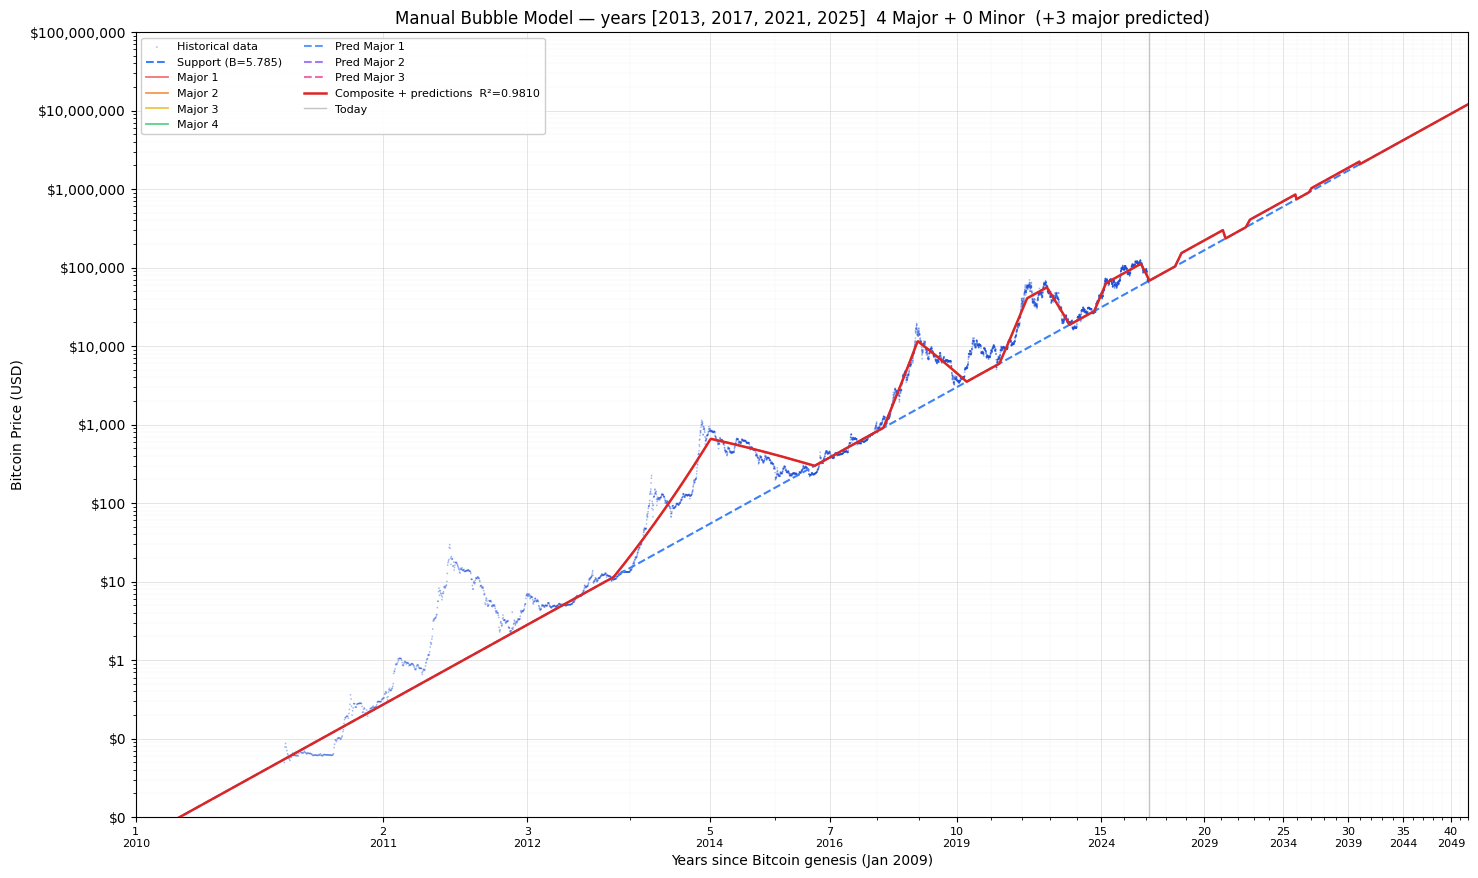

  Saved bm_loglog_zoomed.svg/.jpg


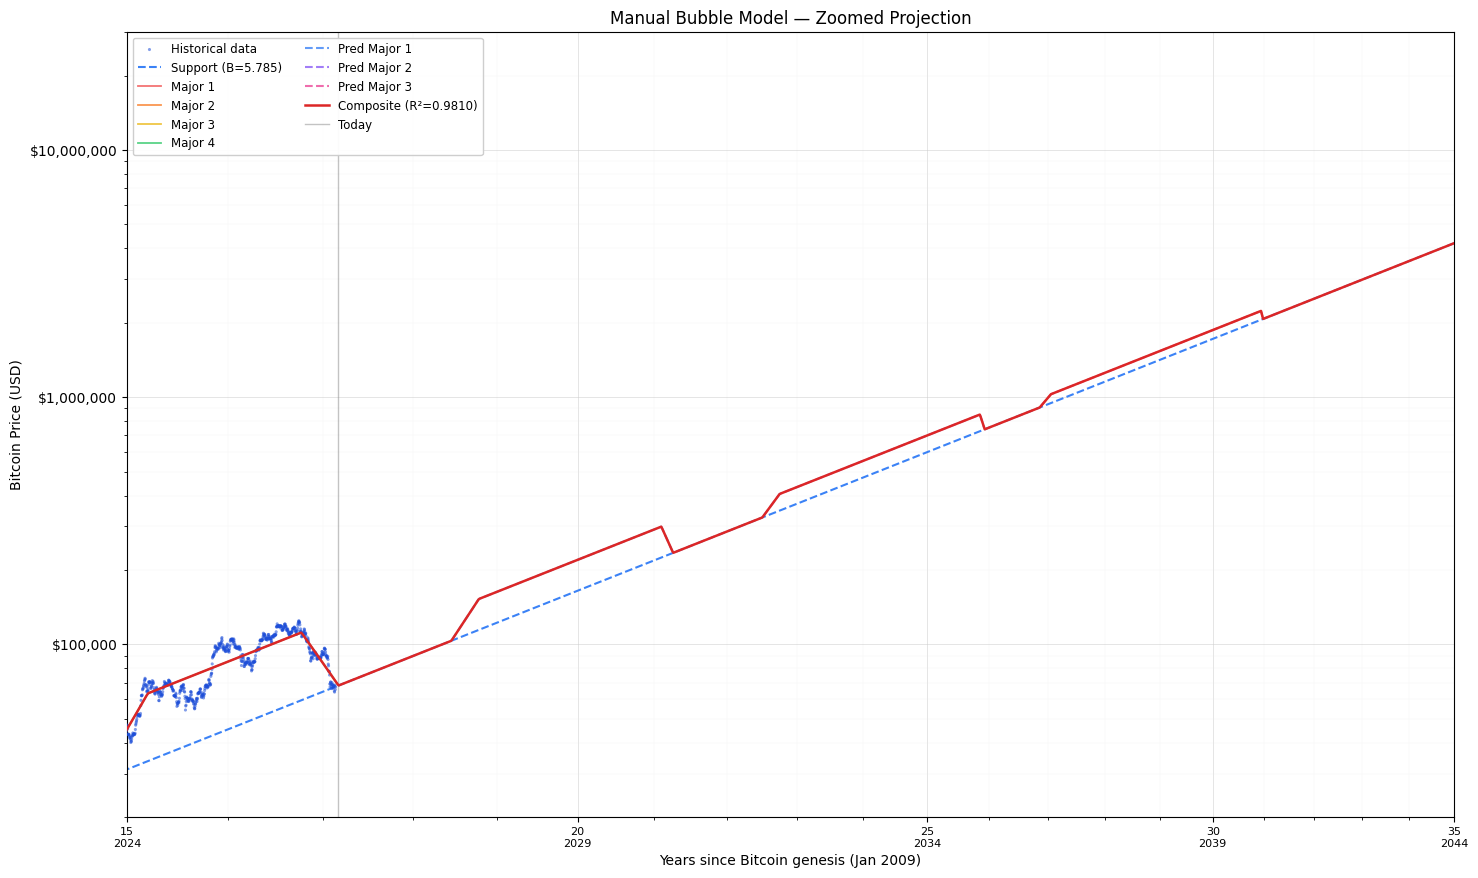

  Saved bm_semilog.svg/.jpg


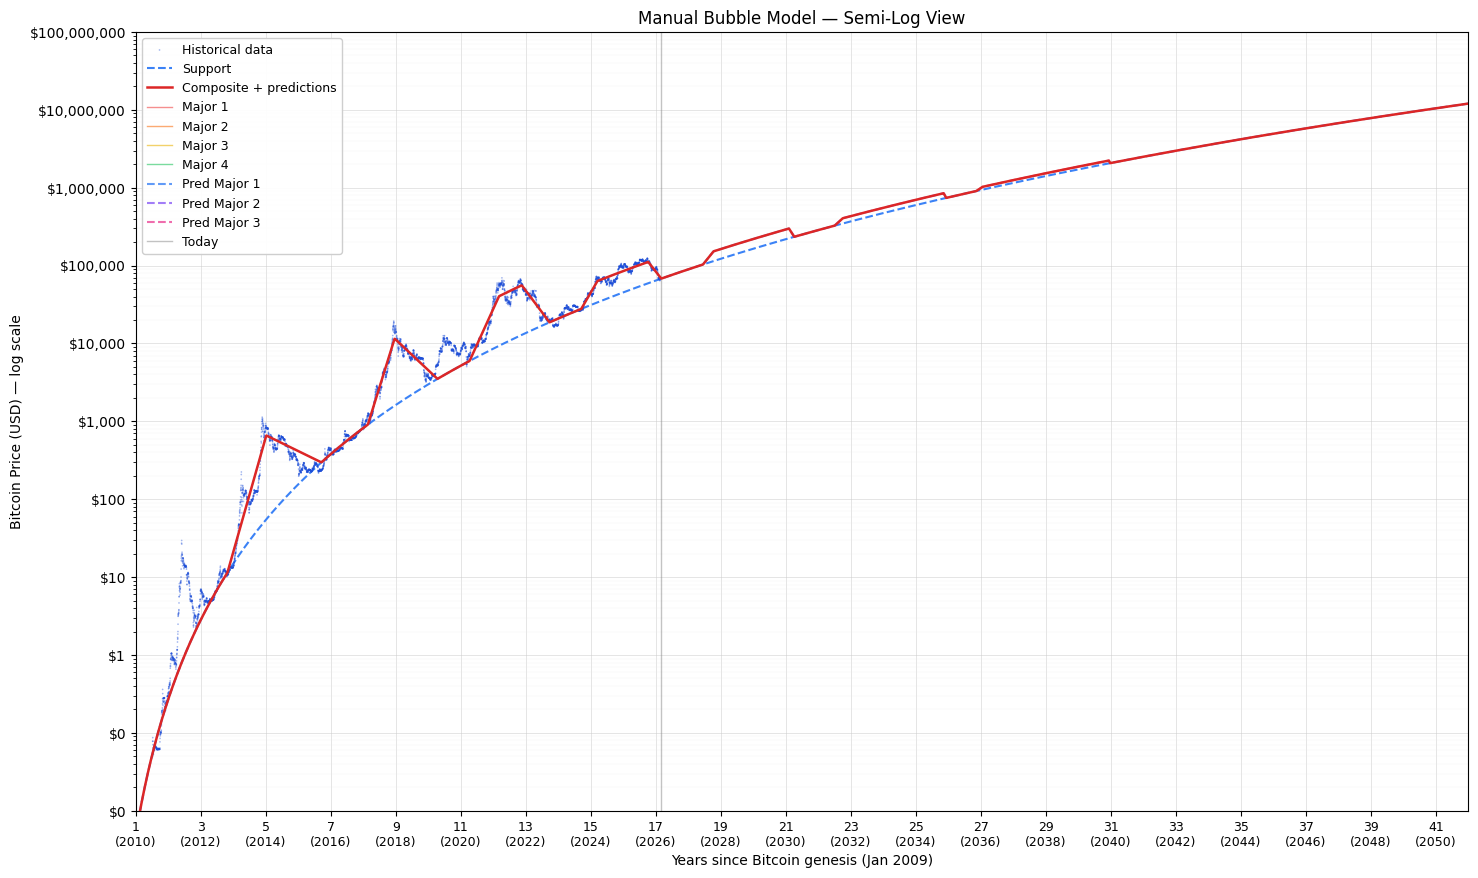

  Saved bm_decomposition.svg/.jpg


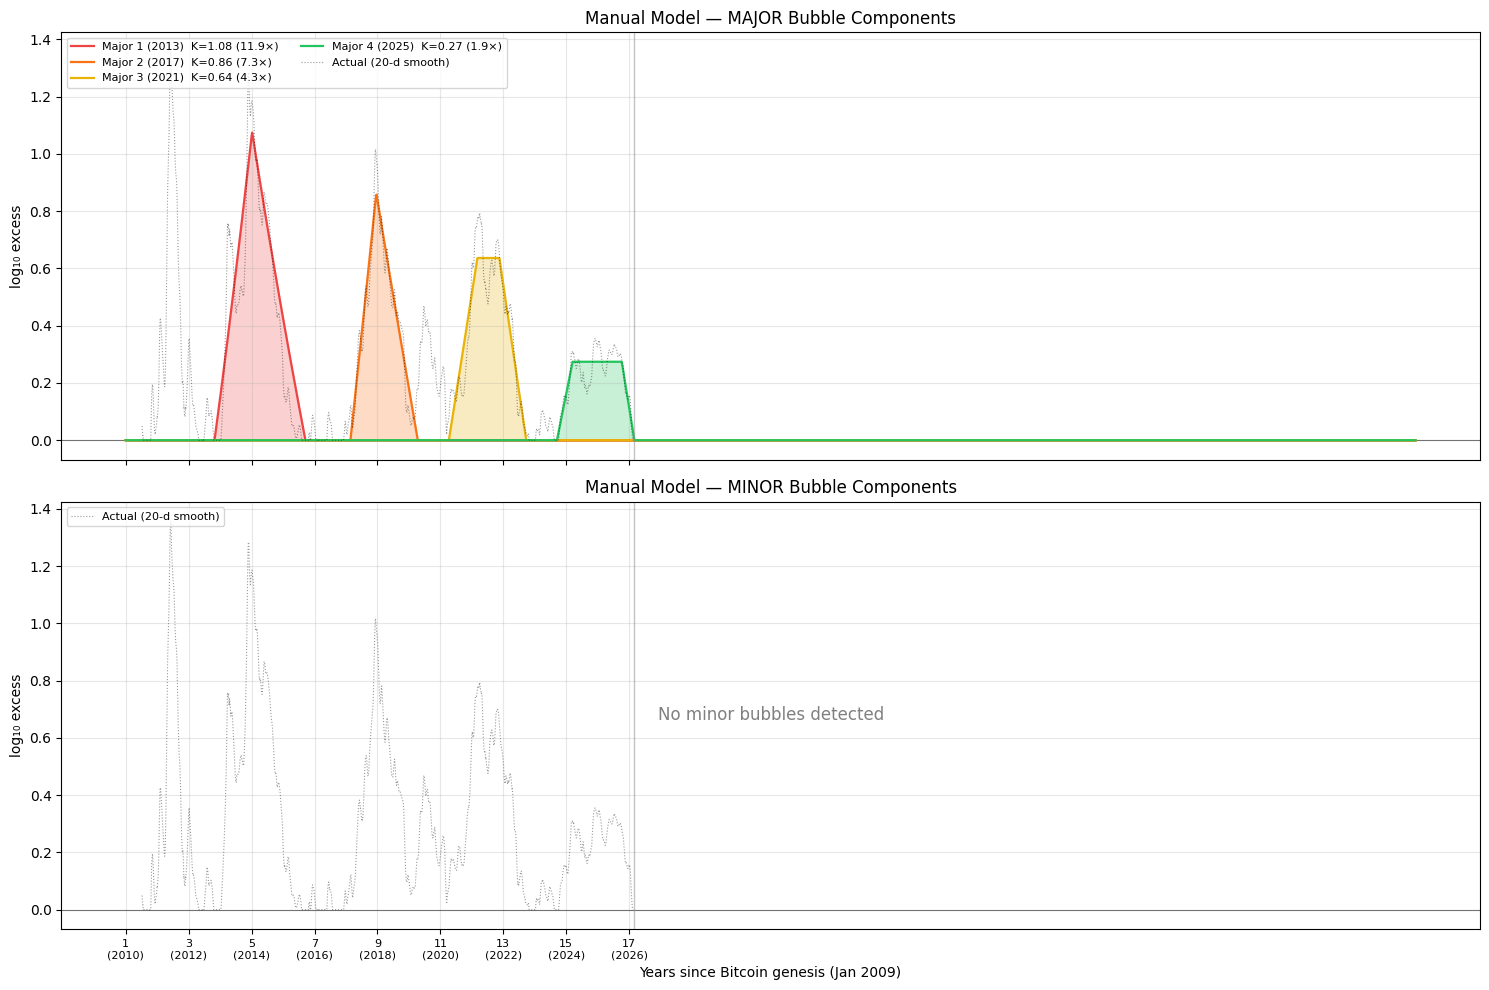

  Saved bm_residuals.svg/.jpg


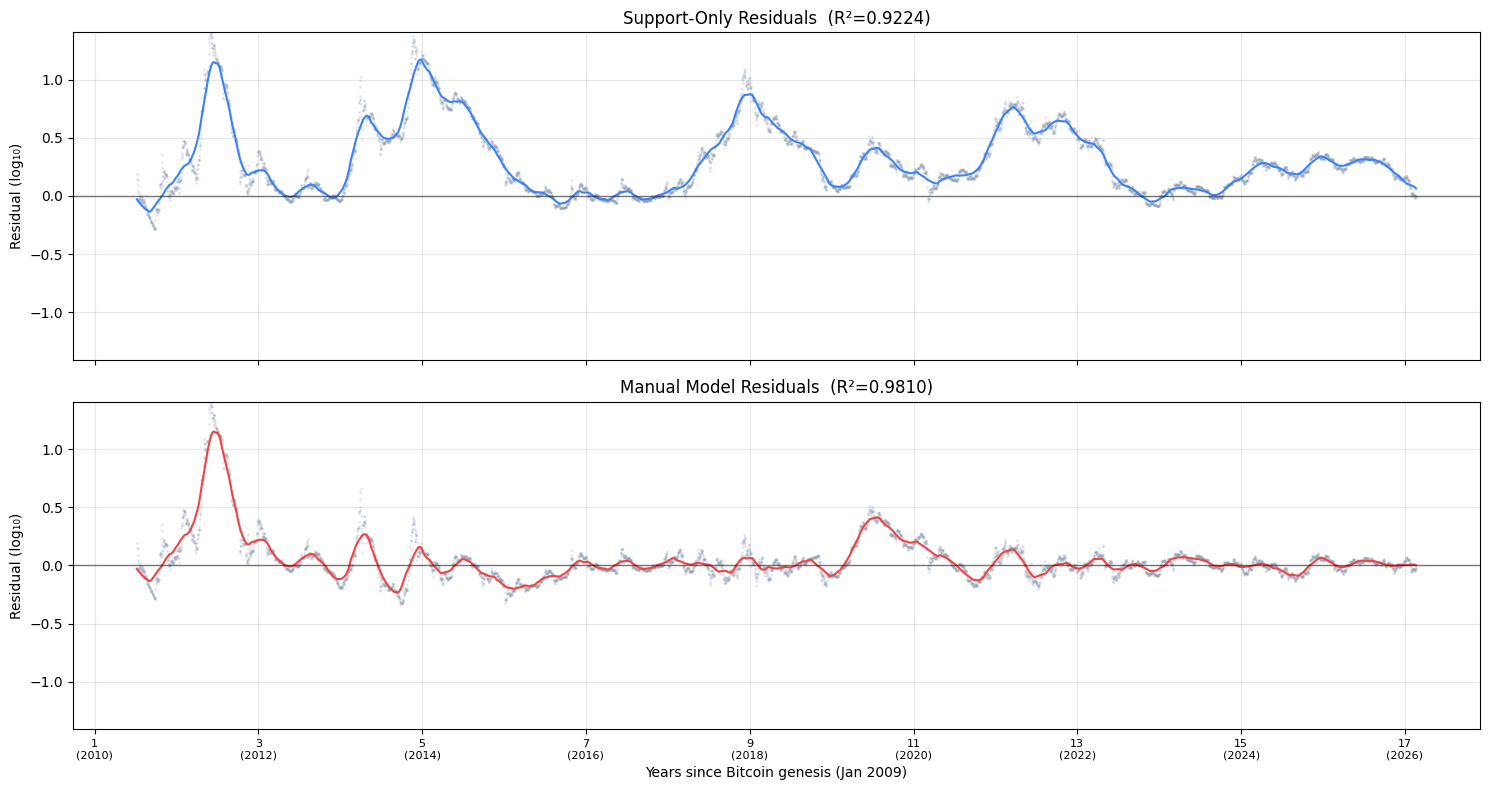

  Saved bm_envelope.svg/.jpg


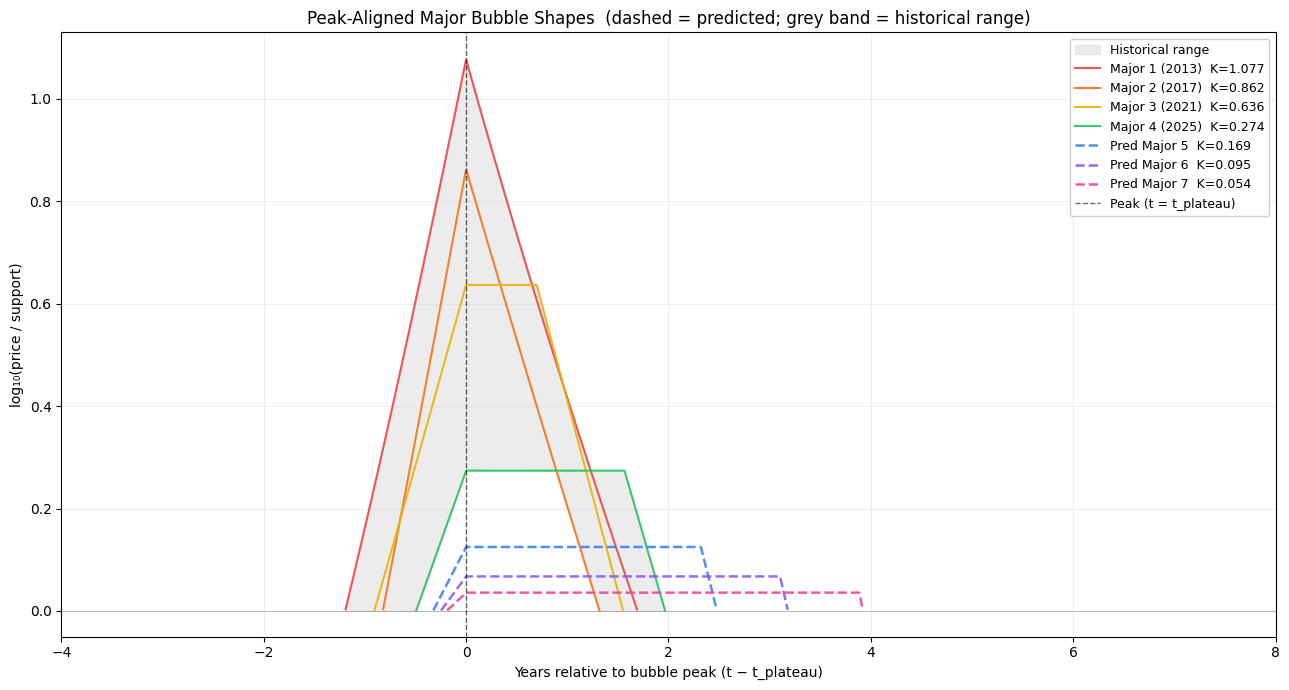


FINAL SUMMARY — Manual Bubble Model

  SUPPORT:  price = 4.9070e-03 × t^5.7847

  BUBBLE YEARS: [2013, 2017, 2021, 2025]
  Search window: ±0.75 yr around Jan 1 of each year
  Peaks found:   4 of 4 years had data in window

  BUBBLE MODEL: bubble_shape() — exponential rise/fall, power-law plateau
  Plateau      : parallel to support (plat_pow = 0)

  FITTED:    4 MAJOR + 0 MINOR = 4 total
  PREDICTED: 3 MAJOR + 1 MINOR future bubbles
    Pred Major #5:  2027-06-23  K=0.169  peak≈$168,812
    Pred Major #6:  2031-07-12  K=0.095  peak≈$432,726
    Pred Major #7:  2035-11-20  K=0.054  peak≈$1,070,667

  R² support only:          0.922413
  R² support + all bubbles: 0.980953   ΔR² = 0.058540


In [1]:
# Reset to inline backend in case interactive cell (cell 4) was run first
try:
    _ip = get_ipython()  # noqa: F821
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# ══════════════════════════════════════════════════════════════════════════════
# STANDALONE BITCOIN MANUAL-BUBBLE MODEL
# Self-contained: loads data, fits power-law support, then fits bubble_shape()
# to each bubble year the user specifies in BUBBLE_YEARS.  No rolling-slope
# phase classification is performed — you choose the peak years; the model
# determines the rise, plateau, and decay parameters automatically.
#
# Workflow:
#   1. Fit power-law support line to historical data.
#   2. For each year in BUBBLE_YEARS, locate the local log-excess peak inside a
#      ±BUBBLE_YEAR_WINDOW search window and fit bubble_shape() sequentially
#      to the residual log-excess (largest peak first).
#   3. Classify fitted bubbles as MAJOR (top N_MAJOR by peak K) / MINOR.
#   4. Compute composite model R².
#   5. Extrapolate or average future bubble parameters and plot projections.
#
# No other cells need to have run first.
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import linregress
from matplotlib.ticker import FixedLocator, StrMethodFormatter, NullFormatter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)


# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Data & input ──────────────────────────────────────────────────────────────
csv_path       = './BitcoinPricesDaily.csv'
FIT_MIN_DATE   = '2010-01-01'   # exclude early near-zero trades from the fit
FIT_MAX_DATE   = None           # None = use all available data
MIN_DATA_YEARS = 1.0
# Bitcoin had no real market price in its first year (genesis 2009-01-09 → ~2010).
# Excluding it prevents the power-law support fit from being skewed by near-zero trades.

# ── Support line ──────────────────────────────────────────────────────────────
SUPPORT_PERCENTILE = 25   # bottom X% of OLS residuals → support candidates
SUPPORT_QUANTILE   = 0.50

# ── Bubble years ──────────────────────────────────────────────────────────────
BUBBLE_YEARS = [2013, 2017, 2021, 2025]
# List the calendar years in which you believe a Bitcoin bubble peaked.
# For each year, the model searches for the highest log-excess (price/support)
# within ±BUBBLE_YEAR_WINDOW of Jan 1 of that year.
#
# Tips:
#   • Include separate entries for close double-peaks (e.g. 2013 and 2014 for
#     the April-2013 and December-2013 peaks).
#   • Years with no historical data in their window are automatically skipped
#     (no error).  Predicted bubbles are added via STEP 6 extrapolation.
#   • Order does not matter — the model sorts by peak magnitude before fitting.

BUBBLE_YEAR_WINDOW = 0.75
# Half-width of the search window, in years.
# A value of 1.0 means the model searches within ±1 year of Jan 1 of each
# bubble year, i.e. a 2-year window centred on Jan 1 of that year.
#
# Larger values help when the actual peak falls far from Jan 1 (e.g. a
# December peak in a "year" bubble).  Smaller values prevent adjacent
# bubble years from sharing data points.  Windows may overlap — the
# sequential residual fitting handles this correctly.

# ── Fitting ───────────────────────────────────────────────────────────────────
#FIT_CONTEXT_YR      = 1.0 #default=1.0
FIT_CONTEXT_YR      = 1.0
# Extra data (in years) included beyond the ±BUBBLE_YEAR_WINDOW on each side
# when optimising a bubble's parameters.  This context shows the optimiser
# where the residual returns to zero, anchoring the rise and decay tails.
# Increase if bubble fits look truncated; decrease if adjacent bubbles bleed in.

FIT_RISE_LOOKBACK_YR = 0.75
# The bubble's rise can start this many years before the left edge of the
# search window.  Needed because the actual price rise begins before the
# peak window — the bubble was already building up before the window opens.

PLATEAU_PARALLEL_SUPPORT = True
# True  → plat_pow is fixed at 0 (plateau price grows at exactly the support
#          power-law rate; log-excess is flat during the plateau).  Fewer
#          parameters, more stable fits, consistent with the phase model.
# False → plat_pow is a free parameter (6-D optimisation).  Allows the
#          plateau to tilt: < 0 = rounded top, > 0 = blow-off acceleration.

CAP_COMPOSITE_OVERLAP = True
# When True, the composite (historical + predicted bubbles) is built with
# sequential subtraction: bubbles are processed chronologically and each
# bubble's contribution at any time t is capped to the remaining budget,
# where the budget starts at the historical maximum log-excess.
# This prevents overlapping bubble tails / rises from stacking and driving
# the model price far above the data.  Set to False to restore the original
# uncapped additive sum.

PLAT_POW_RANGE = 8.0
# |plat_pow| upper bound during optimisation and prediction clipping.
# ±slope_sup ≈ ±5.8 spans "price constant" to "double support slope"; 8.0
# gives modest headroom beyond the physically meaningful range.

DE_MAXITER = 2000
# Maximum iterations for the Differential Evolution optimiser per bubble.
# With 5–6 free parameters, 2000 iterations is a good balance of speed and
# solution quality.  Increase to 4000+ if fit costs look suspiciously high.

DE_POPSIZE = 18
# Population multiplier for DE.  Population size = DE_POPSIZE × n_params.
# With 5–6 params, this gives 90–108 candidates per generation.
# DE recommends at least 10–15×; 18 is a safe conservative choice.

# ── Classification ────────────────────────────────────────────────────────────
N_MAJOR = 5
# Top N_MAJOR fitted bubbles by peak K are labelled "major"; the rest "minor".
# Bitcoin's canonical halving-driven cycles: 2011, 2013, 2017, 2021.
# Set to 5 to also include 2025 as a major bubble.

MAX_MAJOR_BUBBLES = None
# After classification, keep only the N highest-K major bubbles in the model.
# None = keep all N_MAJOR.  Example: set to 3 to drop the weakest major.

MAX_MINOR_BUBBLES = 8
# Keep only the N highest-K minor bubbles in the model.
# None = keep all.  Reduces clutter in plots and speeds up prediction.

# ── Prediction ────────────────────────────────────────────────────────────────
N_PREDICT_MAJOR      = 3     # number of future major bubbles to project
N_PREDICT_MINOR      = 1     # number of future minor bubbles to project

PREDICT_MODE         = 'extrap'
# 'avg'    — each predicted bubble gets the weighted-average parameters of the
#            last PREDICT_LAST_N_MAJOR historical bubbles.  All predictions are
#            identical in shape; only the start time shifts.  Stable / conservative.
# 'extrap' — parameters are linearly extrapolated along their historical trend
#            (r and d log-linearly; K, dur_plateau, plat_pow linearly).

PREDICT_LAST_N_MAJOR = 3
# Only the most recent N major bubbles feed the avg / extrapolation.
# None = use all detected major bubbles.
# Setting this to 3-4 focuses on recent cycles and ignores the very different
# early history (e.g. the 2011 bubble with r≈4).

PREDICT_LAST_N_MINOR = 4   # same idea for minor bubbles

MAJOR_INTERVAL_YR        = 3.8
# Fallback inter-bubble interval (years) used when fewer than 2 historical
# intervals can be measured (i.e. only 1 historical major bubble exists).

MAJOR_INTERVAL_USE_TREND = True
# False → predicted interval = weighted average of historical intervals (stable).
# True  → interval is also linearly extrapolated along its historical trend,
#         so predicted cycles can lengthen or shorten over time.

MAJOR_EXTRAP_WEIGHTS     = None
# Per-bubble, per-parameter importance weights for the avg / extrapolation.
# None = uniform (every bubble and every parameter contributes equally).
#
# If set, must be a flat list of length N_major × 6, where N_major is the
# number of historical major bubbles actually used (after PREDICT_LAST_N_MAJOR
# trimming).  The layout is row-major: one row of 6 weights per bubble,
# ordered chronologically (oldest first):
#
#   [w_r, w_d, w_K, w_interval, w_dur_plateau, w_plat_pow]   ← bubble 1 (oldest)
#   [w_r, w_d, w_K, w_interval, w_dur_plateau, w_plat_pow]   ← bubble 2
#   ...
#
# Parameter roles:
#
#   r  (rise rate, yr⁻¹)
#       Controls how steeply price climbs above support during the rise phase.
#       High r → sharp, spike-like rally.  r has historically declined each
#       cycle (early bubbles were explosive; recent ones are more gradual).
#       Extrapolated log-linearly so it can only approach zero, never go negative.
#
#   d  (decay rate, yr⁻¹)
#       Controls how quickly price falls back toward support after the peak.
#       High d → short, sharp crash.  Like r, d has trended downward over time
#       (bear markets are getting longer).  Also log-linear.
#
#   K  (peak log-excess, log₁₀ units)
#       log₁₀(peak_price / support_price_at_peak).  K=1 means the peak was
#       10× the support line; K=0.5 means ~3×.  K has declined each cycle
#       as Bitcoin matures — predicting its future value is the key uncertainty.
#       Extrapolated log-linearly (geometric mean in avg mode): each cycle's K
#       is a roughly constant fraction of the prior one, so log(K) is linear
#       in cycle index.  This also ensures predicted K is always positive.
#       A higher weight on recent bubbles will anchor K to the current regime.
#
#   interval  (time between successive t_rise values, years)
#       How many years elapse between the start of one bubble and the next.
#       Used to position the predicted bubble in time.  The weight column here
#       applies to the *intervals* array (one shorter than the bubble array),
#       so the last bubble's w_interval weight is effectively unused.
#
#   dur_plateau  (plateau duration, years)
#       How long price stays near the peak before the decay begins.  Short
#       plateaus give sharp V-shaped peaks; longer ones give extended tops.
#       Has been roughly stable across cycles, so averaging is usually fine.
#
#   plat_pow  (plateau power-law tilt, dimensionless)
#       Differential exponent during the plateau relative to the support slope.
#       plat_pow=0 → price grows at exactly the support rate (flat log-excess).
#       plat_pow<0 → price drifts down during the plateau (rounded top).
#       plat_pow>0 → price accelerates beyond support growth (blow-off top).
#       Currently fixed at 0 when PLATEAU_PARALLEL_SUPPORT=True.
#
# Example — downweight the oldest bubble and ignore plat_pow entirely:
#   MAJOR_EXTRAP_WEIGHTS = [0.5, 0.5, 0.5, 0.5, 0.5, 0,   # bubble 1 (old)
#                           1.0, 1.0, 1.0, 1.0, 1.0, 0,   # bubble 2
#                           1.5, 1.5, 1.5, 1.5, 1.5, 0]   # bubble 3 (recent)

MINOR_EXTRAP_WEIGHTS     = None  # same layout as MAJOR_EXTRAP_WEIGHTS
MINOR_INTERVAL_USE_TREND = True

# ── Bubble model colours ──────────────────────────────────────────────────────
DATA_COLOR   = '#1D4ED8'   # historical daily price scatter
MAJOR_COLORS = ['#EF4444', '#F97316', '#EAB308', '#22C55E',
                '#3B82F6', '#8B5CF6', '#EC4899', '#14B8A6']
MINOR_COLORS = ['#FCA5A5', '#FDBA74', '#FDE68A', '#86EFAC',
                '#93C5FD', '#C4B5FD', '#F9A8D4', '#99F6E4']

# ── Shared chart colours ──────────────────────────────────────────────────────
SUPPORT_COLOR        = '#3B82F6'   # support power-law line
COMPOSITE_COLOR      = '#DC2626'   # composite model curve
TODAY_COLOR          = '#888888'   # "today" vertical marker
FIT_MIN_COLOR        = '#10B981'   # FIT_MIN_DATE vertical marker
FIT_MAX_COLOR        = '#EF4444'   # FIT_MAX_DATE vertical marker
SCATTER_COLOR        = '#94A3B8'   # raw data scatter in residual / excess plots
EXCESS_SMOOTH_COLOR  = '#2563EB'   # smoothed excess line in decomposition plot
RESID_SUP_COLOR      = '#3B82F6'   # smoothed support-only residual line
RESID_COMP_COLOR     = '#EF4444'   # smoothed composite residual line
REFERENCE_LINE_COLOR = 'black'     # zero-reference horizontal lines
GRID_MAJOR_COLOR     = '#CCCCCC'   # major grid lines
GRID_MINOR_COLOR     = '#E5E5E5'   # minor grid lines
PLOT_BG_COLOR        = 'white'     # axes background colour
FALLBACK_TEXT_COLOR  = 'gray'      # "no data" placeholder text

# ── Plot sizing ───────────────────────────────────────────────────────────────
FIGSIZE_WIDE      = (15, 9)    # log-log, semi-log, and most chart panels
FIGSIZE_DECOMP    = (15, 10)   # bubble decomposition (2 stacked panels)
FIGSIZE_RESIDUALS = (15, 8)    # residual comparison (2 panels)
FIGSIZE_ENVELOPE  = (13, 7)    # peak-aligned envelope chart

# ── Plot axes ─────────────────────────────────────────────────────────────────
PLOT_YEARS_MIN         = 1.0    # first year on the dense plot grid and full x-axis
PLOT_YEARS_MAX         = 72.0   # last year on the dense plot grid and full x-axis
PLOT_GRID_POINTS       = 3000   # number of points in the dense time-grid
PRICE_YMIN             = 0.01   # lower price y-axis limit (USD)
PRICE_YMAX             = 1e8    # upper price y-axis limit (USD)
ZOOM_XMIN              = 15     # zoomed chart left bound (years since genesis)
ZOOM_XMAX              = 35     # zoomed chart right bound (years since genesis)
ZOOM_YMIN              = 2e4    # zoomed chart lower price limit (USD)
ZOOM_YMAX              = 3e7    # zoomed chart upper price limit (USD)
RESIDUAL_SMOOTH_WINDOW = 90     # rolling-mean window (days) for residual plots


# ══════════════════════════════════════════════════════════════════════════════
# LOAD + PREPARE DATA
# ══════════════════════════════════════════════════════════════════════════════
try:
    df = pd.read_csv(csv_path)
    print(f"CSV loaded.  Shape: {df.shape}")
except FileNotFoundError:
    print(f"File not found: {csv_path}")

df.columns = ['Date', 'Price']
df['Date']  = pd.to_datetime(df['Date'], format='%m/%d/%y', errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date')

x_dates = df['Date']
y_data  = df['Price'].astype(float)

genesis     = pd.to_datetime('2009-07-25')
years_since = (x_dates - genesis).dt.days / 365.25

valid       = y_data > 0
years_valid = years_since[valid].astype(float)
y_valid     = y_data[valid]

reasonable = years_valid >= MIN_DATA_YEARS
years_all  = years_valid[reasonable].values
y_all      = y_valid[reasonable].values
dates_all  = x_dates[valid][reasonable].values

log_t_all = np.log10(years_all)
log_p_all = np.log10(y_all)

fit_mask = np.ones(len(dates_all), dtype=bool)
if FIT_MIN_DATE:
    fit_mask &= pd.to_datetime(dates_all) >= pd.to_datetime(FIT_MIN_DATE)
if FIT_MAX_DATE:
    fit_mask &= pd.to_datetime(dates_all) <= pd.to_datetime(FIT_MAX_DATE)

log_t     = log_t_all[fit_mask]
log_p     = log_p_all[fit_mask]
years_fit = years_all[fit_mask]
dates_fit = dates_all[fit_mask]

today_years   = (pd.to_datetime('today') - genesis).days / 365.25
fit_min_years = (pd.to_datetime(FIT_MIN_DATE) - genesis).days / 365.25 if FIT_MIN_DATE else None
fit_max_years = (pd.to_datetime(FIT_MAX_DATE) - genesis).days / 365.25 if FIT_MAX_DATE else None

print(f"Date range  : {pd.Timestamp(dates_all[0]).date()} → {pd.Timestamp(dates_all[-1]).date()}")
print(f"Fit window  : {fit_mask.sum()} points")
print(f"Price range : ${y_all.min():,.2f} – ${y_all.max():,.2f}")
print(f"Today       : t = {today_years:.3f} yr")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1: FIT SUPPORT LINE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(f"STEP 1: FITTING SUPPORT LINE (bottom {SUPPORT_PERCENTILE}% OLS residual)")
print("=" * 80)

slope_ols, intercept_ols, _, _, _ = linregress(log_t, log_p)
ols_resid    = log_p - (intercept_ols + slope_ols * log_t)
cutoff       = np.percentile(ols_resid, SUPPORT_PERCENTILE)
support_mask = ols_resid <= cutoff

X_support = sm.add_constant(log_t[support_mask])
res_sup   = sm.QuantReg(log_p[support_mask], X_support).fit(q=SUPPORT_QUANTILE, max_iter=10000)

intercept_sup = res_sup.params[0]
slope_sup     = res_sup.params[1]
A_sup         = 10 ** intercept_sup
B_sup         = slope_sup

print(f"  Support points : {support_mask.sum()} / {len(log_t)}")
print(f"  Power law      : price = {A_sup:.4e} × t^{B_sup:.4f}")

log_support_all = intercept_sup + slope_sup * log_t_all
log_support_fit = intercept_sup + slope_sup * log_t

log_excess_all = log_p_all - log_support_all
log_excess_fit = log_p     - log_support_fit


# ══════════════════════════════════════════════════════════════════════════════
# BUBBLE SHAPE FUNCTION  (used by STEP 3 below)
# ══════════════════════════════════════════════════════════════════════════════
def bubble_shape(t, t_rise, r, t_plateau, t_decay, d, plat_pow=0.0):
    """
    Log₁₀ bubble excess above the power-law support line.

    Parameters
    ----------
    t         : array of time values (years since genesis)
    t_rise    : start of the exponential rise
    r         : rise rate (yr⁻¹); price doubles relative to support every log(2)/r years
    t_plateau : end of rise / start of plateau
    t_decay   : end of plateau / start of decay
    d         : decay rate (yr⁻¹)
    plat_pow  : differential power-law exponent during plateau, relative to support.
                price ∝ t^(slope_sup + plat_pow) during [t_plateau, t_decay].
                  plat_pow = 0          → plateau parallels support (log_excess = K)
                  plat_pow = −slope_sup → price is constant during plateau
                  plat_pow > 0          → blow-off top (price grows faster than support)

    Phases
    ------
    Rise    [t_rise, t_plateau):
        log_excess(t) = r·(t − t_rise) + slope_sup·log₁₀(t_rise / t)
        Equivalently: price grows exponentially from support(t_rise).

    Plateau [t_plateau, t_decay):
        log_excess(t) = K + plat_pow·log₁₀(t / t_plateau)
        where K = log_excess(t_plateau) = peak of rise phase.
        plat_pow = 0 recovers the original "plateau parallels support" behaviour.

    Decay   [t_decay, ∞):
        log_excess(t) = K_end − d·(t − t_decay) + slope_sup·log₁₀(t_decay / t), clipped ≥ 0
        where K_end = K + plat_pow·log₁₀(t_decay / t_plateau) = log_excess at t_decay.
        Price decays exponentially back toward support(t_decay).
    """
    t = np.asarray(t, dtype=float)
    result = np.zeros_like(t)
    if t_plateau <= t_rise:
        return result
    # K: log-excess at the start of the plateau (= peak of rise)
    K = r * (t_plateau - t_rise) + slope_sup * np.log10(
        np.maximum(t_rise / t_plateau, 1e-12))
    if K <= 0:
        return result
    # K_end: log-excess at the end of the plateau (= start of decay)
    K_end = (K + plat_pow * np.log10(np.maximum(t_decay / t_plateau, 1e-12))
             if t_decay > t_plateau else K)

    # Rise
    m = (t >= t_rise) & (t < t_plateau)
    if m.any():
        result[m] = np.maximum(
            r * (t[m] - t_rise) + slope_sup * np.log10(
                np.maximum(t_rise / t[m], 1e-12)), 0.0)
    # Plateau (general power law)
    m = (t >= t_plateau) & (t < t_decay)
    if m.any():
        result[m] = np.maximum(
            K + plat_pow * np.log10(np.maximum(t[m] / t_plateau, 1e-12)), 0.0)
    # Decay
    m = t >= t_decay
    if m.any():
        result[m] = np.maximum(
            K_end - d * (t[m] - t_decay) + slope_sup * np.log10(
                np.maximum(t_decay / t[m], 1e-12)), 0.0)
    return result


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2: LOCATE BUBBLE PEAKS FROM BUBBLE_YEARS
# ══════════════════════════════════════════════════════════════════════════════
# For each year in BUBBLE_YEARS, find the highest log-excess (price/support)
# within a ±BUBBLE_YEAR_WINDOW window centred on Jan 1 of that year.
#
# The search window is just for locating the peak — the fitting window in
# STEP 3 is wider (extends by ±FIT_CONTEXT_YR beyond the search window) so
# the optimiser sees the residual approaching zero on both sides.
#
# Years where the search window falls entirely outside the available data are
# silently skipped.  They will not produce a fitted bubble — use the STEP 6
# prediction to project those future peaks.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(f"STEP 2: LOCATE BUBBLE PEAKS  (BUBBLE_YEAR_WINDOW = ±{BUBBLE_YEAR_WINDOW} yr)")
print("=" * 80)
print(f"\n  Searching for peaks near: {BUBBLE_YEARS}")
print(f"\n  {'Year':>4}  {'t_center':>8}  {'Search window':>22}  {'Peak date':>12}  "
      f"{'t_peak':>7}  {'Raw K':>6}")
print("  " + "-" * 72)

bm_peaks = []   # list of dicts describing each located peak

for yr in BUBBLE_YEARS:
    # Jan 1 of the specified year, converted to years since genesis
    t_center = (pd.to_datetime(f'{yr}-01-01') - genesis).days / 365.25
    t_lo     = t_center - BUBBLE_YEAR_WINDOW
    t_hi     = t_center + BUBBLE_YEAR_WINDOW

    # Only search within available data
    window_mask = (years_fit >= t_lo) & (years_fit <= t_hi)
    if not window_mask.any():
        print(f"  {yr:>4}  {t_center:>8.3f}  [{t_lo:>8.3f}, {t_hi:>8.3f}]  "
              f"{'(no data — skipped)':>42}")
        continue

    local_exc = log_excess_fit[window_mask]
    local_yrs = years_fit[window_mask]
    local_dt  = dates_fit[window_mask]
    peak_i    = int(np.argmax(local_exc))
    peak_t    = local_yrs[peak_i]
    peak_K    = local_exc[peak_i]
    peak_date = pd.Timestamp(local_dt[peak_i]).strftime('%Y-%m-%d')

    bm_peaks.append({
        'bubble_year': yr,
        'peak_t':      peak_t,     # years since genesis at the log-excess peak
        'region_lo':   t_lo,       # left edge of search window
        'region_hi':   t_hi,       # right edge of search window
        'raw_K':       peak_K,
    })
    print(f"  {yr:>4}  {t_center:>8.3f}  [{t_lo:>8.3f}, {t_hi:>8.3f}]  "
          f"{peak_date:>12}  {peak_t:>7.3f}  {peak_K:>6.3f}")

if not bm_peaks:
    print("\n  No peaks found in any window.  Check BUBBLE_YEARS and BUBBLE_YEAR_WINDOW.")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: FIT BUBBLE_SHAPE() TO EACH LOCATED PEAK
# ══════════════════════════════════════════════════════════════════════════════
# Fitting strategy: sequential residual fitting, largest raw peak first.
#
# Each bubble is fitted to the CURRENT residual (raw log-excess minus the
# shapes already fitted).  After fitting, this bubble's shape is subtracted
# from the residual before the next bubble is fitted.  This prevents
# double-counting: without it, all bubbles independently fit the full signal
# and their sum far exceeds the data.
#
# The optimisation window extends FIT_CONTEXT_YR beyond the search window so
# the optimiser sees the residual returning to zero on both sides.  The rise
# start (t_rise) can begin up to FIT_RISE_LOOKBACK_YR before the left edge
# of the search window, because the actual rally precedes the peak window.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 3: FITTING BUBBLE SHAPES")
print("=" * 80)
print(f"  plat_pow: {'fixed = 0 (plateau parallels support)' if PLATEAU_PARALLEL_SUPPORT else 'free parameter'}")
print(f"  FIT_CONTEXT_YR = {FIT_CONTEXT_YR}  FIT_RISE_LOOKBACK_YR = {FIT_RISE_LOOKBACK_YR}")
print(f"  DE_MAXITER = {DE_MAXITER}  DE_POPSIZE = {DE_POPSIZE}")


def fit_manual_bubble(pk, idx, residual):
    """
    Fit bubble_shape() to one manually-located peak.

    Parameters
    ----------
    pk       : peak dict from bm_peaks (keys: peak_t, region_lo, region_hi, raw_K)
    idx      : integer index for RNG seeding (ensures reproducibility)
    residual : current residual log-excess (raw log-excess minus previously
               fitted bubble contributions)

    Returns
    -------
    dict of bubble parameters, dates, and diagnostics
    """
    region_lo = pk['region_lo']
    region_hi = pk['region_hi']
    peak_t    = pk['peak_t']

    # ── Fitting data window ──────────────────────────────────────────────────
    # Extend beyond the search window so the optimiser sees the return to zero.
    t_lo = max(years_fit[0],  region_lo - FIT_CONTEXT_YR)
    t_hi = min(years_fit[-1], region_hi + FIT_CONTEXT_YR)
    ctx  = (years_fit >= t_lo) & (years_fit <= t_hi)
    t_ctx = years_fit[ctx]
    exc   = np.maximum(0.0, residual[ctx])   # fit to non-negative residual

    span = (region_hi - region_lo) + 2 * FIT_CONTEXT_YR   # total fitting span

    # ── Optimisation bounds ──────────────────────────────────────────────────
    # t_rise: start from FIT_RISE_LOOKBACK_YR before window, up to the peak
    t_rise_lb = max(years_fit[0], region_lo - FIT_RISE_LOOKBACK_YR)

    bounds_5 = [
        (t_rise_lb, peak_t),    # t_rise  — rise begins before or at the peak
        (0.05, 20.0),            # r       — rise rate (yr⁻¹)
        (0.02, span),            # dur_rise — rise duration
        (0.0,  span),            # dur_plateau — 0 = no plateau (V-shaped peak)
        (0.05, 20.0),            # d       — decay rate (yr⁻¹)
    ]

    if PLATEAU_PARALLEL_SUPPORT:
        # 5-D optimisation: plat_pow is fixed at 0
        def obj5(p5):
            tr, r_, dr, dp, d_ = p5
            pred = bubble_shape(t_ctx, tr, r_, tr + dr, tr + dr + dp, d_, 0.0)
            return float(np.sum((exc - pred) ** 2))

        res    = differential_evolution(obj5, bounds_5, maxiter=DE_MAXITER,
                                        popsize=DE_POPSIZE, seed=42 + idx,
                                        tol=1e-10, polish=True)
        params = list(res.x) + [0.0]   # append plat_pow = 0
        cost   = res.fun

    else:
        # 6-D optimisation: plat_pow is a free parameter
        bounds_6 = bounds_5 + [(-PLAT_POW_RANGE, PLAT_POW_RANGE)]

        def obj6(p6):
            tr, r_, dr, dp, d_, pp = p6
            pred = bubble_shape(t_ctx, tr, r_, tr + dr, tr + dr + dp, d_, pp)
            return float(np.sum((exc - pred) ** 2))

        res    = differential_evolution(obj6, bounds_6, maxiter=DE_MAXITER,
                                        popsize=DE_POPSIZE, seed=42 + idx,
                                        tol=1e-10, polish=True)
        params = list(res.x)
        cost   = res.fun

    # ── Unpack and derive K values ───────────────────────────────────────────
    tr, r_, dr, dp, d_, pp = params
    tplat  = tr + dr
    tdec   = tplat + dp
    # K_peak: log-excess at the end of the rise (= start of plateau)
    K_peak = max(r_ * dr + slope_sup * np.log10(max(tr / tplat, 1e-12)), 0.0)
    # K_end: log-excess at the end of the plateau (= start of decay)
    K_end  = K_peak + pp * np.log10(max(tdec / tplat, 1e-12)) if dp > 0 else K_peak
    # K_bubble: the maximum log-excess (peak of the whole bubble)
    K_bub  = max(K_peak, K_end)
    # t_end: approximate time when the decay returns to support (log_excess → 0)
    t_end  = tdec + (max(K_end, 0.0) / d_ if d_ > 0 else 0.0)

    return {
        't_rise':      tr,      'r':           r_,    'dur_rise':    dr,
        't_plateau':   tplat,   'dur_plateau':  dp,   't_decay':     tdec,
        'd':           d_,      'plat_pow':     pp,
        'K':           K_bub,   'K_peak':       K_peak, 'K_end':     K_end,
        't_end':       t_end,   'cost':         cost,
        't_start':     tr,      # alias used by plot helpers
        'bubble_year': pk['bubble_year'],
        'date_rise':   genesis + pd.Timedelta(days=tr    * 365.25),
        'date_plat':   genesis + pd.Timedelta(days=tplat * 365.25),
        'date_decay':  genesis + pd.Timedelta(days=tdec  * 365.25),
        'date_end':    genesis + pd.Timedelta(days=t_end  * 365.25),
    }


# ── Sequential residual fitting: largest raw peak first ──────────────────────
# Sorting by raw_K descending ensures dominant events are captured cleanly
# before smaller ones.  This mirrors how the phase model fits bubbles.
peaks_by_magnitude = sorted(
    enumerate(bm_peaks),
    key=lambda x: x[1]['raw_K'],
    reverse=True
)

residual_bm  = log_excess_fit.copy()   # mutable residual; starts as raw log-excess
bm_fitted    = []                      # fitted bubble parameter dicts

for rank, (orig_idx, pk) in enumerate(peaks_by_magnitude):
    print(f"  Fitting bubble year {pk['bubble_year']} "
          f"({rank + 1}/{len(bm_peaks)}, raw K={pk['raw_K']:.3f}) ...",
          end=' ', flush=True)
    bp = fit_manual_bubble(pk, orig_idx, residual_bm)
    bm_fitted.append(bp)
    # Subtract this bubble's contribution from the residual
    contrib     = bubble_shape(years_fit, bp['t_rise'], bp['r'],
                               bp['t_plateau'], bp['t_decay'], bp['d'],
                               bp.get('plat_pow', 0.0))
    residual_bm = np.maximum(0.0, residual_bm - contrib)
    pp_str = (f"plat_pow={bp['plat_pow']:+.2f}"
              if not PLATEAU_PARALLEL_SUPPORT else "plat_pow=0")
    print(f"K={bp['K']:.3f} ({10**bp['K']:.1f}×)  {pp_str}  "
          f"cost={bp['cost']:.4f}  resid_max={residual_bm.max():.3f}")

# Sort chronologically by rise time for display and classification
bm_fitted.sort(key=lambda b: b['t_rise'])


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4: CLASSIFY FITTED BUBBLES → MAJOR / MINOR
# ══════════════════════════════════════════════════════════════════════════════
# The top N_MAJOR bubbles by peak K are labelled "major"; the rest are "minor".
# Optional caps (MAX_MAJOR_BUBBLES, MAX_MINOR_BUBBLES) further trim each class
# to the strongest K values so plots stay readable.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 4: MAJOR / MINOR CLASSIFICATION")
print("=" * 80)

n_det   = len(bm_fitted)
n_maj   = min(N_MAJOR, n_det)
by_K    = sorted(range(n_det), key=lambda i: bm_fitted[i]['K'], reverse=True)
maj_set = set(by_K[:n_maj])

bm_major = sorted([bm_fitted[i] for i in maj_set],
                   key=lambda b: b['t_rise'])
bm_minor = sorted([bm_fitted[i] for i in range(n_det) if i not in maj_set],
                   key=lambda b: b['t_rise'])

# Apply optional caps (keep highest-K within each class, re-sort chronologically)
if MAX_MAJOR_BUBBLES is not None and len(bm_major) > MAX_MAJOR_BUBBLES:
    bm_major = sorted(sorted(bm_major, key=lambda b: -b['K'])[:MAX_MAJOR_BUBBLES],
                      key=lambda b: b['t_rise'])
if MAX_MINOR_BUBBLES is not None and len(bm_minor) > MAX_MINOR_BUBBLES:
    bm_minor = sorted(sorted(bm_minor, key=lambda b: -b['K'])[:MAX_MINOR_BUBBLES],
                      key=lambda b: b['t_rise'])

print(f"  {n_det} total  →  {len(bm_major)} MAJOR + {len(bm_minor)} MINOR")
print(f"  (top {N_MAJOR} by peak K = major"
      + (f"; capped at {MAX_MAJOR_BUBBLES}" if MAX_MAJOR_BUBBLES else "")
      + f";  {len(bm_minor)} minor shown"
      + (f" of {n_det - len(maj_set)}"
         if MAX_MINOR_BUBBLES and n_det - len(maj_set) > len(bm_minor) else "")
      + ")")


def print_bm_table(params, label):
    """
    Print a formatted table of fitted bubble parameters.

    Columns: bubble year, rise date, rise rate r (yr⁻¹), rise duration (yr),
    peak K (log₁₀ multiplier above support), price peak as a multiple of support,
    plateau duration (yr), decay rate d (yr⁻¹), optionally plat_pow, and the
    inter-bubble interval Δt_rise (yr) from the previous bubble.
    """
    if not params:
        print(f"\n  {label}: none"); return
    print(f"\n  {label} BUBBLES:")
    hdr = (f"  {'Yr':>4}  {'date_rise':>12}  {'r':>6}  {'dur_rise':>8}  "
           f"{'K':>6}  {'Peak×':>6}  {'dur_plat':>8}  {'d':>6}")
    if not PLATEAU_PARALLEL_SUPPORT:
        hdr += f"  {'plat_pow':>8}"
    hdr += f"  {'Δt_rise':>8}"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for i, bp in enumerate(params):
        dt  = f"{bp['t_rise'] - params[i-1]['t_rise']:.2f} yr" if i > 0 else ""
        row = (f"  {bp.get('bubble_year','?'):>4}  "
               f"{bp['date_rise'].strftime('%Y-%m-%d'):>12}  "
               f"{bp['r']:>6.3f}  {bp['dur_rise']:>8.3f}  {bp['K']:>6.3f}  "
               f"{10**bp['K']:>6.1f}×  {bp['dur_plateau']:>8.3f}  {bp['d']:>6.3f}")
        if not PLATEAU_PARALLEL_SUPPORT:
            row += f"  {bp['plat_pow']:>+8.3f}"
        row += f"  {dt:>8}"
        print(row)


print_bm_table(bm_major, "MAJOR")
print_bm_table(bm_minor, "MINOR")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5: COMPOSITE MODEL + R²
# ══════════════════════════════════════════════════════════════════════════════
#
# The model price at any time t is:
#   log10(price) = log10(support(t))  +  Σ bubble_shape_i(t)
# which in linear price is:
#   price = support(t) × 10^[Σ bubble_shape_i(t)]
#
# R² is computed on the full daily time series in log10-price space.
# We compare two models: support-only (baseline) and support + all bubbles.
# ══════════════════════════════════════════════════════════════════════════════

# Dense plotting grid (years since genesis)
years_plot_bm       = np.linspace(PLOT_YEARS_MIN, PLOT_YEARS_MAX, PLOT_GRID_POINTS)
log_t_plot_bm       = np.log10(years_plot_bm)
log_support_plot_bm = intercept_sup + slope_sup * log_t_plot_bm   # log10(support)
support_plot_bm     = 10 ** log_support_plot_bm                    # support in USD


def bm_total_bubble(years, params_list, budget=None):
    """
    Sum bubble_shape contributions (log-excess) from all bubbles in params_list.

    If budget is provided (array, same length as years), applies sequential
    subtraction: bubbles are sorted chronologically by t_rise and each bubble's
    contribution at any time t is capped to the remaining budget at t.  This
    mirrors the sequential residual fitting and prevents overlapping tails from
    stacking beyond what the data supports.

    Without a budget, falls back to a plain additive sum (original behaviour).
    Returns an array of shape (len(years),).
    """
    if not params_list:
        return np.zeros(len(years))
    if budget is None:
        total = np.zeros(len(years))
        for bp in params_list:
            total += bubble_shape(years, bp['t_rise'], bp['r'],
                                  bp['t_plateau'], bp['t_decay'], bp['d'],
                                  bp.get('plat_pow', 0.0))
        return total
    # Sequential capped sum
    ordered  = sorted(params_list, key=lambda b: b['t_rise'])
    total    = np.zeros(len(years))
    remaining = np.maximum(0.0, budget.copy())
    for bp in ordered:
        contrib   = bubble_shape(years, bp['t_rise'], bp['r'],
                                 bp['t_plateau'], bp['t_decay'], bp['d'],
                                 bp.get('plat_pow', 0.0))
        contrib   = np.minimum(contrib, remaining)
        total    += contrib
        remaining = np.maximum(0.0, remaining - contrib)
    return total


# ── Budget for sequential-cap composite ──────────────────────────────────────
# Maximum log-excess ever observed in the historical data.  No single time
# point in the composite is allowed to exceed this.
_hist_K_max   = float(np.max(np.maximum(0.0, log_excess_fit)))
_budget_plot  = np.full(len(years_plot_bm), _hist_K_max) if CAP_COMPOSITE_OVERLAP else None
_budget_all   = np.full(len(years_all),     _hist_K_max) if CAP_COMPOSITE_OVERLAP else None

# ── Plotting-grid composites ─────────────────────────────────────────────────
# Process all fitted bubbles together so the budget is shared across maj/min.
_all_fitted   = sorted(bm_major + bm_minor, key=lambda b: b['t_rise'])
bm_total_plot = bm_total_bubble(years_plot_bm, _all_fitted, _budget_plot)
bm_maj_plot   = bm_total_bubble(years_plot_bm, bm_major)   # uncapped, for decomp plots
bm_min_plot   = bm_total_bubble(years_plot_bm, bm_minor)   # uncapped, for decomp plots
bm_composite  = 10 ** (log_support_plot_bm + bm_total_plot)   # USD price curve

# ── R² on the full daily time series ─────────────────────────────────────────
total_all_bm     = bm_total_bubble(years_all, _all_fitted, _budget_all)
composite_all_bm = log_support_all + total_all_bm
ss_tot           = np.sum((log_p_all - np.mean(log_p_all)) ** 2)
bm_r2_support    = 1 - np.sum((log_p_all - log_support_all)  ** 2) / ss_tot
bm_r2_comp       = 1 - np.sum((log_p_all - composite_all_bm) ** 2) / ss_tot

print(f"\n{'='*80}\nMODEL FIT QUALITY\n{'='*80}")
print(f"  R² support only:          {bm_r2_support:.6f}")
print(f"  R² support + all bubbles: {bm_r2_comp:.6f}   ΔR² = {bm_r2_comp - bm_r2_support:.6f}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6: PREDICT FUTURE BUBBLES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*80}")
print("STEP 6: PREDICTING FUTURE BUBBLES")
print(f"{'='*80}")


def predict_future_bubbles(hist_params, n_future, extrap_weights,
                            use_interval_trend, label='', default_interval=3.8,
                            min_interval=0.15, mode='extrap', last_n=None):
    """Project future bubble parameters from historical bubbles.

    mode='avg'
        Every predicted bubble gets the weighted average of the last `last_n`
        historical bubbles.  All predictions are identical in shape; only the
        start time advances by the average interval.  Conservative / stable.

    mode='extrap'
        Parameters are linearly extrapolated along their historical trend
        (r and d log-linearly; K, dur_plateau, plat_pow linearly), so each
        successive prediction follows the fitted slope.

    last_n
        If set, only the most-recent N historical bubbles are used for the
        average or extrapolation.  None = use all.

    Weights layout per bubble (chronological):
        [r_rise, d_decay, K, interval, dur_plateau, plat_pow]
    K is fitted directly; dur_rise is derived as K/r to avoid blowup.
    """
    future = []
    if last_n is not None:
        hist_params = hist_params[-last_n:]
    n_hist = len(hist_params)
    if n_hist < 1 or n_future < 1:
        if n_future > 0:
            print(f"  [{label}] No historical bubbles — cannot predict.")
        return future

    n_params   = 6
    expected_w = n_hist * n_params
    use_w = (extrap_weights is not None and len(extrap_weights) == expected_w)
    if extrap_weights is not None and not use_w:
        print(f"  [{label}] Weight length mismatch: expected {expected_w}, "
              f"got {len(extrap_weights)}. Using uniform.")
    w = (np.array(extrap_weights, dtype=float).reshape(n_hist, n_params)
         if use_w else np.ones((n_hist, n_params)))

    starts        = [b['t_rise'] for b in hist_params]
    intervals_arr = np.array([starts[i+1] - starts[i] for i in range(len(starts) - 1)]
                             if n_hist >= 2 else [default_interval])
    intv_weights  = w[:len(intervals_arr), 3]

    vals_r  = np.array([b['r']           for b in hist_params])
    vals_d  = np.array([b['d']           for b in hist_params])
    vals_K  = np.array([b['K']           for b in hist_params])
    vals_dp = np.array([b['dur_plateau'] for b in hist_params])
    vals_pp = np.array([b.get('plat_pow', 0.0) for b in hist_params])

    def wextrap(vals, wi, target):
        x = np.arange(len(vals), dtype=float)
        c = np.polyfit(x, vals, 1, w=wi) if len(vals) >= 2 else [0.0, float(vals[0])]
        return float(np.polyval(c, target)), c

    def wavg(vals, wi):
        return float(np.average(vals, weights=wi))

    last_n_str = f'last {last_n}' if last_n is not None else 'all'
    print(f"\n  [{label}] mode={mode}  using {n_hist} bubbles ({last_n_str})")
    for lbl2, vals, wi, log_sc in [
            ('r',           vals_r,  w[:, 0], True),
            ('d',           vals_d,  w[:, 1], True),
            ('K',           vals_K,  w[:, 2], True),
            ('dur_plateau', vals_dp, w[:, 4], False),
            ('plat_pow',    vals_pp, w[:, 5], False)]:
        fit_v = np.log(np.maximum(vals, 1e-9)) if log_sc else vals
        data_str = ['%.3f' % v for v in vals]
        if mode == 'extrap':
            _, c = wextrap(fit_v, wi, 0)
            suffix = ' [log-lin]' if log_sc else ''
            print(f"    {lbl2:12s}: slope={c[0]:+.4f}  data={data_str}{suffix}")
        else:
            avg_v = wavg(fit_v, wi)
            disp  = np.exp(avg_v) if log_sc else avg_v
            print(f"    {lbl2:12s}: avg={disp:.4f}  data={data_str}")
    if use_interval_trend and len(intervals_arr) >= 2:
        _, c = wextrap(intervals_arr, intv_weights, 0)
        print(f"    {'interval':12s}: slope={c[0]:+.4f}  "
              f"data={['%.3f'%v for v in intervals_arr]}  [trend]")
    else:
        wt_avg = float(np.average(intervals_arr, weights=intv_weights))
        print(f"    {'interval':12s}: weighted avg={wt_avg:.3f}  "
              f"data={['%.3f'%v for v in intervals_arr]}  [avg]")

    # Pre-compute avg-mode fixed parameters (same for every prediction)
    if mode == 'avg':
        fixed_r  = np.exp(wavg(np.log(np.maximum(vals_r, 1e-9)), w[:, 0]))
        fixed_d  = np.exp(wavg(np.log(np.maximum(vals_d, 1e-9)), w[:, 1]))
        fixed_K  = np.exp(wavg(np.log(np.maximum(vals_K, 1e-9)), w[:, 2]))
        fixed_dp = wavg(vals_dp, w[:, 4])
        fixed_pp = float(np.clip(wavg(vals_pp, w[:, 5]), -PLAT_POW_RANGE, PLAT_POW_RANGE))

    last_start = starts[-1]
    for j in range(n_future):
        tgt = n_hist + j
        if mode == 'avg':
            pred_r, pred_d, pred_K, pred_dp, pred_pp = \
                fixed_r, fixed_d, fixed_K, fixed_dp, fixed_pp
        else:
            _lr, _ = wextrap(np.log(np.maximum(vals_r, 1e-9)), w[:, 0], tgt)
            pred_r = np.exp(_lr)
            _ld, _ = wextrap(np.log(np.maximum(vals_d, 1e-9)), w[:, 1], tgt)
            pred_d = np.exp(_ld)
            _lk, _ = wextrap(np.log(np.maximum(vals_K, 1e-9)), w[:, 2], tgt)
            pred_K = np.exp(_lk)
            pred_dp, _ = wextrap(vals_dp, w[:, 4], tgt)
            pred_pp, _ = wextrap(vals_pp, w[:, 5], tgt)
            pred_pp    = float(np.clip(pred_pp, -PLAT_POW_RANGE, PLAT_POW_RANGE))

        if use_interval_trend and len(intervals_arr) >= 2:
            pred_intv, _ = wextrap(intervals_arr, intv_weights, len(intervals_arr) + j)
        else:
            pred_intv = float(np.average(intervals_arr, weights=intv_weights))

        pred_K    = max(pred_K,    0.01)
        pred_dp   = max(pred_dp,   0.0)
        pred_intv = max(pred_intv, min_interval)

        pred_tr = (last_start if j == 0 else future[-1]['t_rise']) + pred_intv
        if j == 0:
            while pred_tr <= years_all[-1]:
                pred_tr += pred_intv
        pred_dr  = max(pred_K / pred_r, 0.02)
        pred_tpl = pred_tr + pred_dr
        pred_tdc = pred_tpl + pred_dp
        pred_K_end  = (pred_K + pred_pp * np.log10(max(pred_tdc / pred_tpl, 1e-12))
                       if pred_dp > 0 else pred_K)
        peak_K_disp = max(pred_K, pred_K_end)

        sup_at_pk = A_sup * pred_tpl ** B_sup
        peak_px   = sup_at_pk * 10 ** peak_K_disp

        fb = {
            't_rise': pred_tr, 't_start': pred_tr,
            'r': pred_r, 't_plateau': pred_tpl,
            't_decay': pred_tdc, 'd': pred_d,
            'K': peak_K_disp, 'K_peak': pred_K,
            'K_end': pred_K_end, 'plat_pow': pred_pp,
            'dur_rise': pred_dr, 'dur_plateau': pred_dp,
            'interval': pred_intv,
            'date_start': genesis + pd.Timedelta(days=pred_tr  * 365.25),
            'date_plat':  genesis + pd.Timedelta(days=pred_tpl * 365.25),
            'date_decay': genesis + pd.Timedelta(days=pred_tdc * 365.25),
        }
        future.append(fb)
        intv_mode = 'trend' if use_interval_trend else 'avg'
        print(f"    Predicted {label} #{n_hist+j+1}:  "
              f"t_rise={pred_tr:.2f} yr  ({fb['date_start'].strftime('%Y-%m-%d')})  "
              f"interval={pred_intv:.2f} yr [{intv_mode}]  "
              f"K={peak_K_disp:.3f} ({10**peak_K_disp:.1f}×)  "
              f"plat_pow={pred_pp:+.2f}  peak≈${peak_px:,.0f}")
    return future


bm_future_major = predict_future_bubbles(
    bm_major, N_PREDICT_MAJOR,
    MAJOR_EXTRAP_WEIGHTS, MAJOR_INTERVAL_USE_TREND,
    label='MAJOR', default_interval=MAJOR_INTERVAL_YR, min_interval=1.4,
    mode=PREDICT_MODE, last_n=PREDICT_LAST_N_MAJOR)

bm_future_minor = []
if N_PREDICT_MINOR > 0:
    bm_future_minor = predict_future_bubbles(
        bm_minor, N_PREDICT_MINOR,
        MINOR_EXTRAP_WEIGHTS, MINOR_INTERVAL_USE_TREND,
        label='MINOR', default_interval=MAJOR_INTERVAL_YR, min_interval=0.15,
        mode=PREDICT_MODE, last_n=PREDICT_LAST_N_MINOR)

# Composite including predicted bubbles (for plotting)
# When capping, continue from the remaining budget after the fitted bubbles.
_future_all     = sorted(bm_future_major + bm_future_minor, key=lambda b: b['t_rise'])
if CAP_COMPOSITE_OVERLAP and _future_all:
    # Re-derive the remaining budget after all fitted bubbles consumed their share.
    _budget_future  = np.full(len(years_plot_bm), _hist_K_max)
    for bp in _all_fitted:
        _c = bubble_shape(years_plot_bm, bp['t_rise'], bp['r'],
                          bp['t_plateau'], bp['t_decay'], bp['d'],
                          bp.get('plat_pow', 0.0))
        _budget_future = np.maximum(0.0, _budget_future - np.minimum(_c, _budget_future))
    bm_future_total = bm_total_plot.copy()
    _rem = _budget_future
    for fb in _future_all:
        _c = bubble_shape(years_plot_bm, fb['t_rise'], fb['r'],
                          fb['t_plateau'], fb['t_decay'], fb['d'],
                          fb.get('plat_pow', 0.0))
        _c = np.minimum(_c, _rem)
        bm_future_total += _c
        _rem = np.maximum(0.0, _rem - _c)
else:
    bm_future_total = bm_total_plot.copy()
    for fb in _future_all:
        bm_future_total += bubble_shape(years_plot_bm, fb['t_rise'], fb['r'],
                                        fb['t_plateau'], fb['t_decay'], fb['d'],
                                        fb.get('plat_pow', 0.0))
bm_composite_future = 10 ** (log_support_plot_bm + bm_future_total)

print(f"\n{'='*80}")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT HELPERS
# ══════════════════════════════════════════════════════════════════════════════
_exp_bm       = np.arange(-2, 10)
_maj_ticks_bm = 10.0 ** _exp_bm
_min_ticks_bm = [s * 10.0 ** e for e in _exp_bm for s in range(2, 10)]
_every_yr_bm  = np.arange(1, 43)
_xtv_bm       = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40]
_xtl_bm       = [f"{y}\n{2009+y}" for y in _xtv_bm]
_xtv_lin_bm   = list(range(1, 18, 2))
_xtl_lin_bm   = [f"{y}\n({2009+y})" for y in _xtv_lin_bm]


def setup_loglog_bm(ax):
    """
    Configure ax for a log-log Bitcoin price chart.

    Both axes are logarithmic.  Y-axis shows USD price with dollar formatting;
    X-axis shows years since genesis with labels at round years.  Minor gridlines
    mark every integer year so individual halving cycles are visible.
    """
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.yaxis.set_major_locator(FixedLocator(_maj_ticks_bm))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_minor_locator(FixedLocator(_min_ticks_bm))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(_xtv_bm); ax.set_xticklabels(_xtl_bm, fontsize=8)
    ax.xaxis.set_minor_locator(FixedLocator(_every_yr_bm))
    ax.grid(which='major', color=GRID_MAJOR_COLOR, lw=0.6, alpha=0.6)
    ax.grid(which='minor', color=GRID_MINOR_COLOR, lw=0.3, alpha=0.4)
    ax.set_facecolor(PLOT_BG_COLOR)


def save_plot_bm(basename):
    """Save the current figure as both vector (SVG) and raster (JPG at 200 dpi)."""
    plt.savefig(f'{basename}.svg', format='svg', bbox_inches='tight')
    plt.savefig(f'{basename}.jpg', format='jpg', bbox_inches='tight', dpi=200)
    print(f"  Saved {basename}.svg/.jpg")


def set_linear_xticks_bm(ax):
    """Apply the standard linear-axis year labels to ax."""
    ax.set_xticks(_xtv_lin_bm)
    ax.set_xticklabels(_xtl_lin_bm, fontsize=8)


def draw_bubbles_bm(ax, params, colors, ls='-', lw=1.2, alpha=0.65, label_prefix=''):
    """Draw individual bubble price curves on ax using the dense plotting grid."""
    if not params or not colors:
        return
    n_c = len(colors)
    for i, bp in enumerate(params):
        bub = bubble_shape(years_plot_bm, bp['t_rise'], bp['r'],
                           bp['t_plateau'], bp['t_decay'], bp['d'],
                           bp.get('plat_pow', 0.0))
        mask = bub > 0.001
        if mask.any():
            ax.plot(years_plot_bm[mask], 10 ** (log_support_plot_bm[mask] + bub[mask]),
                    color=colors[i % n_c], ls=ls, lw=lw, alpha=alpha,
                    label=f"{label_prefix}{i+1}" if i < 8 else None)


# ══════════════════════════════════════════════════════════════════════════════
# PLOT A: LOG-LOG PRICE CHART WITH COMPOSITE MODEL
# Both axes are logarithmic.  On a log-log chart a pure power law (support line)
# appears as a straight line.  Each bubble's individual price trajectory is
# plotted (major = solid, minor = dotted); the thick red composite is their sum
# translated back to USD: price = support(t) × 10^[Σ bubble_shape_i(t)].
# Predicted bubbles are shown with dashed lines.
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
setup_loglog_bm(ax)

ax.scatter(years_all, y_all, color=DATA_COLOR, alpha=0.4, s=1.5,
           edgecolor='none', label='Historical data', zorder=3)
ax.plot(years_plot_bm, support_plot_bm, color=SUPPORT_COLOR, ls='--', lw=1.5, zorder=5,
        label=f'Support (B={B_sup:.3f})')

draw_bubbles_bm(ax, bm_major, MAJOR_COLORS, ls='-',  lw=1.3, alpha=0.75, label_prefix='Major ')
draw_bubbles_bm(ax, bm_minor, MINOR_COLORS, ls=':',  lw=1.0, alpha=0.65, label_prefix='Minor ')
draw_bubbles_bm(ax, bm_future_major, MAJOR_COLORS[len(bm_major):],
                ls='--', lw=1.5, alpha=0.80, label_prefix='Pred Major ')
draw_bubbles_bm(ax, bm_future_minor, MINOR_COLORS[len(bm_minor):],
                ls='-.', lw=1.2, alpha=0.75, label_prefix='Pred Minor ')

ax.plot(years_plot_bm, bm_composite_future, color=COMPOSITE_COLOR, ls='-', lw=1.8, zorder=8,
        label=f'Composite + predictions  R²={bm_r2_comp:.4f}')
ax.axvline(today_years, color=TODAY_COLOR, ls='-', lw=1.0, alpha=0.5, label='Today')
ax.set_ylim(PRICE_YMIN, PRICE_YMAX); ax.set_xlim(PLOT_YEARS_MIN, PLOT_YEARS_MAX)
ax.set_title(f'Manual Bubble Model — years {BUBBLE_YEARS}  '
             f'{len(bm_major)} Major + {len(bm_minor)} Minor  '
             f'(+{N_PREDICT_MAJOR} major predicted)')
ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.legend(loc='upper left', fontsize=8, framealpha=0.95, ncol=2,
          edgecolor=GRID_MAJOR_COLOR, facecolor=PLOT_BG_COLOR)
plt.tight_layout(pad=1.5)
save_plot_bm('bm_loglog')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT B: LOG-LOG ZOOMED  (recent history + near-future prediction window)
# Same data as Plot A but restricted to ZOOM_XMIN…ZOOM_XMAX years so the
# predicted bubbles fill most of the frame.
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
setup_loglog_bm(ax)

ax.scatter(years_all, y_all, color=DATA_COLOR, alpha=0.55, s=5,
           edgecolor='none', label='Historical data', zorder=3)
ax.plot(years_plot_bm, support_plot_bm, color=SUPPORT_COLOR, ls='--', lw=1.5,
        label=f'Support (B={B_sup:.3f})')
draw_bubbles_bm(ax, bm_major, MAJOR_COLORS, ls='-',  lw=1.3, alpha=0.75, label_prefix='Major ')
draw_bubbles_bm(ax, bm_minor, MINOR_COLORS, ls=':',  lw=1.0, alpha=0.60, label_prefix='Minor ')
draw_bubbles_bm(ax, bm_future_major, MAJOR_COLORS[len(bm_major):],
                ls='--', lw=1.5, alpha=0.80, label_prefix='Pred Major ')
draw_bubbles_bm(ax, bm_future_minor, MINOR_COLORS[len(bm_minor):],
                ls='-.', lw=1.2, alpha=0.75, label_prefix='Pred Minor ')
ax.plot(years_plot_bm, bm_composite_future, color=COMPOSITE_COLOR, ls='-', lw=1.8,
        zorder=8, label=f'Composite (R²={bm_r2_comp:.4f})')
ax.axvline(today_years, color=TODAY_COLOR, ls='-', lw=1.0, alpha=0.5, label='Today')

ax.set_ylim(ZOOM_YMIN, ZOOM_YMAX); ax.set_xlim(ZOOM_XMIN, ZOOM_XMAX)
ax.set_title('Manual Bubble Model — Zoomed Projection')
ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.95, ncol=2,
          edgecolor=GRID_MAJOR_COLOR, facecolor=PLOT_BG_COLOR)
plt.tight_layout(pad=1.5)
save_plot_bm('bm_loglog_zoomed')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT C: SEMI-LOG  (linear time axis, log price axis)
# The power-law support line becomes a curve here (not a straight line),
# which makes it easy to see how price acceleration slows as Bitcoin matures.
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.set_facecolor(PLOT_BG_COLOR); ax.set_yscale('log')

ax.scatter(years_all, y_all, color=DATA_COLOR, alpha=0.4, s=1.5,
           edgecolor='none', label='Historical data', zorder=3)
ax.plot(years_plot_bm, support_plot_bm, color=SUPPORT_COLOR, ls='--', lw=1.5, label='Support')
ax.plot(years_plot_bm, bm_composite_future, color=COMPOSITE_COLOR, ls='-', lw=1.8,
        zorder=8, label='Composite + predictions')
draw_bubbles_bm(ax, bm_major, MAJOR_COLORS, ls='-',  lw=1.0, alpha=0.60, label_prefix='Major ')
draw_bubbles_bm(ax, bm_minor, MINOR_COLORS, ls=':',  lw=1.0, alpha=0.55, label_prefix='Minor ')
draw_bubbles_bm(ax, bm_future_major, MAJOR_COLORS[len(bm_major):],
                ls='--', lw=1.5, alpha=0.80, label_prefix='Pred Major ')
draw_bubbles_bm(ax, bm_future_minor, MINOR_COLORS[len(bm_minor):],
                ls='-.', lw=1.2, alpha=0.75, label_prefix='Pred Minor ')
ax.axvline(today_years, color=TODAY_COLOR, ls='-', lw=1.0, alpha=0.5, label='Today')

ax.yaxis.set_major_locator(FixedLocator(_maj_ticks_bm))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_minor_locator(FixedLocator(_min_ticks_bm))
x_ticks_lin = list(range(1, 43, 2))
ax.set_xticks(x_ticks_lin)
ax.set_xticklabels([f"{y}\n({2009+y})" for y in x_ticks_lin], fontsize=9)
ax.set_xlim(PLOT_YEARS_MIN, PLOT_YEARS_MAX); ax.set_ylim(PRICE_YMIN, PRICE_YMAX)
ax.grid(which='major', color=GRID_MAJOR_COLOR, lw=0.6, alpha=0.6)
ax.grid(which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.3, alpha=0.4)
ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
ax.set_ylabel('Bitcoin Price (USD) — log scale')
ax.set_title('Manual Bubble Model — Semi-Log View')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95,
          edgecolor=GRID_MAJOR_COLOR, facecolor=PLOT_BG_COLOR)
plt.tight_layout(pad=1.5)
save_plot_bm('bm_semilog')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT D: BUBBLE DECOMPOSITION IN LOG-EXCESS SPACE
# Shows individual bubble components vs the smoothed actual log-excess.
#
# Y-axis is log10(price/support) — the "excess" above the support power law.
# Each coloured curve is one bubble's bubble_shape() contribution.  Their sum
# is the composite model's total log-excess.
#
# The dotted black line is a 20-day rolling mean of the actual log-excess; it
# serves as the "ground truth" each bubble is trying to explain.  Because
# bubbles are fitted sequentially to residuals, they should not overlap
# vertically — the dominant bubble captures most of the shared signal first.
# ══════════════════════════════════════════════════════════════════════════════
smooth_all_bm = (pd.Series(log_excess_all)
                 .rolling(20, center=True, min_periods=10).mean().values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_DECOMP, sharex=True)

# ── Major bubbles panel ──────────────────────────────────────────────────────
ax1.axhline(0, color=REFERENCE_LINE_COLOR, lw=0.8, alpha=0.5)
for i, bp in enumerate(bm_major):
    bub = bubble_shape(years_plot_bm, bp['t_rise'], bp['r'],
                       bp['t_plateau'], bp['t_decay'], bp['d'], bp.get('plat_pow', 0.0))
    c   = MAJOR_COLORS[i % len(MAJOR_COLORS)]
    ax1.fill_between(years_plot_bm, 0, bub, color=c, alpha=0.25)
    ax1.plot(years_plot_bm, bub, color=c, lw=1.6,
             label=f'Major {i+1} ({bp.get("bubble_year","?")})'
                   f'  K={bp["K"]:.2f} ({10**bp["K"]:.1f}×)')
ax1.plot(years_all, np.maximum(0, smooth_all_bm), color='black', lw=0.8,
         alpha=0.4, ls=':', label='Actual (20-d smooth)')
ax1.set_ylabel('log₁₀ excess'); ax1.set_title('Manual Model — MAJOR Bubble Components')
ax1.legend(loc='upper left', fontsize=8, ncol=2); ax1.grid(True, alpha=0.3)
ax1.axvline(today_years, color=TODAY_COLOR, ls='-', lw=1.0, alpha=0.5)

# ── Minor bubbles panel ──────────────────────────────────────────────────────
ax2.axhline(0, color=REFERENCE_LINE_COLOR, lw=0.8, alpha=0.5)
for i, bp in enumerate(bm_minor):
    bub = bubble_shape(years_plot_bm, bp['t_rise'], bp['r'],
                       bp['t_plateau'], bp['t_decay'], bp['d'], bp.get('plat_pow', 0.0))
    c   = MINOR_COLORS[i % len(MINOR_COLORS)]
    ax2.fill_between(years_plot_bm, 0, bub, color=c, alpha=0.35)
    ax2.plot(years_plot_bm, bub, color=c, lw=1.5,
             label=f'Minor {i+1} ({bp.get("bubble_year","?")})'
                   f'  K={bp["K"]:.2f} ({10**bp["K"]:.1f}×)')
if not bm_minor:
    ax2.text(0.5, 0.5, 'No minor bubbles detected',
             transform=ax2.transAxes, ha='center', va='center',
             fontsize=12, color=FALLBACK_TEXT_COLOR)
ax2.plot(years_all, np.maximum(0, smooth_all_bm), color='black', lw=0.8,
         alpha=0.4, ls=':', label='Actual (20-d smooth)')
ax2.set_ylabel('log₁₀ excess'); ax2.set_title('Manual Model — MINOR Bubble Components')
ax2.legend(loc='upper left', fontsize=8, ncol=2); ax2.grid(True, alpha=0.3)
ax2.axvline(today_years, color=TODAY_COLOR, ls='-', lw=1.0, alpha=0.5)
ax2.set_xlabel('Years since Bitcoin genesis (Jan 2009)')

for ax in (ax1, ax2):
    set_linear_xticks_bm(ax)
plt.tight_layout()
save_plot_bm('bm_decomposition')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT E: RESIDUALS
# Top panel:    log-excess residual from support-only model
#               = log10(price) − log10(support)  = log10(price/support)
#               This is just the raw log-excess; a perfect model would show
#               zero residual throughout.  Positive spikes are bubbles.
#
# Bottom panel: residual after subtracting the full manual-bubble composite
#               = log10(price) − [log10(support) + Σ bubble_shape_i(t)]
#               Ideally this is white noise centred on zero.  Systematic
#               structure indicates events the model did not capture.
#
# The 90-day rolling mean in both panels highlights slow trends the model misses.
# ══════════════════════════════════════════════════════════════════════════════
bm_resid = log_p_all - composite_all_bm

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_RESIDUALS, sharex=True)

ax1.scatter(years_all, log_excess_all, color=SCATTER_COLOR, alpha=0.2, s=1)
s_sm_bm = pd.Series(log_excess_all).rolling(RESIDUAL_SMOOTH_WINDOW, center=True, min_periods=30).mean().values
ax1.plot(years_all, s_sm_bm, color=RESID_SUP_COLOR, lw=1.5)
ax1.axhline(0, color=REFERENCE_LINE_COLOR, lw=1, alpha=0.5)
ax1.set_ylabel('Residual (log₁₀)')
ax1.set_title(f'Support-Only Residuals  (R²={bm_r2_support:.4f})')
ax1.grid(True, alpha=0.3)

ax2.scatter(years_all, bm_resid, color=SCATTER_COLOR, alpha=0.2, s=1)
c_sm_bm = pd.Series(bm_resid).rolling(RESIDUAL_SMOOTH_WINDOW, center=True, min_periods=30).mean().values
ax2.plot(years_all, c_sm_bm, color=RESID_COMP_COLOR, lw=1.5)
ax2.axhline(0, color=REFERENCE_LINE_COLOR, lw=1, alpha=0.5)
ax2.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
ax2.set_ylabel('Residual (log₁₀)')
ax2.set_title(f'Manual Model Residuals  (R²={bm_r2_comp:.4f})')
ax2.grid(True, alpha=0.3)

max_r_bm = max(np.nanmax(np.abs(s_sm_bm[~np.isnan(s_sm_bm)])),
               np.nanmax(np.abs(c_sm_bm[~np.isnan(c_sm_bm)]))) * 1.2
ax1.set_ylim(-max_r_bm, max_r_bm); ax2.set_ylim(-max_r_bm, max_r_bm)
for ax in (ax1, ax2):
    set_linear_xticks_bm(ax)
plt.tight_layout()
save_plot_bm('bm_residuals')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT F: PEAK-ALIGNED ENVELOPE — MAJOR BUBBLES + PREDICTED MAJORS
# Each bubble is replotted with time centred on t_plateau (the peak moment).
# Aligning peaks makes the rise and decay shapes directly comparable across
# all cycles regardless of when they occurred in calendar time.
#
# Y-axis: log₁₀(price / support) — the same bubble_shape() value used
# throughout the model.  The peak of each curve sits at its K value, so the
# declining K trend is immediately visible across cycles.
#
# Grey envelope: min/max band across all historical major bubbles at each
# time offset.  A tight band means consistent shape; a wide band means the
# model shape varied significantly across cycles.
#
# The vertical dashed line at t=0 marks t_plateau (where the rise ends and
# the plateau/decay begins).  Predicted bubbles are drawn dashed.
# ══════════════════════════════════════════════════════════════════════════════
t_rel_env = np.linspace(-4, 8, 3000)   # years relative to t_plateau

# Collect all curve arrays and metadata for both historical and predicted majors
env_curves  = []   # log-excess arrays on t_rel_env
env_colors  = []
env_labels  = []
env_is_pred = []

for i, bp in enumerate(bm_major):
    t_abs = t_rel_env + bp['t_plateau']
    bub = bubble_shape(t_abs, bp['t_rise'], bp['r'],
                       bp['t_plateau'], bp['t_decay'], bp['d'],
                       bp.get('plat_pow', 0.0))
    env_curves.append(bub)
    env_colors.append(MAJOR_COLORS[i % len(MAJOR_COLORS)])
    env_labels.append(f"Major {i+1} ({bp.get('bubble_year', '?')})  K={bp['K']:.3f}")
    env_is_pred.append(False)

for i, fb in enumerate(bm_future_major):
    t_abs = t_rel_env + fb['t_plateau']
    bub = bubble_shape(t_abs, fb['t_rise'], fb['r'],
                       fb['t_plateau'], fb['t_decay'], fb['d'],
                       fb.get('plat_pow', 0.0))
    env_curves.append(bub)
    env_colors.append(MAJOR_COLORS[(len(bm_major) + i) % len(MAJOR_COLORS)])
    env_labels.append(f"Pred Major {len(bm_major)+i+1}  K={fb['K']:.3f}")
    env_is_pred.append(True)

fig, ax = plt.subplots(figsize=FIGSIZE_ENVELOPE)
ax.set_facecolor(PLOT_BG_COLOR)

# Grey envelope spanning the range of historical major bubbles only
n_hist_maj = len(bm_major)
if n_hist_maj > 1:
    hist_arr = np.array(env_curves[:n_hist_maj])
    env_lo   = hist_arr.min(axis=0)
    env_hi   = hist_arr.max(axis=0)
    # Only shade where at least one historical bubble is non-zero
    nonzero = env_hi > 0.001
    ax.fill_between(t_rel_env, env_lo, env_hi, where=nonzero,
                    color='#DDDDDD', alpha=0.55, zorder=1, label='Historical range')

# Draw each bubble curve
for curve, color, label, is_pred in zip(env_curves, env_colors, env_labels, env_is_pred):
    mask = curve > 0.001
    if not mask.any():
        continue
    ax.plot(t_rel_env[mask], curve[mask],
            color=color,
            ls='--' if is_pred else '-',
            lw=1.8 if is_pred else 1.5,
            alpha=0.9,
            label=label,
            zorder=3 if is_pred else 2)

# Reference lines
ax.axvline(0, color=REFERENCE_LINE_COLOR, ls='--', lw=1.0, alpha=0.6,
           label='Peak (t = t_plateau)', zorder=4)
ax.axhline(0, color=REFERENCE_LINE_COLOR, ls='-', lw=0.7, alpha=0.35, zorder=1)

ax.set_xlabel('Years relative to bubble peak (t − t_plateau)')
ax.set_ylabel('log₁₀(price / support)')
ax.set_title('Peak-Aligned Major Bubble Shapes  '
             '(dashed = predicted; grey band = historical range)')
ax.set_xlim(t_rel_env[0], t_rel_env[-1])
ax.set_ylim(-0.05, None)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95,
          edgecolor=GRID_MAJOR_COLOR, facecolor=PLOT_BG_COLOR)
ax.grid(True, color=GRID_MAJOR_COLOR, lw=0.5, alpha=0.5)
plt.tight_layout()
save_plot_bm('bm_envelope')
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*80}")
print("FINAL SUMMARY — Manual Bubble Model")
print(f"{'='*80}")
print(f"\n  SUPPORT:  price = {A_sup:.4e} × t^{B_sup:.4f}")
print(f"\n  BUBBLE YEARS: {BUBBLE_YEARS}")
print(f"  Search window: ±{BUBBLE_YEAR_WINDOW} yr around Jan 1 of each year")
print(f"  Peaks found:   {len(bm_peaks)} of {len(BUBBLE_YEARS)} years had data in window")
print(f"\n  BUBBLE MODEL: bubble_shape() — exponential rise/fall, power-law plateau")
print(f"  Plateau      : {'parallel to support (plat_pow = 0)' if PLATEAU_PARALLEL_SUPPORT else 'free power-law tilt (plat_pow optimised)'}")
print(f"\n  FITTED:    {len(bm_major)} MAJOR + {len(bm_minor)} MINOR = {n_det} total")
print(f"  PREDICTED: {N_PREDICT_MAJOR} MAJOR + {N_PREDICT_MINOR} MINOR future bubbles")
if bm_future_major:
    for j, fb in enumerate(bm_future_major):
        print(f"    Pred Major #{len(bm_major)+j+1}:  "
              f"{fb['date_start'].strftime('%Y-%m-%d')}  K={fb['K']:.3f}  "
              f"peak≈${A_sup * fb['t_plateau']**B_sup * 10**fb['K']:,.0f}")
print(f"\n  R² support only:          {bm_r2_support:.6f}")
print(f"  R² support + all bubbles: {bm_r2_comp:.6f}   ΔR² = {bm_r2_comp - bm_r2_support:.6f}")
print("=" * 80)


Data  : 2010-07-17 → 2026-02-28  (5,706 rows)
Fit   : 2010-01-01 onwards  (5,706 rows)
Today : year 17.17 since genesis  |  extrapolating to year 37.7 (~2047)

Fitting OLS + 27 quantile regressions ...
  OLS: log10(P) = -1.9325 + 5.6959·log10(t)   R² = 0.9615
  Q00: log10(P) = -2.6792 + 6.0277·log10(t)   R² = 0.8737
  Q00: log10(P) = -2.6792 + 6.0277·log10(t)   R² = 0.8737
  Q00: log10(P) = -2.6776 + 6.0276·log10(t)   R² = 0.8742
  Q01: log10(P) = -2.6117 + 5.9869·log10(t)   R² = 0.8856
  Q05: log10(P) = -2.4942 + 5.9402·log10(t)   R² = 0.9105
  Q10: log10(P) = -2.4422 + 5.9177·log10(t)   R² = 0.9195
  Q15: log10(P) = -2.4252 + 5.9252·log10(t)   R² = 0.9254
  Q20: log10(P) = -2.4094 + 5.9387·log10(t)   R² = 0.9316
  Q25: log10(P) = -2.3871 + 5.9367·log10(t)   R² = 0.9360
  Q30: log10(P) = -2.3639 + 5.9420·log10(t)   R² = 0.9412
  Q35: log10(P) = -2.3272 + 5.9330·log10(t)   R² = 0.9460
  Q40: log10(P) = -2.2924 + 5.9215·log10(t)   R² = 0.9496
  Q45: log10(P) = -2.2534 + 5.9116·log10(t) 

  Q55: log10(P) = -2.0823 + 5.8229·log10(t)   R² = 0.9605
  Q60: log10(P) = -1.8994 + 5.6921·log10(t)   R² = 0.9611
  Q65: log10(P) = -1.6957 + 5.5350·log10(t)   R² = 0.9572
  Q70: log10(P) = -1.5638 + 5.4356·log10(t)   R² = 0.9519
  Q75: log10(P) = -1.3318 + 5.2564·log10(t)   R² = 0.9382
  Q80: log10(P) = -1.1442 + 5.1218·log10(t)   R² = 0.9209
  Q85: log10(P) = -0.9983 + 5.0498·log10(t)   R² = 0.8971
  Q90: log10(P) = -0.9005 + 5.0279·log10(t)   R² = 0.8705
  Q95: log10(P) = -0.6969 + 4.9465·log10(t)   R² = 0.8127


  Q99: log10(P) = -0.2931 + 4.6597·log10(t)   R² = 0.7202
  Q99: log10(P) = -0.1637 + 4.6273·log10(t)   R² = 0.6543
  Q99: log10(P) = -0.2102 + 4.7247·log10(t)   R² = 0.6314
  Q99: log10(P) = -0.2102 + 4.7247·log10(t)   R² = 0.6314


  Saved qr_semilog.svg/.jpg


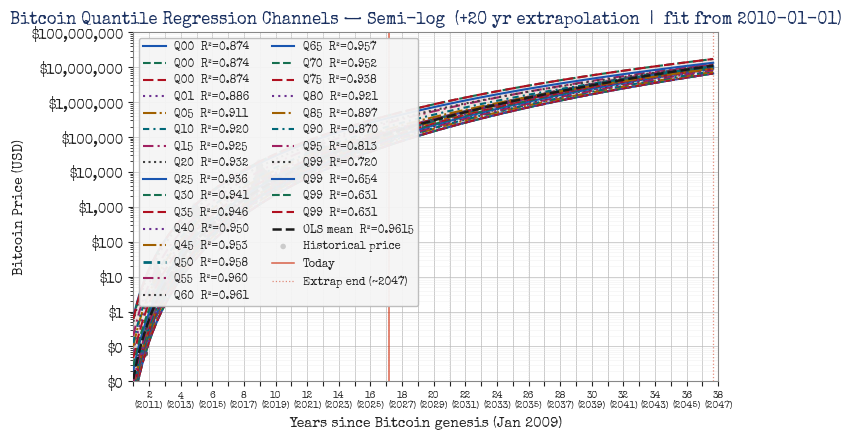

  Saved qr_loglog.svg/.jpg


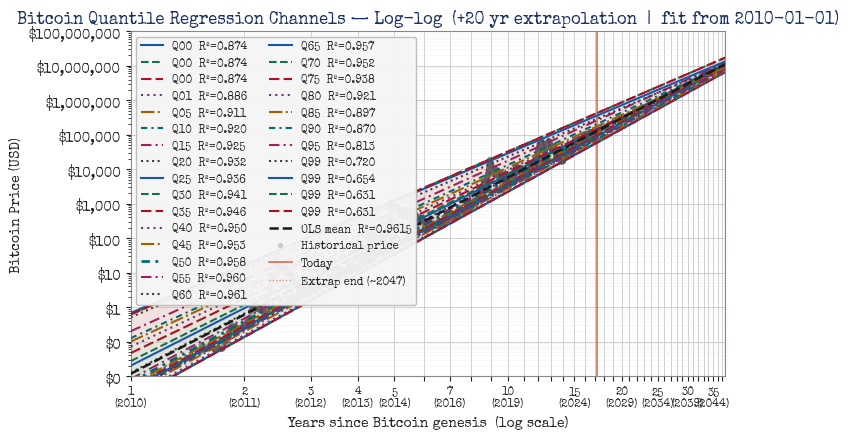

  Saved qr_zoomed.svg/.jpg


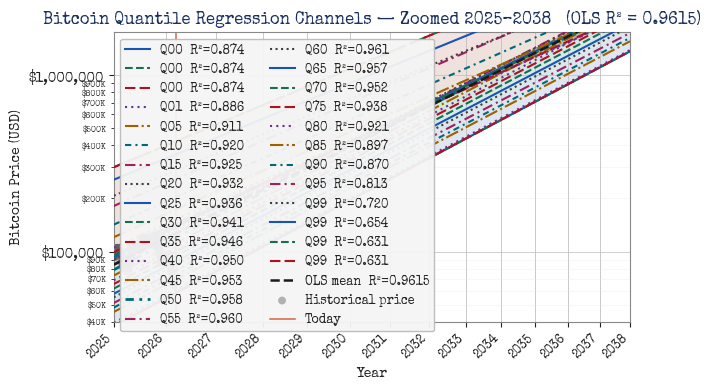

  Saved qr_bubble_overlay.svg/.jpg


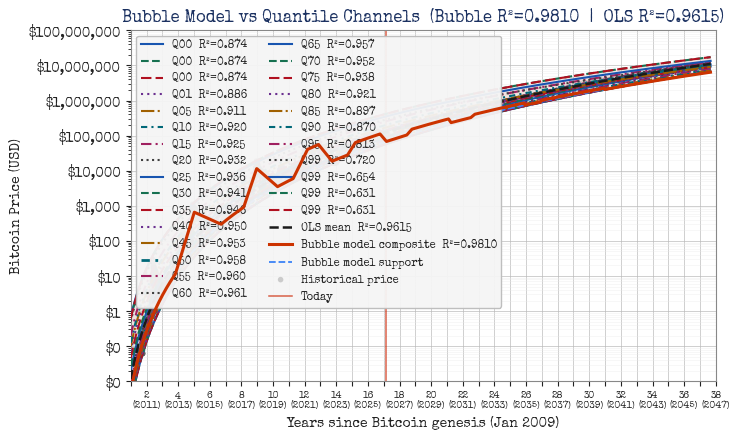

  Saved qr_bubble_overlay_zoomed.svg/.jpg


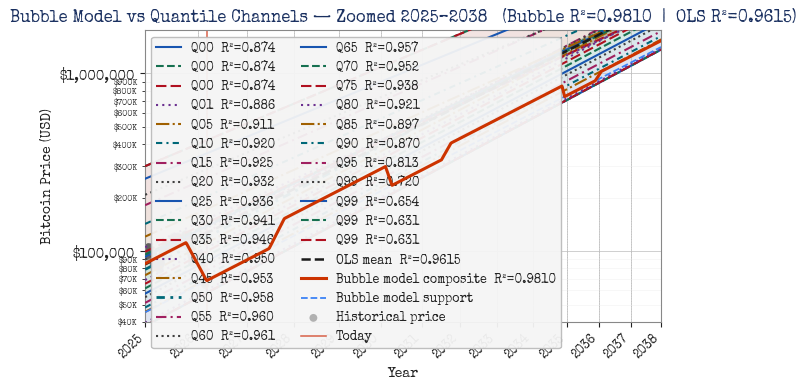


TABLE 1 — PRICE (USD) AT JAN 1 OF EACH YEAR × QUANTILE
  Year             Q00             Q00             Q00             Q01             Q05             Q10             Q15             Q20             Q25             Q30             Q35             Q40             Q45             Q50             Q55             Q60             Q65             Q70             Q75             Q80             Q85             Q90             Q95             Q99             Q99             Q99             Q99
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  2025  $       37,966  $       39,473  $       45,465  $       48


Saved qr_cagr_heatmap.svg/.jpg


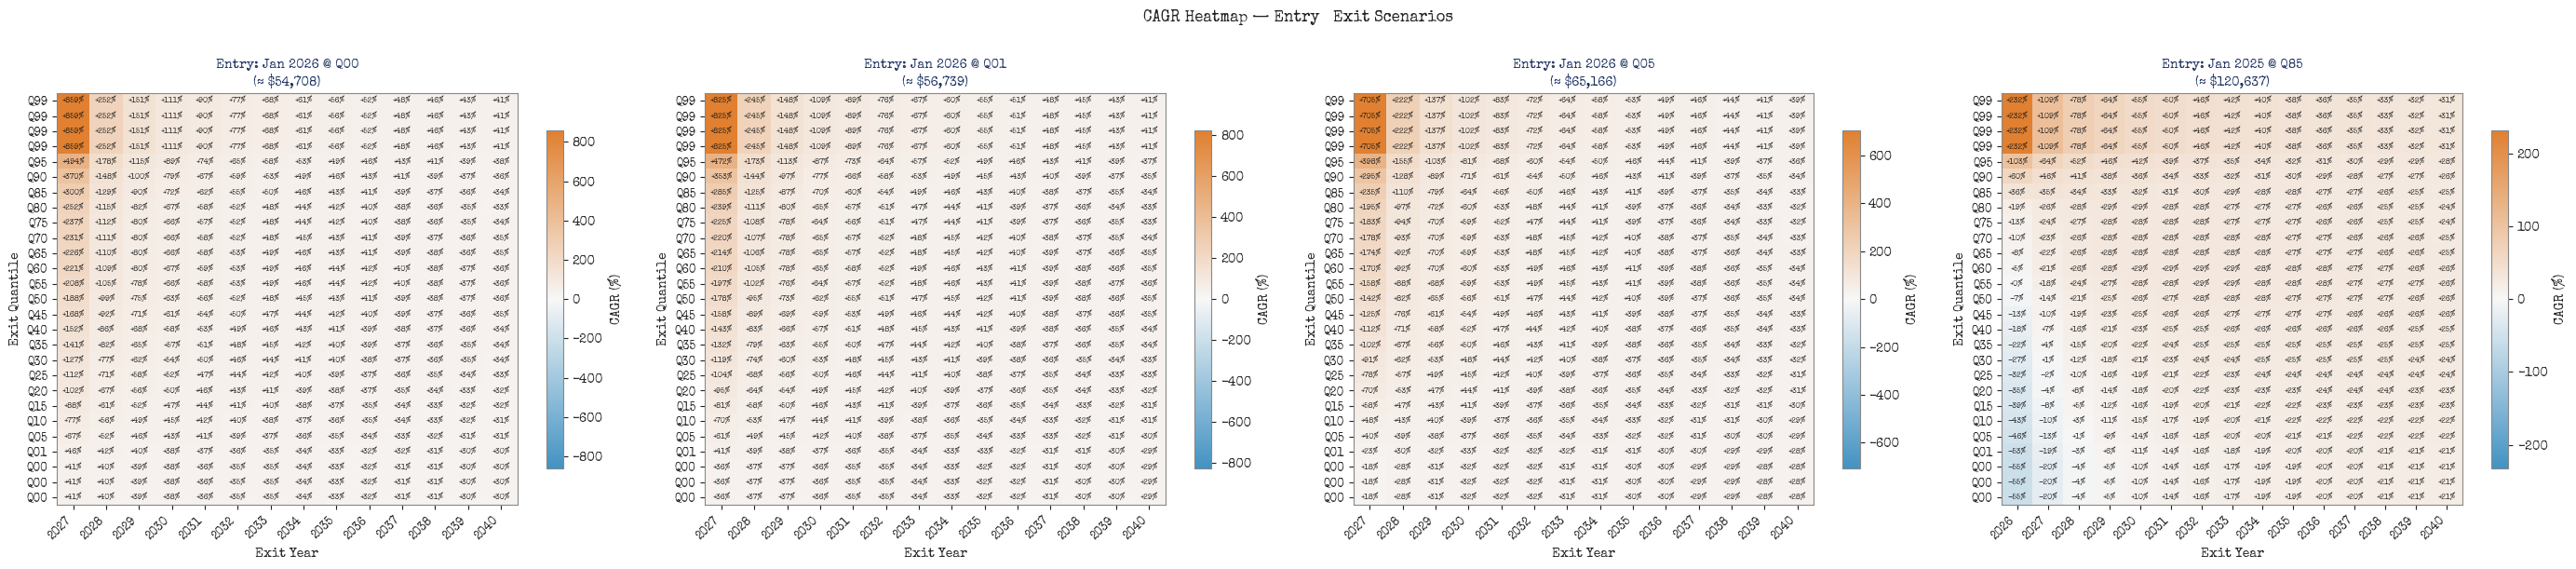


Saved qr_cagr_heatmap_scaled.svg/.jpg


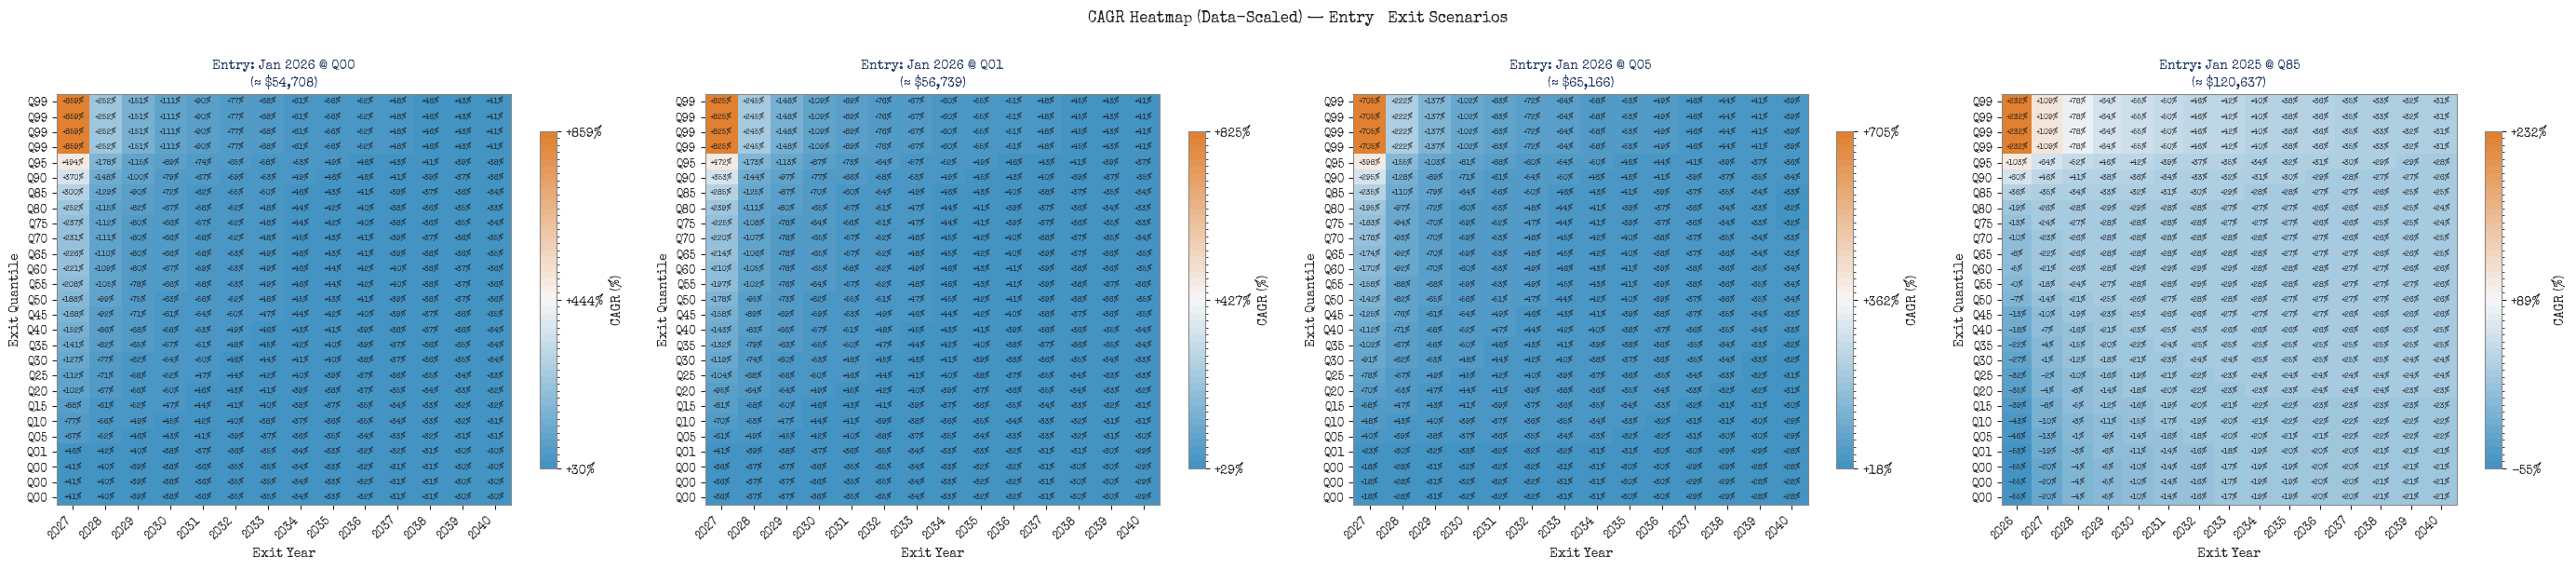


Saved qr_cagr_heatmap_seg.svg/.jpg


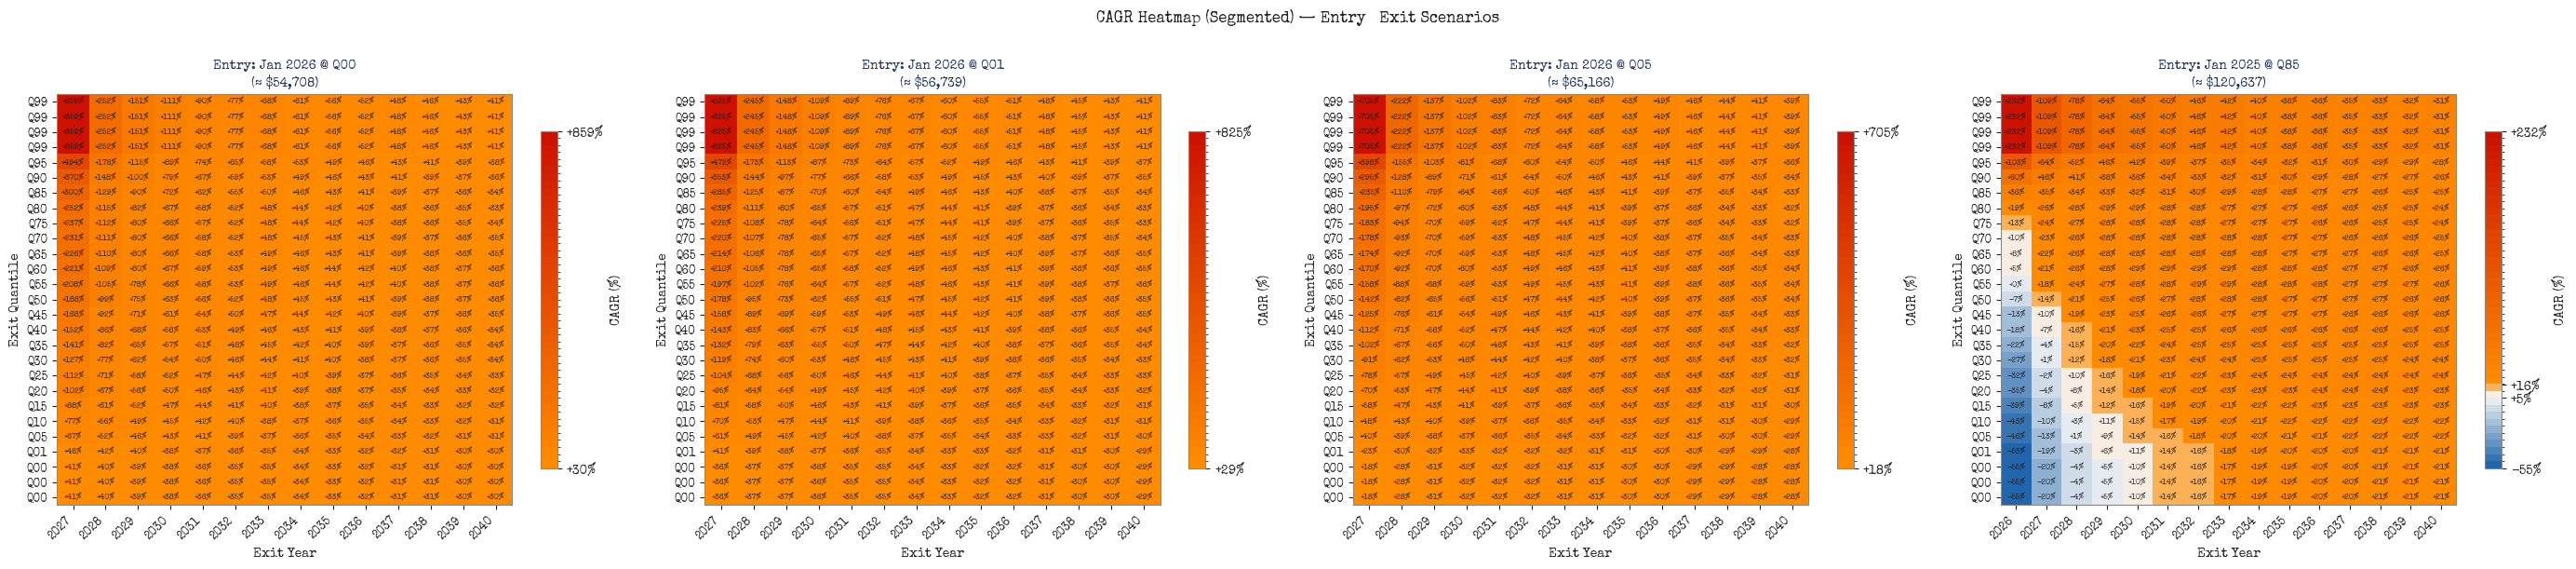


Saved qr_percentile_4panel.svg/.jpg


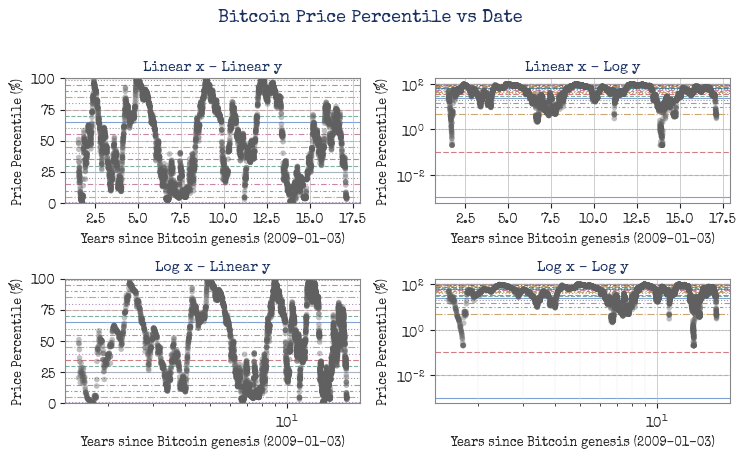


Saved qr_percentile_exp_4panel.svg/.jpg


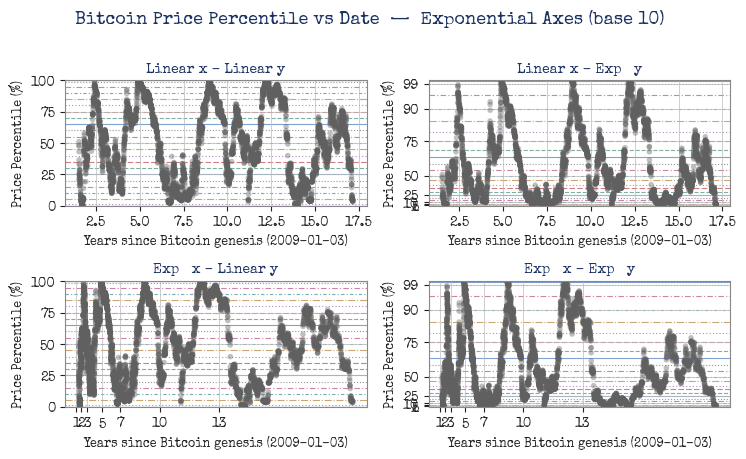


Saved qr_percentile_logexp_4panel.svg/.jpg


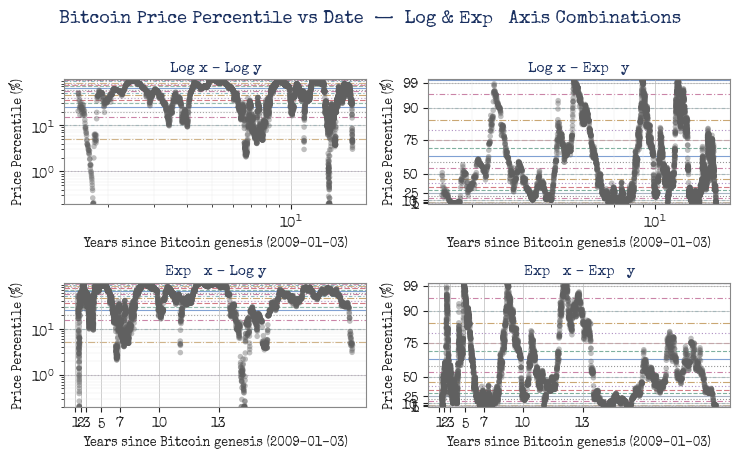

  Saved qr_table_price.svg/.jpg


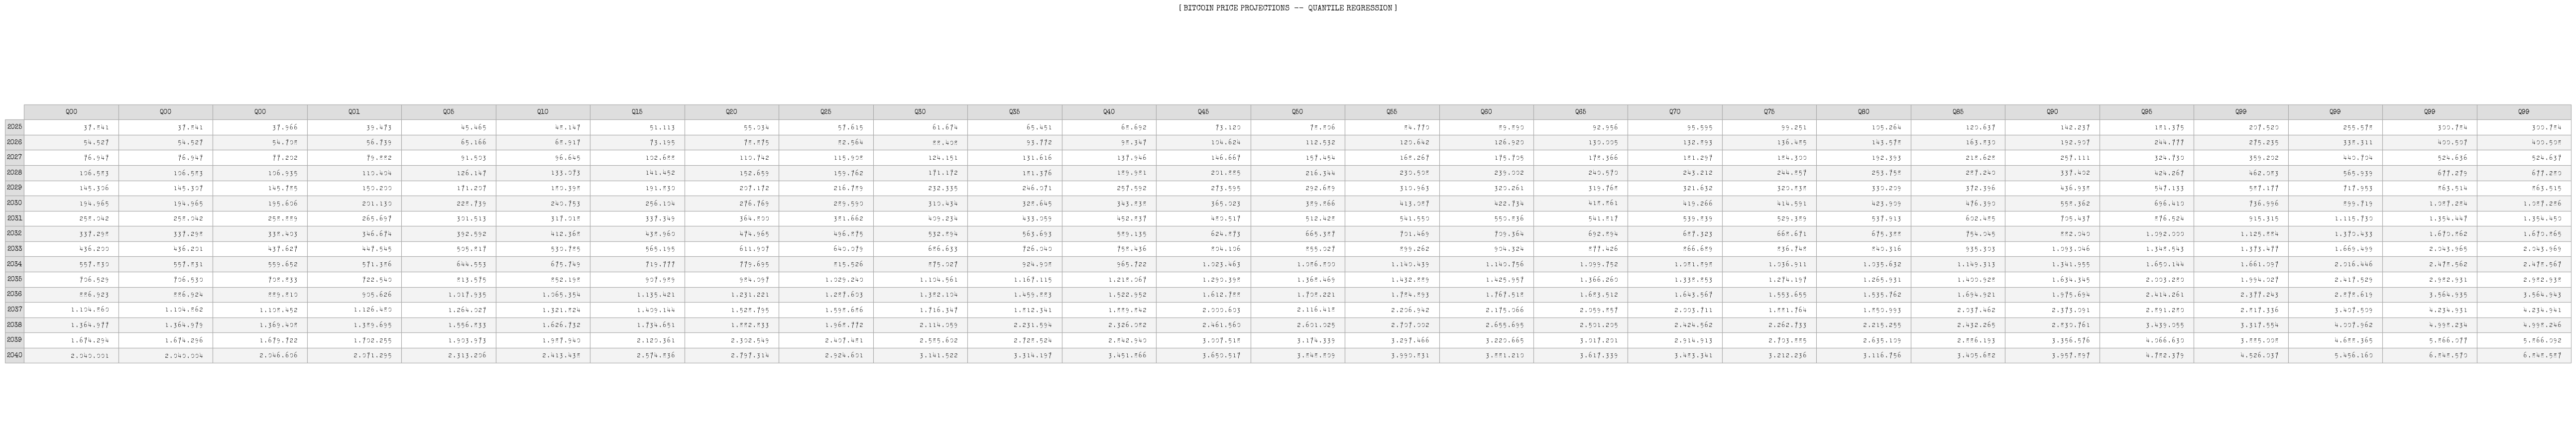

  Saved qr_table_cagr_q00_2026.svg/.jpg


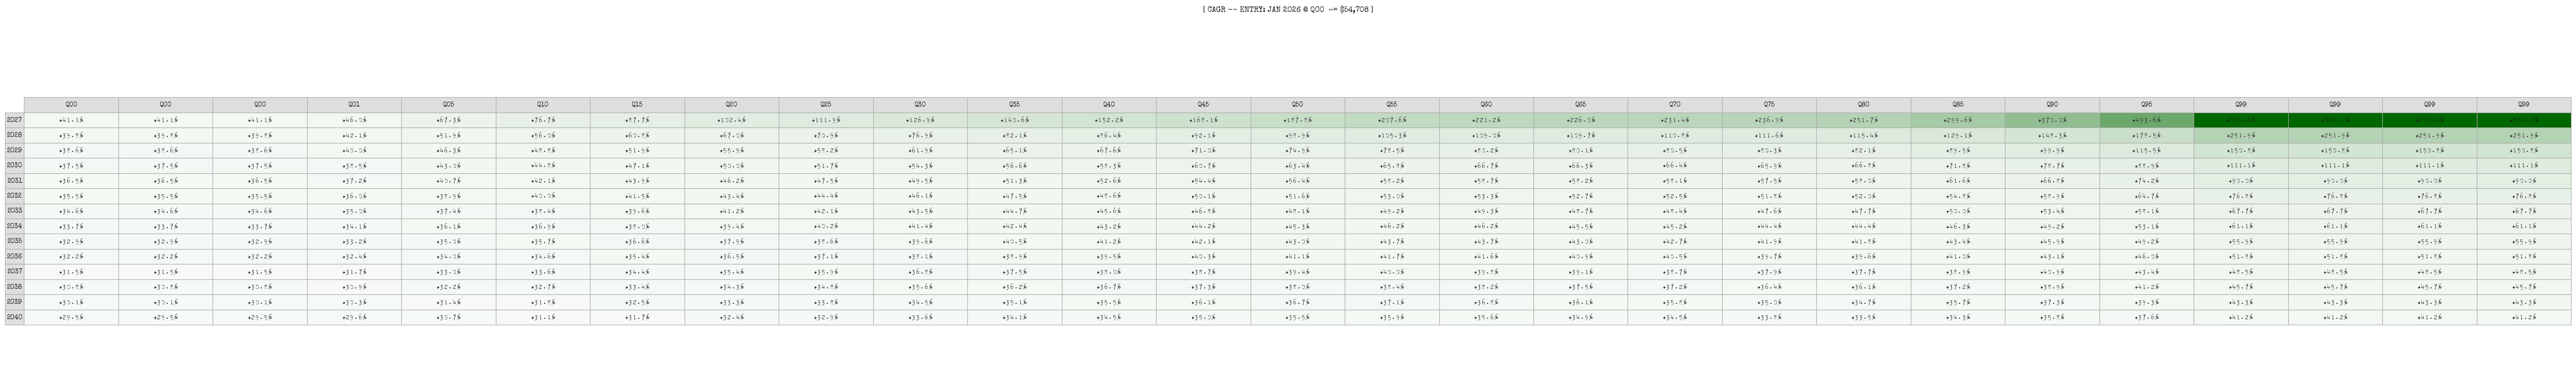

  Saved qr_table_cagr_q01_2026.svg/.jpg


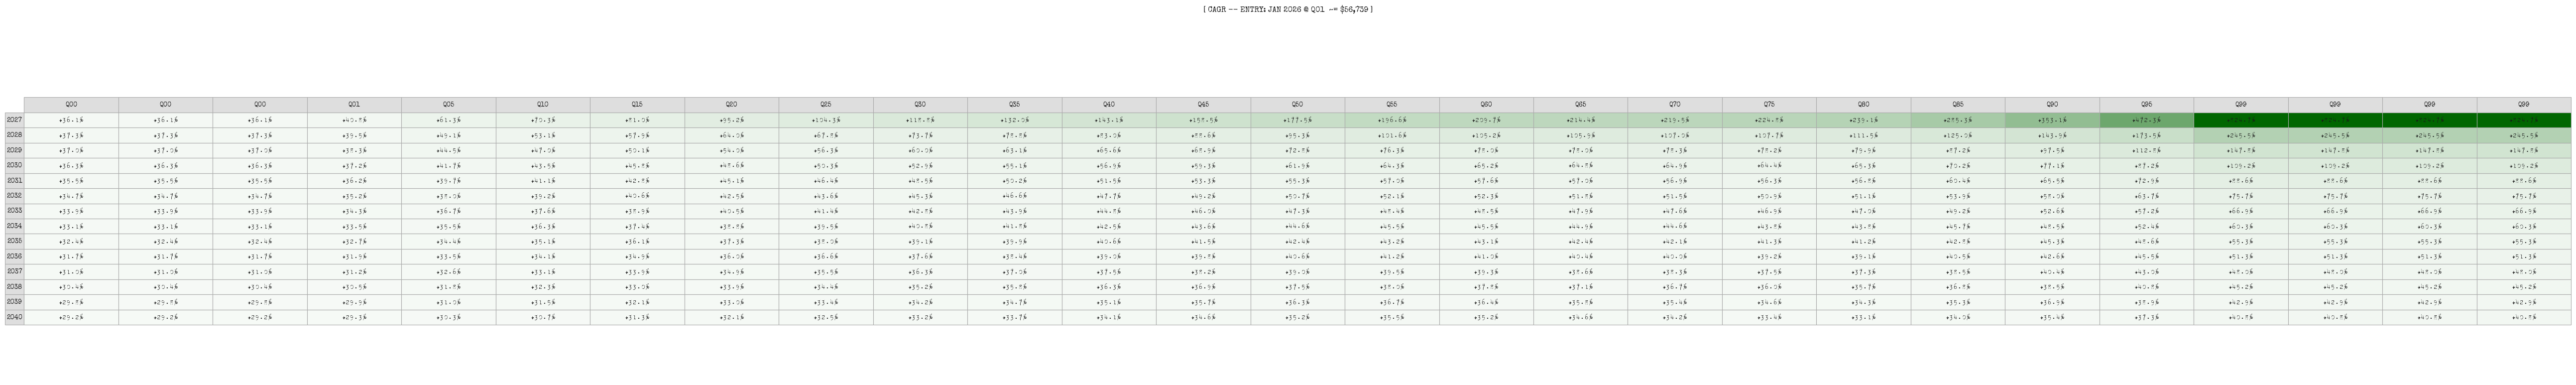

  Saved qr_table_cagr_q05_2026.svg/.jpg


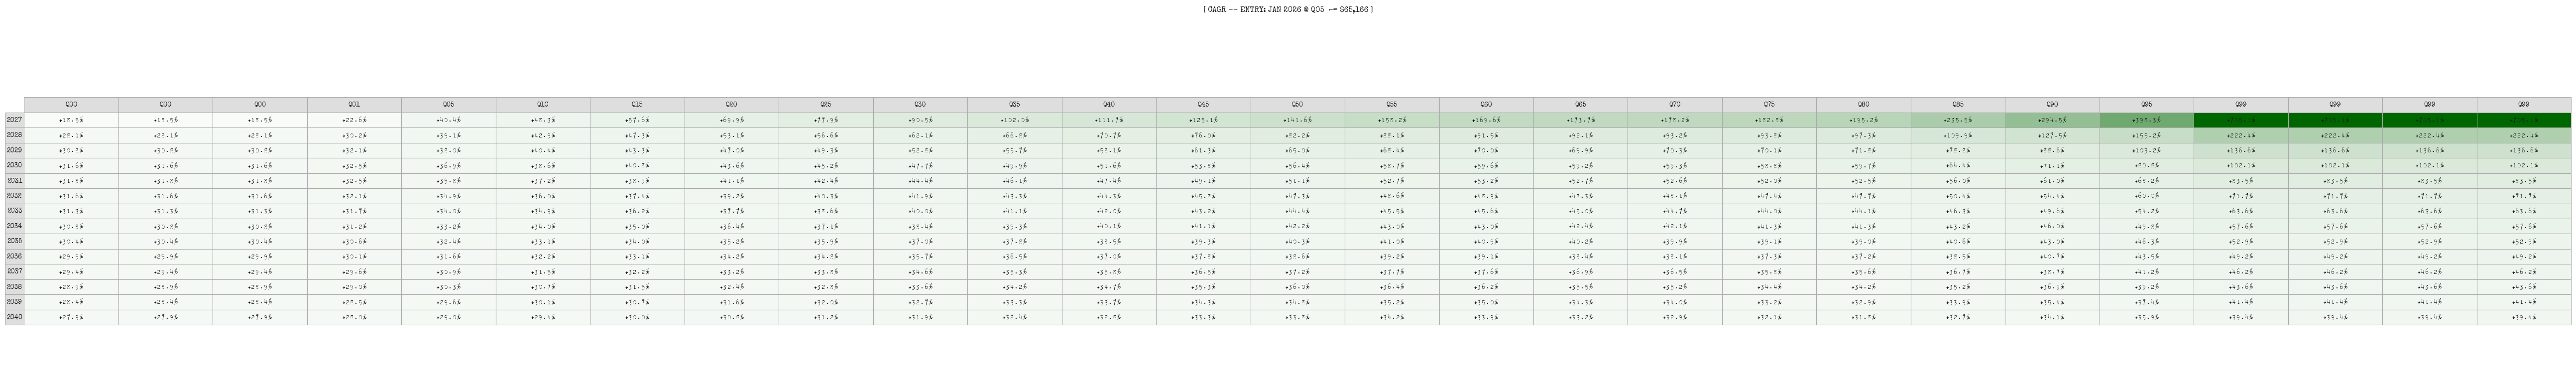

  Saved qr_table_cagr_q85_2025.svg/.jpg


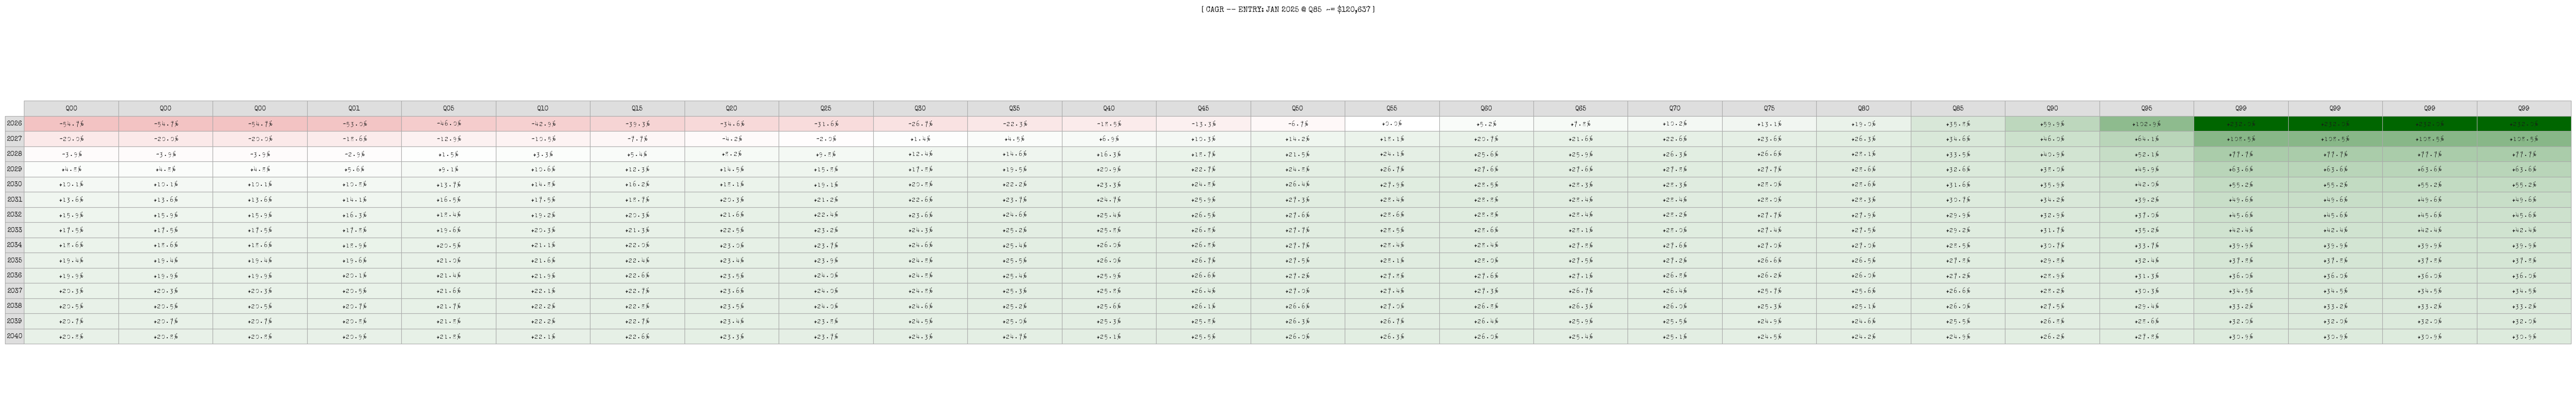

In [2]:
# Reset to inline backend in case interactive cell (cell 4) was run first
try:
    _ip = get_ipython()  # noqa: F821
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# ══════════════════════════════════════════════════════════════════════════════
# QUANTILE REGRESSION CHANNEL MODEL
# Standalone cell — self-contained: loads data, fits power-law quantile
# regressions in log-log space, then produces:
#   Plot 1 — semi-log channels  (log price, linear time) + OLS + R²
#   Plot 2 — log-log channels   (log price, log time)    + OLS + R²
#   Plot 3 — zoomed semi-log    (2025-2035)               + OLS + R²
#   Plot 4 — bubble model overlay (requires cell 0 to have been run)
#   Table 1 — price at each quantile for years 2026-2036
#   Table 2 — CAGR heatmap from chosen entry scenarios
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from matplotlib.ticker import (FixedLocator, MultipleLocator, StrMethodFormatter,
                                NullFormatter, LogFormatter, FuncFormatter)
from scipy.stats import linregress
from statsmodels.regression.quantile_regression import QuantReg
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

csv_path     = './BitcoinPricesDaily.csv'
GENESIS_DATE = pd.Timestamp('2009-07-25')
FIT_MIN_DATE = '2010-01-01'

#QR_QUANTILES = [0.01, 0.1, 0.05, 0.15, 0.20, 0.25, 0.5, 0.8]
QR_QUANTILES = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99, 0.999, 0.9999, 0.99999]
#QR_QUANTILES = [0.001, 0.05, 0.1, 0.15, 0.20, 0.25]
# Quantiles to fit and plot.  Adjacent pairs are shaded.
# Must be strictly increasing, values in (0, 1).

EXTRAP_YEARS = 20
# Years to extrapolate beyond today on all plots.

TABLE_YEARS  = list(range(2025, 2041))
# Calendar years for the price table rows and CAGR exit years.

ZOOM_YEAR_LO  = 2025      # zoomed chart left bound (calendar year)
ZOOM_YEAR_HI  = 2038      # zoomed chart right bound (calendar year)
ZOOM_PRICE_LO = 4e4       # zoomed chart lower price limit (USD)
ZOOM_PRICE_HI = 1.75e6       # zoomed chart upper price limit (USD)

CAGR_FROM_SCENARIOS = [
    (2026, 0.001),   # 
    (2026, 0.01),   # 
    (2026, 0.05),   # 
    (2025, 0.85),   # entry: 5th-pct price in 2026 (buying at a dip)
#    (2027, 0.5),   # entry: 5th-pct price in 2027 (buying at a dip)
#    (2030, 0.90),   # entry: 5th-pct price in 2036 (buying at a dip)
]

CAGR_HEATMAP_FONTSIZE = 6
# Font size for the annotated numbers inside each CAGR heatmap cell.
# Reduce if cells are crowded (e.g. 7 or 8); increase for larger figures.

# ── Data-scaled heatmap colour variables ─────────────────────────────────
CAGR_COLOR_MIN  = '#4393C3'   # blue  — lowest  CAGR in the scaled heatmap
CAGR_COLOR_MID  = '#F7F7F7'   # white — midpoint between min and max
CAGR_COLOR_MAX  = '#E08030'   # amber — highest CAGR in the scaled heatmap
CAGR_GRAD_STEPS = 24          # discrete colour bands on each side of midpoint
CAGR_SEG_B1     =  5.0      # % CAGR — boundary 1: blue→white ends here
CAGR_SEG_B2     = 16.0      # % CAGR — boundary 2: orange→red starts here
CAGR_SEG_C_LO   = '#2166AC' # deep blue     at data-min
CAGR_SEG_C_MID1 = '#F7F7F7' # white         at CAGR_SEG_B1
CAGR_SEG_C_MID2 = '#FF8C00' # bright orange at CAGR_SEG_B2
CAGR_SEG_C_HI   = '#CC1100' # bright red    at data-max

# ── Futuristic + Typewriter colour theme ──────────────────────────────
# Quantile colormap: deep navy -> electric blue -> cyan -> lime -> neon gold
QR_CMAP = mcolors.LinearSegmentedColormap.from_list('print_bands', [
    '#2040A0', '#208080', '#208040', '#806020', '#A03020'])

# Diverging colormap for CAGR: neon red -> dark navy -> electric green
MIL_DIV_CMAP = mcolors.LinearSegmentedColormap.from_list('cb_div', [
    '#4393C3',   # CB-safe medium blue  (negative / low CAGR)
    '#F7F7F7',   # near-white neutral centre
    '#E08030'])  # CB-safe amber orange (positive / high CAGR)

CHART_FONT       = 'Special Elite'  # old typewriter font
PLOT_BG_COLOR    = '#FFFFFF'   # white
SPINE_COLOR      = '#888888'   # medium gray frame
TEXT_COLOR       = '#222222'   # near black
TITLE_COLOR      = '#1A3060'   # dark navy
LEGEND_BG_COLOR  = '#F5F5F5'   # very light gray legend bg
DATA_COLOR       = '#606060'   # medium gray scatter
DATA_PT_SIZE     = 16         # scatter point size for all standard charts
DATA_PT_SIZE_ZOOM = 32          # scatter point size for the zoomed chart
OLS_COLOR        = '#1A1A1A'   # near black OLS mean line
GRID_MAJOR_COLOR = '#BBBBBB'   # medium gray major grid
GRID_MINOR_COLOR = '#E8E8E8'   # very light gray minor grid
TODAY_COLOR      = '#CC2200'   # dark red today line
BUBBLE_COLOR     = '#CC3300'   # dark red-orange bubble composite

# Colorblind-friendly Okabe-Ito colour cycle and line-style cycle.
# Auto-assigned by index to whatever quantiles are in QR_QUANTILES,
# so adding/removing quantiles never causes a KeyError.
_CB_COLORS = [
    '#1855B0',   # medium blue
    '#167050',   # dark green
    '#B01020',   # dark red
    '#6B3090',   # dark purple
    '#A06000',   # dark amber
    '#006878',   # dark teal
    '#A02060',   # dark magenta
    '#404040',   # dark charcoal
]
_CB_STYLES = [
    '-',               # solid
    '--',              # dashed
    (0, (5, 2)),       # long dash
    (0, (1, 2)),       # dotted
    '-.',              # dash-dot
    (0, (3,2,1,2)),   # dash-dot-dot
    (0, (5,2,1,2)),   # long-dash-dot
    ':',               # dense dotted
]

PRICE_YMIN = 0.01
PRICE_YMAX = 1e8
PLOT_YEARS_MIN = 1.0
PLOT_GRID_PTS  = 8000
CHART_DPI      = 100
# Resolution of saved JPG files in dots-per-inch.
# Higher = larger file, more detail. 150 = draft, 200 = default, 300 = print.

CHART_W        = 15*0.5     # width  (inches) for standard charts
CHART_H        = 9*0.5   # height (inches) for standard charts
CHART_ZOOM_W   = 13*0.5     # width  (inches) for the zoomed chart
CHART_ZOOM_H   = 8*0.5      # height (inches) for the zoomed chart


# ══════════════════════════════════════════════════════════════════════════════
# APPLY MILITARY MATPLOTLIB THEME
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.font_manager as _fm
_fm._load_fontmanager(try_read_cache=False)   # pick up Special Elite & 1942 report

plt.rcParams.update({
    'figure.facecolor':   PLOT_BG_COLOR,
    'axes.facecolor':     PLOT_BG_COLOR,
    'axes.edgecolor':     SPINE_COLOR,
    'axes.labelcolor':    TEXT_COLOR,
    'axes.titlecolor':    TITLE_COLOR,
    'xtick.color':        TEXT_COLOR,
    'ytick.color':        TEXT_COLOR,
    'text.color':         TEXT_COLOR,
    'legend.facecolor':   LEGEND_BG_COLOR,
    'legend.edgecolor':   SPINE_COLOR,
    'legend.labelcolor':  TEXT_COLOR,
    'legend.framealpha':  0.88,
    'font.family':        [CHART_FONT],
})

# ══════════════════════════════════════════════════════════════════════════════
# LOAD + PREPARE DATA
# ══════════════════════════════════════════════════════════════════════════════

try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df.columns = df.columns.str.strip()
date_col  = next((c for c in df.columns if 'date'  in c.lower()), df.columns[0])
price_col = next((c for c in df.columns if any(k in c.lower()
                  for k in ['close', 'price', 'usd'])),           df.columns[1])

df = (df[[date_col, price_col]]
      .rename(columns={date_col: 'date', price_col: 'price'})
      .assign(date=lambda d: pd.to_datetime(d['date']))
      .sort_values('date').reset_index(drop=True))
df = df[df['price'] > 0].dropna()

df['years']     = (df['date'] - GENESIS_DATE).dt.days / 365.25
df['log_years'] = np.log10(df['years'])
df['log_price'] = np.log10(df['price'])

fit_mask = df['date'] >= pd.Timestamp(FIT_MIN_DATE)
df_fit   = df[fit_mask].copy()
X_fit    = np.column_stack([np.ones(len(df_fit)), df_fit['log_years'].values])

today_yr      = (pd.Timestamp.today() - GENESIS_DATE).days / 365.25
PLOT_YEARS_MAX = today_yr + EXTRAP_YEARS + 0.5   # extends 20 yr past today

print(f"Data  : {df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()}"
      f"  ({len(df):,} rows)")
print(f"Fit   : {FIT_MIN_DATE} onwards  ({len(df_fit):,} rows)")
print(f"Today : year {today_yr:.2f} since genesis"
      f"  |  extrapolating to year {PLOT_YEARS_MAX:.1f} (~{2009+PLOT_YEARS_MAX:.0f})")


# ══════════════════════════════════════════════════════════════════════════════
# FIT QUANTILE REGRESSIONS  +  OLS MEAN REGRESSION
# Model: log10(price) = intercept + slope · log10(t_years)   [power law]
# ══════════════════════════════════════════════════════════════════════════════

print(f"\nFitting OLS + {len(QR_QUANTILES)} quantile regressions ...")

# OLS (mean) regression
ols_slope, ols_intercept, ols_r, _, _ = linregress(
    df_fit['log_years'].values, df_fit['log_price'].values)
ols_r2 = ols_r ** 2
print(f"  OLS: log10(P) = {ols_intercept:+.4f} + {ols_slope:.4f}·log10(t)"
      f"   R² = {ols_r2:.4f}")

# Per-quantile R² (OLS formula applied to QR predictions — measures how well
# each channel tracks the conditional mean of the data)
ss_tot_fit = np.sum((df_fit['log_price'].values - df_fit['log_price'].mean()) ** 2)

qr_fits = {}
for q in QR_QUANTILES:
    res  = QuantReg(df_fit['log_price'].values, X_fit).fit(q=q, max_iter=2000)
    pred = res.params[0] + res.params[1] * df_fit['log_years'].values
    r2_q = 1 - np.sum((df_fit['log_price'].values - pred) ** 2) / ss_tot_fit
    qr_fits[q] = {'intercept': float(res.params[0]),
                  'slope':     float(res.params[1]),
                  'r2':        float(r2_q)}
    print(f"  Q{int(q*100):02d}: log10(P) = {res.params[0]:+.4f}"
          f" + {res.params[1]:.4f}·log10(t)   R² = {r2_q:.4f}")


def qr_price(q, t_years):
    f = qr_fits[q]
    return 10.0 ** (f['intercept'] + f['slope'] * np.log10(np.asarray(t_years, float)))

def ols_price(t_years):
    return 10.0 ** (ols_intercept + ols_slope * np.log10(np.asarray(t_years, float)))

def yr_to_t(cal_year):
    return (pd.Timestamp(f'{cal_year}-01-01') - GENESIS_DATE).days / 365.25


# ══════════════════════════════════════════════════════════════════════════════
# SHARED PLOT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

norm       = mcolors.Normalize(vmin=0, vmax=1)
# Build per-quantile colour and line-style dicts from the index-based cycles
qr_colors     = {q: _CB_COLORS[i % len(_CB_COLORS)] for i, q in enumerate(QR_QUANTILES)}
QR_LINESTYLES = {q: _CB_STYLES[i % len(_CB_STYLES)]  for i, q in enumerate(QR_QUANTILES)}
years_plot = np.linspace(PLOT_YEARS_MIN, PLOT_YEARS_MAX, PLOT_GRID_PTS)
n_q        = len(QR_QUANTILES)

_maj_p = [0.01, 0.1, 1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
_min_p = [v * m
          for v in [1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7]
          for m in range(2, 10)]   # 8 minor ticks/decade, linear spacing within each decade


def _draw_channels(ax, years, shade=True):
    """Draw shaded bands + quantile lines on ax (price already in log scale)."""
    n_bands = n_q - 1
    for i in range(n_bands):
        q_lo, q_hi = QR_QUANTILES[i], QR_QUANTILES[i + 1]
        dist = abs((i + 0.5) / n_bands - 0.5) * 2
        alpha = 0.20 - 0.08 * dist
        if shade:
            ax.fill_between(years, qr_price(q_lo, years), qr_price(q_hi, years),
                            color=QR_CMAP(norm((q_lo + q_hi) / 2)),
                            alpha=alpha, linewidth=0)
    for q in QR_QUANTILES:
        r2  = qr_fits[q]['r2']
        _lw = 2.0 if q == 0.50 else 1.5
        ax.plot(years, qr_price(q, years), color=qr_colors[q], lw=_lw, zorder=4,
                ls=QR_LINESTYLES[q], label=f'Q{int(q*100):02d}  R²={r2:.3f}')


def _draw_ols(ax, years):
    ax.plot(years, ols_price(years), color=OLS_COLOR, lw=1.8, ls='--',
            zorder=5, label=f'OLS mean  R²={ols_r2:.4f}')


def _draw_data(ax):
    ax.scatter(df['years'], df['price'], color=DATA_COLOR,
               s=DATA_PT_SIZE, alpha=0.28, edgecolor='none', label='Historical price', zorder=2)


def _draw_today(ax):
    ax.axvline(today_yr, color=TODAY_COLOR, ls='-', lw=1.1, alpha=0.7, label='Today')


def _price_yaxis(ax):
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(
        FixedLocator([t for t in _maj_p if PRICE_YMIN <= t <= PRICE_YMAX]))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_minor_locator(
        FixedLocator([t for t in _min_p if PRICE_YMIN <= t <= PRICE_YMAX]))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_ylim(PRICE_YMIN, PRICE_YMAX)


def _save_show(name):
    plt.tight_layout()
    plt.savefig(f'{name}.svg', format='svg', bbox_inches='tight')
    plt.savefig(f'{name}.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
    print(f"  Saved {name}.svg/.jpg")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1: SEMI-LOG CHANNELS  (log price, linear time)
# Extrapolated EXTRAP_YEARS years beyond today.
# ══════════════════════════════════════════════════════════════════════════════

x_ticks_sl = list(range(1, int(PLOT_YEARS_MAX) + 2))
x_labs_sl  = [f"{y}\n({2009+y})" if y % 2 == 0 else '' for y in x_ticks_sl]

fig, ax = plt.subplots(figsize=(CHART_W, CHART_H))
ax.set_facecolor(PLOT_BG_COLOR)
_price_yaxis(ax)
_draw_channels(ax, years_plot)
_draw_ols(ax, years_plot)
_draw_data(ax)
_draw_today(ax)
ax.axvline(years_plot[-1], color=TODAY_COLOR, ls=':', lw=0.9, alpha=0.5,
           label=f'Extrap end (~{2009+PLOT_YEARS_MAX:.0f})')
for yr_cal in TABLE_YEARS:
    ax.axvline(yr_to_t(yr_cal), color=GRID_MAJOR_COLOR, ls=':', lw=0.5, alpha=0.4)

ax.set_xlim(PLOT_YEARS_MIN, PLOT_YEARS_MAX)
ax.set_xticks(x_ticks_sl)
ax.set_xticklabels(x_labs_sl, fontsize=7)
ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.set_title(f'Bitcoin Quantile Regression Channels — Semi-log  '
             f'(+{EXTRAP_YEARS} yr extrapolation  |  fit from {FIT_MIN_DATE})')
ax.legend(fontsize=8, framealpha=0.95, edgecolor=GRID_MAJOR_COLOR, loc='upper left',
          ncol=2)
ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7, alpha=0.7)
ax.grid(True, which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
_save_show('qr_semilog')


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2: LOG-LOG CHANNELS  (log price, log time)
# Both axes log scale — the power-law regressions appear as straight lines.
# ══════════════════════════════════════════════════════════════════════════════

# Nice tick positions on the log-time x-axis (years since genesis)
_label_set_ll = {1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 35, 40}
_t_ticks_ll   = [t for t in range(1, int(PLOT_YEARS_MAX) + 2)
                 if PLOT_YEARS_MIN <= t <= PLOT_YEARS_MAX]
_t_labs_ll    = [f"{t}\n({2009+t})" if t in _label_set_ll else ''
                 for t in _t_ticks_ll]

fig, ax = plt.subplots(figsize=(CHART_W, CHART_H))
ax.set_facecolor(PLOT_BG_COLOR)
ax.set_xscale('log')
_price_yaxis(ax)
_draw_channels(ax, years_plot)
_draw_ols(ax, years_plot)
_draw_data(ax)
_draw_today(ax)
ax.axvline(years_plot[-1], color=TODAY_COLOR, ls=':', lw=0.9, alpha=0.5,
           label=f'Extrap end (~{2009+PLOT_YEARS_MAX:.0f})')

ax.set_xlim(PLOT_YEARS_MIN, PLOT_YEARS_MAX)
ax.xaxis.set_major_locator(FixedLocator(_t_ticks_ll))
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xticklabels(_t_labs_ll, fontsize=8)
ax.set_xlabel('Years since Bitcoin genesis  (log scale)')
ax.set_ylabel('Bitcoin Price (USD)')
ax.set_title(f'Bitcoin Quantile Regression Channels — Log-log  '
             f'(+{EXTRAP_YEARS} yr extrapolation  |  fit from {FIT_MIN_DATE})')
ax.legend(fontsize=8, framealpha=0.95, edgecolor=GRID_MAJOR_COLOR, loc='upper left',
          ncol=2)
ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7, alpha=0.7)
ax.grid(True, which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
_save_show('qr_loglog')


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3: ZOOMED — 2025-2035  (log-log, restricted x range)
# ══════════════════════════════════════════════════════════════════════════════

t_zoom_lo = yr_to_t(ZOOM_YEAR_LO)
t_zoom_hi = yr_to_t(ZOOM_YEAR_HI)
yrs_zoom  = np.linspace(t_zoom_lo, t_zoom_hi, 1000)

# Year-by-year x ticks inside the zoom window
x_ticks_zm = [yr_to_t(y) for y in range(ZOOM_YEAR_LO, ZOOM_YEAR_HI + 1)]
x_labs_zm  = [str(y) for y in range(ZOOM_YEAR_LO, ZOOM_YEAR_HI + 1)]

fig, ax = plt.subplots(figsize=(CHART_ZOOM_W, CHART_ZOOM_H))
ax.set_facecolor(PLOT_BG_COLOR)
ax.set_xscale('log')
ax.set_yscale('log')
_draw_channels(ax, yrs_zoom)
_draw_ols(ax, yrs_zoom)

# Historical scatter restricted to zoom window
_zoom_mask = (df['years'] >= t_zoom_lo) & (df['years'] <= t_zoom_hi)
ax.scatter(df.loc[_zoom_mask, 'years'], df.loc[_zoom_mask, 'price'],
           color=DATA_COLOR, s=DATA_PT_SIZE_ZOOM, alpha=0.45, edgecolor='none',
           label='Historical price', zorder=2)
_draw_today(ax)

# Year boundary verticals
for y_cal in range(ZOOM_YEAR_LO, ZOOM_YEAR_HI + 1):
    ax.axvline(yr_to_t(y_cal), color=GRID_MAJOR_COLOR, ls=':', lw=0.7, alpha=0.7)

# Zoom-specific price ticks
_maj_zm = [t for t in _maj_p if ZOOM_PRICE_LO <= t <= ZOOM_PRICE_HI]
_min_zm = [t for t in _min_p if ZOOM_PRICE_LO <= t <= ZOOM_PRICE_HI]
ax.yaxis.set_major_locator(FixedLocator(_maj_zm))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_minor_locator(FixedLocator(_min_zm))
ax.yaxis.set_minor_formatter(FuncFormatter(
    lambda x, _: f'${x/1e6:.2f}M' if x >= 1e6 else f'${int(x/1e3)}K'))
ax.tick_params(axis='y', which='minor', labelsize=6)
ax.set_xlim(t_zoom_lo, t_zoom_hi)
ax.set_ylim(ZOOM_PRICE_LO, ZOOM_PRICE_HI)
ax.set_xticks(x_ticks_zm)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xticklabels(x_labs_zm, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Year')
ax.set_ylabel('Bitcoin Price (USD)')
ax.set_title(f'Bitcoin Quantile Regression Channels — Zoomed {ZOOM_YEAR_LO}–{ZOOM_YEAR_HI}'
             f'   (OLS R² = {ols_r2:.4f})')
ax.legend(fontsize=9, framealpha=0.95, edgecolor=GRID_MAJOR_COLOR, loc='upper left',
          ncol=2)
ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7, alpha=0.7)
ax.grid(True, which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
# Bold all text on this chart
fig.canvas.draw()
plt.setp(ax.get_xticklabels(),        fontweight='bold')
plt.setp(ax.get_yticklabels(),         fontweight='bold')
plt.setp(ax.get_yticklabels(minor=True), fontweight='bold')
ax.xaxis.label.set_fontweight('bold')
ax.yaxis.label.set_fontweight('bold')
ax.title.set_fontweight('bold')
for _t in ax.get_legend().get_texts():
    _t.set_fontweight('bold')
_save_show('qr_zoomed')


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4: BUBBLE MODEL OVERLAY
# Overlays the parametric bubble composite from cell 0 onto the QR channels.
# Requires cell 0 to have been run first (variables in notebook namespace).
# ══════════════════════════════════════════════════════════════════════════════

try:
    _bm_yrs   = years_plot_bm          # from cell 0
    _bm_comp  = bm_composite_future    # composite + predicted bubbles
    _bm_sup   = support_plot_bm        # power-law support
    _bm_r2    = bm_r2_comp             # bubble model R²

    # Restrict bubble model range to our plot window
    _bm_mask  = (_bm_yrs >= PLOT_YEARS_MIN) & (_bm_yrs <= PLOT_YEARS_MAX)

    x_ticks_bm = list(range(1, int(PLOT_YEARS_MAX) + 2))
    x_labs_bm  = [f"{y}\n({2009+y})" if y % 2 == 0 else '' for y in x_ticks_bm]

    fig, ax = plt.subplots(figsize=(CHART_W, CHART_H))
    ax.set_facecolor(PLOT_BG_COLOR)
    _price_yaxis(ax)

    # QR channels as background context
    _draw_channels(ax, years_plot, shade=True)
    _draw_ols(ax, years_plot)

    # Bubble model composite
    ax.plot(_bm_yrs[_bm_mask], _bm_comp[_bm_mask],
            color=BUBBLE_COLOR, lw=2.2, zorder=6,
            label=f'Bubble model composite  R²={_bm_r2:.4f}')
    ax.plot(_bm_yrs[_bm_mask], _bm_sup[_bm_mask],
            color='#3B82F6', lw=1.3, ls='--', zorder=5,
            label='Bubble model support')

    _draw_data(ax)
    _draw_today(ax)

    ax.set_xlim(PLOT_YEARS_MIN, PLOT_YEARS_MAX)
    ax.set_xticks(x_ticks_bm)
    ax.set_xticklabels(x_labs_bm, fontsize=7)
    ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)')
    ax.set_ylabel('Bitcoin Price (USD)')
    ax.set_title(f'Bubble Model vs Quantile Channels  '
                 f'(Bubble R²={_bm_r2:.4f}  |  OLS R²={ols_r2:.4f})')
    ax.legend(fontsize=8, framealpha=0.95, edgecolor=GRID_MAJOR_COLOR,
              loc='upper left', ncol=2)
    ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7, alpha=0.7)
    ax.grid(True, which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
    _save_show('qr_bubble_overlay')

    # ── PLOT 4b: BUBBLE OVERLAY — ZOOMED (log-log) ─────────────────────────
    _bm_zoom = (_bm_yrs >= t_zoom_lo) & (_bm_yrs <= t_zoom_hi)

    fig, ax = plt.subplots(figsize=(CHART_ZOOM_W, CHART_ZOOM_H))
    ax.set_facecolor(PLOT_BG_COLOR)
    ax.set_xscale('log')
    ax.set_yscale('log')
    _draw_channels(ax, yrs_zoom, shade=True)
    _draw_ols(ax, yrs_zoom)

    ax.plot(_bm_yrs[_bm_zoom], _bm_comp[_bm_zoom],
            color=BUBBLE_COLOR, lw=2.2, zorder=6,
            label=f'Bubble model composite  R²={_bm_r2:.4f}')
    ax.plot(_bm_yrs[_bm_zoom], _bm_sup[_bm_zoom],
            color='#3B82F6', lw=1.3, ls='--', zorder=5,
            label='Bubble model support')

    ax.scatter(df.loc[_zoom_mask, 'years'], df.loc[_zoom_mask, 'price'],
               color=DATA_COLOR, s=DATA_PT_SIZE_ZOOM, alpha=0.45, edgecolor='none',
               label='Historical price', zorder=2)
    _draw_today(ax)

    for y_cal in range(ZOOM_YEAR_LO, ZOOM_YEAR_HI + 1):
        ax.axvline(yr_to_t(y_cal), color=GRID_MAJOR_COLOR, ls=':', lw=0.7, alpha=0.7)

    ax.yaxis.set_major_locator(FixedLocator(_maj_zm))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_minor_locator(FixedLocator(_min_zm))
    ax.yaxis.set_minor_formatter(FuncFormatter(
        lambda x, _: f'${x/1e6:.2f}M' if x >= 1e6 else f'${int(x/1e3)}K'))
    ax.tick_params(axis='y', which='minor', labelsize=6)
    ax.set_xlim(t_zoom_lo, t_zoom_hi)
    ax.set_ylim(ZOOM_PRICE_LO, ZOOM_PRICE_HI)
    ax.set_xticks(x_ticks_zm)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xticklabels(x_labs_zm, fontsize=9, rotation=45, ha='right')
    ax.set_xlabel('Year')
    ax.set_ylabel('Bitcoin Price (USD)')
    ax.set_title(f'Bubble Model vs Quantile Channels — Zoomed {ZOOM_YEAR_LO}–{ZOOM_YEAR_HI}'
                 f'   (Bubble R²={_bm_r2:.4f}  |  OLS R²={ols_r2:.4f})')
    ax.legend(fontsize=9, framealpha=0.95, edgecolor=GRID_MAJOR_COLOR,
              loc='upper left', ncol=2)
    ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7, alpha=0.7)
    ax.grid(True, which='minor', axis='y', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
    fig.canvas.draw()
    plt.setp(ax.get_xticklabels(),          fontweight='bold')
    plt.setp(ax.get_yticklabels(),           fontweight='bold')
    plt.setp(ax.get_yticklabels(minor=True), fontweight='bold')
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.title.set_fontweight('bold')
    for _t in ax.get_legend().get_texts():
        _t.set_fontweight('bold')
    _save_show('qr_bubble_overlay_zoomed')

except NameError as _e:
    print(f"\n  Plot 4 skipped — bubble model variable not found ({_e})."
          f"\n  Run cell 0 first, then re-run this cell.")


# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1: PRICE AT EACH QUANTILE × YEAR (2026–2036)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("TABLE 1 — PRICE (USD) AT JAN 1 OF EACH YEAR × QUANTILE")
print("=" * 80)

col_names  = [f"Q{int(q*100):02d}" for q in QR_QUANTILES]
price_rows = []
for cal_yr in TABLE_YEARS:
    t = yr_to_t(cal_yr)
    price_rows.append({cn: qr_price(q, t) for cn, q in zip(col_names, QR_QUANTILES)})

price_df = pd.DataFrame(price_rows, index=TABLE_YEARS)
price_df.index.name = 'Year'

header = f"{'Year':>6}  " + "  ".join(f"{c:>14}" for c in col_names)
print(header)
print("-" * len(header))
for yr, row in price_df.iterrows():
    vals = "  ".join(f"${v:>13,.0f}" for v in row)
    print(f"{yr:>6}  {vals}")


# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2: CAGR FROM ENTRY SCENARIO → (EXIT YEAR × EXIT QUANTILE)
# CAGR = (exit_price / entry_price)^(1 / n_years) − 1
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("TABLE 2 — CAGR (annualised)  ENTRY → (EXIT YEAR × EXIT QUANTILE)")
print("=" * 80)

cagr_blocks = {}
for (from_yr, from_q) in CAGR_FROM_SCENARIOS:
    from_price = qr_price(from_q, yr_to_t(from_yr))
    exit_years = [y for y in TABLE_YEARS if y > from_yr]

    rows = []
    for to_yr in exit_years:
        n_yrs = to_yr - from_yr
        to_t  = yr_to_t(to_yr)
        rows.append({cn: (qr_price(q, to_t) / from_price) ** (1.0 / n_yrs) - 1.0
                     for cn, q in zip(col_names, QR_QUANTILES)})

    cagr_df = pd.DataFrame(rows, index=exit_years)
    cagr_df.index.name = 'Exit Year'
    cagr_blocks[(from_yr, from_q)] = cagr_df

    print(f"\n  Entry: Jan {from_yr} @ Q{int(from_q*100):02d}  (≈ ${from_price:,.0f})"
          f"   |   n_years = exit_year − {from_yr}")
    hdr = f"  {'Exit Yr':>8}  " + "  ".join(f"{c:>9}" for c in col_names)
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for yr, row in cagr_df.iterrows():
        vals = "  ".join(f"{v*100:>+8.1f}%" for v in row)
        print(f"  {yr:>8}  {vals}")


# ══════════════════════════════════════════════════════════════════════════════
# CAGR HEATMAP — one subplot per entry scenario
# ══════════════════════════════════════════════════════════════════════════════

n_scen = len(CAGR_FROM_SCENARIOS)
fig, axes = plt.subplots(1, n_scen, figsize=(7 * n_scen, 6), squeeze=False)

for col_i, (from_yr, from_q) in enumerate(CAGR_FROM_SCENARIOS):
    ax         = axes[0][col_i]
    from_price = qr_price(from_q, yr_to_t(from_yr))
    cagr_df    = cagr_blocks[(from_yr, from_q)]
    exit_years = list(cagr_df.index)

    # Rows = quantiles (Q90 top → Q10 bottom), cols = exit years
    q_order = list(reversed(QR_QUANTILES))
    mat = np.array([[cagr_df.loc[y, f"Q{int(q*100):02d}"] * 100
                     for y in exit_years] for q in q_order])

    vmax = max(np.abs(mat).max(), 10)
    im = ax.imshow(mat, aspect='auto', cmap=MIL_DIV_CMAP,
                   vmin=-vmax, vmax=vmax, origin='upper')

    for ri in range(len(q_order)):
        for ci in range(len(exit_years)):
            v = mat[ri, ci]
            ax.text(ci, ri, f'{v:+.0f}%', ha='center', va='center',
                    fontsize=CAGR_HEATMAP_FONTSIZE, color='#1A1A1A', fontweight='bold')

    ax.set_xticks(range(len(exit_years)))
    ax.set_xticklabels(exit_years, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(q_order)))
    ax.set_yticklabels([f'Q{int(q*100):02d}' for q in q_order], fontsize=9)
    ax.set_xlabel('Exit Year')
    ax.set_ylabel('Exit Quantile')
    ax.set_title(f'Entry: Jan {from_yr} @ Q{int(from_q*100):02d}\n'
                 f'(≈ ${from_price:,.0f})', fontsize=10)
    plt.colorbar(im, ax=ax, label='CAGR (%)', shrink=0.82)

plt.suptitle('CAGR Heatmap — Entry → Exit Scenarios', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('qr_cagr_heatmap.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_cagr_heatmap.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_cagr_heatmap.svg/.jpg")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# CAGR HEATMAP — DATA-SCALED  (min→blue, midpoint→white, max→amber, discrete)
# ══════════════════════════════════════════════════════════════════════════════

_n_disc = 2 * CAGR_GRAD_STEPS   # total discrete colour bands
_base_s = mcolors.LinearSegmentedColormap.from_list(
    '_scaled', [CAGR_COLOR_MIN, CAGR_COLOR_MID, CAGR_COLOR_MAX], N=_n_disc)
_disc_cmap = mcolors.ListedColormap(
    [_base_s(i / (_n_disc - 1)) for i in range(_n_disc)])

n_scen = len(CAGR_FROM_SCENARIOS)
fig, axes = plt.subplots(1, n_scen, figsize=(7 * n_scen, 6), squeeze=False)

for col_i, (from_yr, from_q) in enumerate(CAGR_FROM_SCENARIOS):
    ax         = axes[0][col_i]
    from_price = qr_price(from_q, yr_to_t(from_yr))
    cagr_df    = cagr_blocks[(from_yr, from_q)]
    exit_years = list(cagr_df.index)

    q_order = list(reversed(QR_QUANTILES))
    mat = np.array([[cagr_df.loc[y, f"Q{int(q*100):02d}"] * 100
                     for y in exit_years] for q in q_order])

    data_min = float(mat.min())
    data_max = float(mat.max())
    boundaries = np.linspace(data_min, data_max, _n_disc + 1)
    norm = mcolors.BoundaryNorm(boundaries, _disc_cmap.N)

    im = ax.imshow(mat, aspect='auto', cmap=_disc_cmap, norm=norm, origin='upper')

    for ri in range(len(q_order)):
        for ci in range(len(exit_years)):
            v = mat[ri, ci]
            ax.text(ci, ri, f'{v:+.0f}%', ha='center', va='center',
                    fontsize=CAGR_HEATMAP_FONTSIZE, color='#1A1A1A', fontweight='bold')

    ax.set_xticks(range(len(exit_years)))
    ax.set_xticklabels(exit_years, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(q_order)))
    ax.set_yticklabels([f'Q{int(q*100):02d}' for q in q_order], fontsize=9)
    ax.set_xlabel('Exit Year')
    ax.set_ylabel('Exit Quantile')
    ax.set_title(f'Entry: Jan {from_yr} @ Q{int(from_q*100):02d}\n'
                 f'(\u2248 ${from_price:,.0f})', fontsize=10)
    vcenter = (data_min + data_max) / 2
    cb = plt.colorbar(im, ax=ax, label='CAGR (%)', shrink=0.82)
    cb.set_ticks([data_min, vcenter, data_max])
    cb.set_ticklabels([f'{data_min:+.0f}%', f'{vcenter:+.0f}%', f'{data_max:+.0f}%'])

plt.suptitle('CAGR Heatmap (Data-Scaled) — Entry \u2192 Exit Scenarios',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('qr_cagr_heatmap_scaled.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_cagr_heatmap_scaled.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_cagr_heatmap_scaled.svg/.jpg")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CAGR HEATMAP — SEGMENTED  (blue→white <3%, light-yellow→orange 3–10%, dark-orange→red >10%)
# ══════════════════════════════════════════════════════════════════════════════

_n_seg_disc = 2 * CAGR_GRAD_STEPS   # discrete colour bands per subplot

n_scen = len(CAGR_FROM_SCENARIOS)
fig, axes = plt.subplots(1, n_scen, figsize=(7 * n_scen, 6), squeeze=False)

for col_i, (from_yr, from_q) in enumerate(CAGR_FROM_SCENARIOS):
    ax         = axes[0][col_i]
    from_price = qr_price(from_q, yr_to_t(from_yr))
    cagr_df    = cagr_blocks[(from_yr, from_q)]
    exit_years = list(cagr_df.index)
    q_order    = list(reversed(QR_QUANTILES))
    mat = np.array([[cagr_df.loc[y, f"Q{int(q*100):02d}"] * 100
                     for y in exit_years] for q in q_order])
    # Per-subplot colour scale — breakpoints are absolute CAGR% values;
    # only include a segment if its range is present in this subplot's data.
    _s_min = float(mat.min());  _s_max = float(mat.max())
    # Starting colour: determined by which segment _s_min falls in
    _s_c0 = (CAGR_SEG_C_LO   if _s_min <= CAGR_SEG_B1 else
             CAGR_SEG_C_MID1 if _s_min <= CAGR_SEG_B2 else
             CAGR_SEG_C_MID2)
    # Ending colour: determined by which segment _s_max falls in
    _s_c1 = (CAGR_SEG_C_MID1 if _s_max <= CAGR_SEG_B1 else
             CAGR_SEG_C_MID2 if _s_max <= CAGR_SEG_B2 else
             CAGR_SEG_C_HI)
    # Build anchors: start, any breakpoints strictly inside the range, end
    _s_anc = [(0.0, _s_c0)]
    if _s_min < CAGR_SEG_B1 < _s_max:
        _s_anc.append(((CAGR_SEG_B1 - _s_min) / (_s_max - _s_min), CAGR_SEG_C_MID1))
    if _s_min < CAGR_SEG_B2 < _s_max:
        _s_anc.append(((CAGR_SEG_B2 - _s_min) / (_s_max - _s_min), CAGR_SEG_C_MID2))
    _s_anc.append((1.0, _s_c1))
    _s_base = mcolors.LinearSegmentedColormap.from_list('seg3', _s_anc, N=512)
    _s_cmap = mcolors.ListedColormap(
        [_s_base(k / (_n_seg_disc - 1)) for k in range(_n_seg_disc)])
    _s_norm = mcolors.BoundaryNorm(
        np.linspace(_s_min, _s_max, _n_seg_disc + 1), _s_cmap.N)
    im = ax.imshow(mat, aspect='auto', cmap=_s_cmap, norm=_s_norm, origin='upper')
    for ri in range(len(q_order)):
        for ci in range(len(exit_years)):
            v = mat[ri, ci]
            ax.text(ci, ri, f'{v:+.0f}%', ha='center', va='center',
                    fontsize=CAGR_HEATMAP_FONTSIZE, color='#1A1A1A', fontweight='bold')
    ax.set_xticks(range(len(exit_years)))
    ax.set_xticklabels(exit_years, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(q_order)))
    ax.set_yticklabels([f'Q{int(q*100):02d}' for q in q_order], fontsize=9)
    ax.set_xlabel('Exit Year')
    ax.set_ylabel('Exit Quantile')
    ax.set_title(f'Entry: Jan {from_yr} @ Q{int(from_q*100):02d}\n'
                 f'(≈ ${from_price:,.0f})', fontsize=10)
    _cb_ticks = [_s_min]
    if _s_min < CAGR_SEG_B1 < _s_max:
        _cb_ticks.append(CAGR_SEG_B1)
    if _s_min < CAGR_SEG_B2 < _s_max:
        _cb_ticks.append(CAGR_SEG_B2)
    _cb_ticks.append(_s_max)
    cb = plt.colorbar(im, ax=ax, label='CAGR (%)', shrink=0.82)
    cb.set_ticks(_cb_ticks)
    cb.set_ticklabels([f'{t:+.0f}%' for t in _cb_ticks])

plt.suptitle('CAGR Heatmap (Segmented) — Entry → Exit Scenarios',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('qr_cagr_heatmap_seg.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_cagr_heatmap_seg.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_cagr_heatmap_seg.svg/.jpg")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# BITCOIN PRICE PERCENTILE vs DATE  (lin–lin, lin–log, log–lin, log–log)
# ══════════════════════════════════════════════════════════════════════════════

# For each historical price, estimate its percentile within the
# QR model's predicted distribution using log-space interpolation.
_sq    = sorted(QR_QUANTILES)
_pct_v = np.array([q * 100.0 for q in _sq])
_ph_t  = np.array(df['years'])
_ph_p  = np.array(df['price'])
_ph_perc = np.empty(len(_ph_t))
for _ii in range(len(_ph_t)):
    _preds = np.maximum(
        np.array([qr_price(q, _ph_t[_ii]) for q in _sq]), 1e-6)
    _ph_perc[_ii] = float(np.interp(
        np.log(max(_ph_p[_ii], 1e-6)),
        np.log(_preds), _pct_v,
        left=_pct_v[0], right=_pct_v[-1]))

_perc_log = np.clip(_ph_perc, 0.2, 99.8)   # safe clip for log y-axis

fig, axes = plt.subplots(2, 2, figsize=(CHART_W, CHART_H))
fig.patch.set_facecolor(PLOT_BG_COLOR)
_perc_panels = [
    (axes[0, 0], 'linear', 'linear', _ph_perc,  'Linear x – Linear y'),
    (axes[0, 1], 'linear', 'log',    _perc_log, 'Linear x – Log y'),
    (axes[1, 0], 'log',    'linear', _ph_perc,  'Log x – Linear y'),
    (axes[1, 1], 'log',    'log',    _perc_log, 'Log x – Log y'),
]
for ax, xsc, ysc, ys, ptitle in _perc_panels:
    ax.set_facecolor(PLOT_BG_COLOR)
    for _sp in ax.spines.values():
        _sp.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.5, zorder=0)
    ax.grid(True, which='minor', color=GRID_MINOR_COLOR, lw=0.3, zorder=0)
    for _q in _sq:
        ax.axhline(_q * 100, color=qr_colors[_q], lw=0.8,
                   ls=QR_LINESTYLES[_q], alpha=0.55, zorder=1)
    ax.scatter(_ph_t, ys, s=DATA_PT_SIZE, color=DATA_COLOR,
               alpha=0.4, edgecolor='none', zorder=2)
    ax.set_xscale(xsc)
    ax.set_yscale(ysc)
    ax.set_xlabel('Years since Bitcoin genesis (2009–01–03)',
                  color=TEXT_COLOR, fontsize=9)
    ax.set_ylabel('Price Percentile (%)', color=TEXT_COLOR, fontsize=9)
    ax.set_title(ptitle, color=TITLE_COLOR, fontsize=10)
    if ysc == 'linear':
        ax.set_ylim(0, 100)

plt.suptitle('Bitcoin Price Percentile vs Date', fontsize=13,
             color=TITLE_COLOR, y=1.01)
plt.tight_layout()
plt.savefig('qr_percentile_4panel.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_percentile_4panel.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_percentile_4panel.svg/.jpg")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# BITCOIN PRICE PERCENTILE vs DATE  —  EXPONENTIAL AXES (base 10)
# Forward transform: x_display = 10^(x / scale)
# x-scale = _max_t_hist (historical data span); y-scale = 100 (percentile)
# Reuses _ph_t, _ph_perc, _sq, qr_colors, QR_LINESTYLES from block above.
# ══════════════════════════════════════════════════════════════════════════════

_max_t_hist = float(_ph_t.max())

fig, axes = plt.subplots(2, 2, figsize=(CHART_W, CHART_H))
fig.patch.set_facecolor(PLOT_BG_COLOR)
_exp_panels = [
    (axes[0, 0], False, False, 'Linear x – Linear y'),
    (axes[0, 1], False, True,  'Linear x – Exp₁₀ y'),
    (axes[1, 0], True,  False, 'Exp₁₀ x – Linear y'),
    (axes[1, 1], True,  True,  'Exp₁₀ x – Exp₁₀ y'),
]
for ax, _ex, _ey, _pt in _exp_panels:
    ax.set_facecolor(PLOT_BG_COLOR)
    for _sp in ax.spines.values():
        _sp.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.5, zorder=0)
    ax.grid(True, which='minor', color=GRID_MINOR_COLOR, lw=0.3, zorder=0)
    if _ex:
        _mt = _max_t_hist
        ax.set_xscale('function', functions=(
            lambda x, _m=_mt: np.power(10.0, np.array(x, dtype=float) / _m),
            lambda q, _m=_mt: _m * np.log10(
                np.maximum(np.array(q, dtype=float), 1e-10))))
        ax.set_xticks([y for y in [1, 2, 3, 5, 7, 10, 13] if y <= _max_t_hist])
    if _ey:
        ax.set_yscale('function', functions=(
            lambda y: np.power(10.0, np.array(y, dtype=float) / 100.0),
            lambda q: 100.0 * np.log10(
                np.maximum(np.array(q, dtype=float), 1e-10))))
        ax.set_yticks([1, 5, 10, 25, 50, 75, 90, 99])
        ax.set_ylim(0.1, 100)
    else:
        ax.set_ylim(0, 100)
    for _q in _sq:
        ax.axhline(_q * 100, color=qr_colors[_q], lw=0.8,
                   ls=QR_LINESTYLES[_q], alpha=0.55, zorder=1)
    ax.scatter(_ph_t, _ph_perc, s=DATA_PT_SIZE, color=DATA_COLOR,
               alpha=0.4, edgecolor='none', zorder=2)
    ax.set_xlabel('Years since Bitcoin genesis (2009–01–03)',
                  color=TEXT_COLOR, fontsize=9)
    ax.set_ylabel('Price Percentile (%)', color=TEXT_COLOR, fontsize=9)
    ax.set_title(_pt, color=TITLE_COLOR, fontsize=10)

plt.suptitle(
    'Bitcoin Price Percentile vs Date  —  Exponential Axes (base 10)',
    fontsize=13, color=TITLE_COLOR, y=1.01)
plt.tight_layout()
plt.savefig('qr_percentile_exp_4panel.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_percentile_exp_4panel.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_percentile_exp_4panel.svg/.jpg")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# BITCOIN PRICE PERCENTILE vs DATE  —  LOG & EXP₁₀ AXIS COMBINATIONS  (4 panels)
# ══════════════════════════════════════════════════════════════════════════════

# Reuses _ph_t, _ph_perc, _sq, _max_t_hist, qr_colors, QR_LINESTYLES.
fig, axes = plt.subplots(2, 2, figsize=(CHART_W, CHART_H))
fig.patch.set_facecolor(PLOT_BG_COLOR)
_le_panels = [
    (axes[0, 0], 'log', 'log', 'Log x – Log y'),
    (axes[0, 1], 'log', 'exp', 'Log x – Exp₁₀ y'),
    (axes[1, 0], 'exp', 'log', 'Exp₁₀ x – Log y'),
    (axes[1, 1], 'exp', 'exp', 'Exp₁₀ x – Exp₁₀ y'),
]
for ax, _xsc, _ysc, _pt in _le_panels:
    ax.set_facecolor(PLOT_BG_COLOR)
    for _sp in ax.spines.values():
        _sp.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR)
    ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.5, zorder=0)
    ax.grid(True, which='minor', color=GRID_MINOR_COLOR, lw=0.3, zorder=0)
    if _xsc == 'log':
        ax.set_xscale('log')
    else:
        _mt = _max_t_hist
        ax.set_xscale('function', functions=(
            lambda x, _m=_mt: np.power(10.0, np.array(x, dtype=float) / _m),
            lambda q, _m=_mt: _m * np.log10(
                np.maximum(np.array(q, dtype=float), 1e-10))))
        ax.set_xticks([y for y in [1, 2, 3, 5, 7, 10, 13] if y <= _max_t_hist])
    if _ysc == 'log':
        ax.set_yscale('log')
        ax.set_ylim(0.2, 99.8)
        ax.scatter(_ph_t, _perc_log, s=DATA_PT_SIZE, color=DATA_COLOR,
                   alpha=0.4, edgecolor='none', zorder=2)
    else:
        ax.set_yscale('function', functions=(
            lambda y: np.power(10.0, np.array(y, dtype=float) / 100.0),
            lambda q: 100.0 * np.log10(
                np.maximum(np.array(q, dtype=float), 1e-10))))
        ax.set_yticks([1, 5, 10, 25, 50, 75, 90, 99])
        ax.set_ylim(0.1, 100)
        ax.scatter(_ph_t, _ph_perc, s=DATA_PT_SIZE, color=DATA_COLOR,
                   alpha=0.4, edgecolor='none', zorder=2)
    for _q in _sq:
        ax.axhline(_q * 100, color=qr_colors[_q], lw=0.8,
                   ls=QR_LINESTYLES[_q], alpha=0.55, zorder=1)
    ax.set_xlabel('Years since Bitcoin genesis (2009–01–03)',
                  color=TEXT_COLOR, fontsize=9)
    ax.set_ylabel('Price Percentile (%)', color=TEXT_COLOR, fontsize=9)
    ax.set_title(_pt, color=TITLE_COLOR, fontsize=10)

plt.suptitle(
    'Bitcoin Price Percentile vs Date  —  Log & Exp₁₀ Axis Combinations',
    fontsize=13, color=TITLE_COLOR, y=1.01)
plt.tight_layout()
plt.savefig('qr_percentile_logexp_4panel.svg', format='svg', bbox_inches='tight')
plt.savefig('qr_percentile_logexp_4panel.jpg', format='jpg', bbox_inches='tight', dpi=CHART_DPI)
print(f"\nSaved qr_percentile_logexp_4panel.svg/.jpg")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# TYPEWRITER TABLE IMAGES
# Renders Table 1 and Table 2 as image files with an aged-parchment,
# monospace typewriter aesthetic.
# ══════════════════════════════════════════════════════════════════════════════

_TW_PAPER     = '#FFFFFF'   # white
_TW_PAPER2    = '#F3F3F3'   # alternating row -- very light gray
_TW_HEADER    = '#DEDEDE'   # light gray header
_TW_INK       = '#1A1A1A'   # near black text
_TW_BORDER    = '#AAAAAA'   # medium gray rule lines
_TW_FONT      = 'Special Elite'    # headers, row labels, title
_TW_BODY_FONT = '1942 report'      # data cell body text
_TW_POS       = '#006600'   # dark green  (positive CAGR)
_TW_NEG       = '#CC0000'   # dark red    (negative CAGR)
_TW_SEP    = '\u2500' * 72   # ─────── box-drawing separator


def _tw_style(tbl, cell_bg=None):
    """Apply typewriter theme to a matplotlib Table object."""
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.65)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor(_TW_BORDER)
        cell.set_linewidth(0.8)
        cell.get_text().set_color(_TW_INK)
        if r == 0 or c == -1:                      # header / row-label column
            cell.get_text().set_fontfamily(_TW_FONT)
            cell.set_facecolor(_TW_HEADER)
            cell.get_text().set_fontweight('bold')
        elif cell_bg is not None:
            cell.get_text().set_fontfamily(_TW_BODY_FONT)
            cell.set_facecolor(cell_bg[r - 1][c])
        else:
            cell.get_text().set_fontfamily(_TW_BODY_FONT)
            cell.set_facecolor(_TW_PAPER if r % 2 == 1 else _TW_PAPER2)


def _tw_save(name, title_text):
    """Add typewriter-style title banner and save the current figure."""
    fig = plt.gcf()
    fig.text(0.5, 0.975, title_text, ha='center', va='top',
             fontsize=11, fontweight='bold', fontfamily=_TW_FONT, color=_TW_INK)
    fig.text(0.5, 0.940, _TW_SEP, ha='center', va='top',
             fontsize=6.5, fontfamily=_TW_FONT, color=_TW_BORDER)
    plt.tight_layout(rect=[0.01, 0.01, 0.99, 0.90])
    plt.savefig(f'{name}.svg', format='svg', bbox_inches='tight',
                facecolor=_TW_PAPER, pad_inches=0.25)
    plt.savefig(f'{name}.jpg', format='jpg', bbox_inches='tight',
                dpi=CHART_DPI, facecolor=_TW_PAPER, pad_inches=0.25)
    print(f"  Saved {name}.svg/.jpg")
    plt.show()


def _cagr_bg(mat, vmax):
    """Map CAGR matrix (%) to warm parchment-tinted cell backgrounds."""
    paper = np.array(mcolors.to_rgb(_TW_PAPER))
    pos   = np.array(mcolors.to_rgb(_TW_POS))
    neg   = np.array(mcolors.to_rgb(_TW_NEG))
    bg = []
    for row in mat:
        bg_row = []
        for v in row:
            t = float(np.clip(v / vmax, -1.0, 1.0))
            c = (paper + t * (pos - paper)) if t >= 0 else (paper + (-t) * (neg - paper))
            bg_row.append(tuple(c))
        bg.append(bg_row)
    return bg


# ── Table 1 image: price at each quantile ────────────────────────────────────

_col_q       = [f"Q{int(q*100):02d}" for q in QR_QUANTILES]
_col_q_price = [f"Q{int(q*100):02d}" for q in QR_QUANTILES]
# Per-column number width so $ signs align across all rows
_t1_col_w = [max(len(f"{qr_price(q, yr_to_t(y)):,.0f}") for y in TABLE_YEARS)
             for q in QR_QUANTILES]
_t1_data = [
    [f"${qr_price(q, yr_to_t(y)):{_t1_col_w[qi]},.0f}"
     for qi, q in enumerate(QR_QUANTILES)]
    for y in TABLE_YEARS
]
_t1_rows = [str(y) for y in TABLE_YEARS]

_nc1, _nr1 = len(_col_q), len(_t1_rows)
fig, ax = plt.subplots(figsize=(_nc1 * 1.90 + 1.6, _nr1 * 0.44 + 1.8))
fig.patch.set_facecolor(_TW_PAPER)
ax.set_facecolor(_TW_PAPER)
ax.axis('off')
tbl = ax.table(cellText=_t1_data, rowLabels=_t1_rows, colLabels=_col_q_price,
               cellLoc='right', rowLoc='center', colLoc='center', loc='center')
_tw_style(tbl)
_tw_save('qr_table_price',
         '[ BITCOIN PRICE PROJECTIONS  --  QUANTILE REGRESSION ]')


# ── Table 2 images: CAGR per entry scenario ───────────────────────────────────

for (_from_yr, _from_q) in CAGR_FROM_SCENARIOS:
    _from_price = qr_price(_from_q, yr_to_t(_from_yr))
    _cdf        = cagr_blocks[(_from_yr, _from_q)]
    _exit_yrs   = list(_cdf.index)

    _c2_data, _c2_mat = [], []
    for _to_yr in _exit_yrs:
        _row_txt, _row_num = [], []
        for _q in QR_QUANTILES:
            _v = _cdf.loc[_to_yr, f"Q{int(_q*100):02d}"] * 100
            _row_txt.append(f"{_v:+.1f}%")
            _row_num.append(_v)
        _c2_data.append(_row_txt)
        _c2_mat.append(_row_num)

    _c2_mat  = np.array(_c2_mat)
    _vmax    = max(float(np.abs(_c2_mat).max()), 10.0)
    _c2_bg   = _cagr_bg(_c2_mat, _vmax)
    _c2_rows = [str(y) for y in _exit_yrs]

    _nc2, _nr2 = len(_col_q), len(_exit_yrs)
    fig, ax = plt.subplots(figsize=(_nc2 * 1.90 + 1.6, _nr2 * 0.44 + 1.8))
    fig.patch.set_facecolor(_TW_PAPER)
    ax.set_facecolor(_TW_PAPER)
    ax.axis('off')
    tbl = ax.table(cellText=_c2_data, rowLabels=_c2_rows, colLabels=_col_q,
                   cellLoc='center', rowLoc='center', colLoc='center', loc='center')
    _tw_style(tbl, cell_bg=_c2_bg)
    _slug = f"q{int(_from_q*100):02d}_{_from_yr}"
    _tw_save(f'qr_table_cagr_{_slug}',
             f'[ CAGR -- ENTRY: JAN {_from_yr} @ Q{int(_from_q*100):02d}'
             f'  ~= ${_from_price:,.0f} ]')


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# POWERPOINT PRESENTATION  —  bitcoin_projections.pptx
# Standalone cell. Assembles all saved chart and table images into a
# dark Bitcoin-themed deck, plus editable data tables for price and CAGR.
# Requires: python-pptx   (pipx inject jupyter python-pptx)
#           Pillow        (usually pre-installed with matplotlib)
# ══════════════════════════════════════════════════════════════════════════════

import os, glob
from datetime import date
from PIL import Image as _PIL
_PIL.MAX_IMAGE_PIXELS = None  # allow high-DPI images
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx.enum.shapes import MSO_AUTO_SHAPE_TYPE
from pptx.oxml.ns import qn
from lxml import etree

PPTX_FILE = 'bitcoin_projections.pptx'

# ── Slide geometry ────────────────────────────────────────────────────────────
SLD_W = Inches(13.333)
SLD_H = Inches(7.5)

TITLE_TOP    = Inches(0.12)
TITLE_H      = Inches(0.60)
SUB_TOP      = Inches(0.68)
SUB_H        = Inches(0.30)
RULE_TOP     = Inches(1.02)
CONTENT_TOP  = Inches(1.12)
CONTENT_H    = SLD_H - CONTENT_TOP - Inches(0.08)
CONTENT_W    = SLD_W - Inches(0.84)

# ── Theme colours ─────────────────────────────────────────────────────────────
C_BG      = RGBColor(0x0D, 0x1B, 0x2A)
C_ORANGE  = RGBColor(0xF7, 0x93, 0x1A)
C_BLUE    = RGBColor(0x3B, 0x82, 0xF6)
C_WHITE   = RGBColor(0xE8, 0xE8, 0xE8)
C_GREY    = RGBColor(0x88, 0x88, 0x88)
C_HDR     = RGBColor(0x1A, 0x3A, 0x60)   # table header bg
C_ROW1    = RGBColor(0x0D, 0x1B, 0x2A)   # table row bg (odd)
C_ROW2    = RGBColor(0x13, 0x26, 0x3C)   # table row bg (even)
C_POS     = RGBColor(0x22, 0x6B, 0x22)   # positive CAGR cell bg
C_NEG     = RGBColor(0x6B, 0x22, 0x22)   # negative CAGR cell bg
FONT_H    = 'Calibri'
FONT_D    = 'Liberation Mono'

prs = Presentation()
prs.slide_width  = SLD_W
prs.slide_height = SLD_H
_blank = prs.slide_layouts[6]


# ── Low-level helpers ─────────────────────────────────────────────────────────

def _bg(slide):
    fill = slide.background.fill
    fill.solid()
    fill.fore_color.rgb = C_BG


def _txt(slide, text, left, top, w, h, size=Pt(16), bold=False,
         color=C_WHITE, align=PP_ALIGN.LEFT, font=FONT_H, wrap=False):
    txb = slide.shapes.add_textbox(left, top, w, h)
    tf  = txb.text_frame
    tf.word_wrap = wrap
    p   = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text           = text
    run.font.size      = size
    run.font.bold      = bold
    run.font.color.rgb = color
    run.font.name      = font
    return txb


def _rule(slide, top=RULE_TOP, color=C_ORANGE):
    rect = slide.shapes.add_shape(
        MSO_AUTO_SHAPE_TYPE.RECTANGLE,
        Inches(0.35), top, Inches(12.63), Inches(0.016))
    rect.fill.solid()
    rect.fill.fore_color.rgb = color
    rect.line.fill.background()


def _title_bar(slide, title, subtitle=''):
    _txt(slide, title,
         Inches(0.35), TITLE_TOP, Inches(12.63), TITLE_H,
         size=Pt(22), bold=True, color=C_ORANGE)
    if subtitle:
        _txt(slide, subtitle,
             Inches(0.35), SUB_TOP, Inches(12.63), SUB_H,
             size=Pt(11), color=C_GREY)
    _rule(slide)


def _place_image(slide, img_path):
    with _PIL.open(img_path) as im:
        iw, ih = im.size
    emu_w = int(iw / 200 * 914400)   # saved at 200 dpi
    emu_h = int(ih / 200 * 914400)
    scale  = min(CONTENT_W / emu_w, CONTENT_H / emu_h)
    fw = int(emu_w * scale)
    fh = int(emu_h * scale)
    left = int((SLD_W - fw) / 2)
    slide.shapes.add_picture(img_path, left, CONTENT_TOP, width=fw, height=fh)


def _add_img_slide(title, img_path, subtitle=''):
    if not os.path.exists(img_path):
        print(f"  SKIP (not found): {img_path}")
        return
    s = prs.slides.add_slide(_blank)
    _bg(s);  _title_bar(s, title, subtitle)
    _place_image(s, img_path)
    print(f"  +  {title}")


def _section_slide(label):
    s = prs.slides.add_slide(_blank)
    _bg(s)
    _rule(s, top=Inches(3.08), color=C_BLUE)
    _rule(s, top=Inches(4.35), color=C_BLUE)
    _txt(s, label, Inches(0.5), Inches(3.18), Inches(12.33), Inches(1.1),
         size=Pt(38), bold=True, color=C_ORANGE, align=PP_ALIGN.CENTER)
    print(f"  +  [{label}]")


def _cell_set(cell, text, bg_rgb, text_rgb=C_WHITE, bold=False, sz=Pt(10), font=FONT_D):
    """Style a single pptx table cell."""
    cell.text = text
    cell.fill.solid()
    cell.fill.fore_color.rgb = bg_rgb
    p   = cell.text_frame.paragraphs[0]
    p.alignment = PP_ALIGN.CENTER
    run = p.runs[0] if p.runs else p.add_run()
    run.font.size      = sz
    run.font.bold      = bold
    run.font.color.rgb = text_rgb
    run.font.name      = font


# ── Title slide ───────────────────────────────────────────────────────────────

s = prs.slides.add_slide(_blank);  _bg(s)
_rule(s, top=Inches(2.95), color=C_ORANGE)
_rule(s, top=Inches(5.52), color=C_ORANGE)
_txt(s, '\u20bf', Inches(0.5), Inches(0.9), Inches(12.33), Inches(1.9),
     size=Pt(96), bold=True, color=C_ORANGE, align=PP_ALIGN.CENTER)
_txt(s, 'BITCOIN PRICE PROJECTIONS',
     Inches(0.5), Inches(3.06), Inches(12.33), Inches(0.95),
     size=Pt(38), bold=True, color=C_WHITE, align=PP_ALIGN.CENTER)
_txt(s, 'Quantile Regression  \u00b7  Bubble Model  \u00b7  CAGR Analysis',
     Inches(0.5), Inches(4.08), Inches(12.33), Inches(0.55),
     size=Pt(19), color=C_BLUE, align=PP_ALIGN.CENTER)
_txt(s, date.today().strftime('%B %Y'),
     Inches(0.5), Inches(4.72), Inches(12.33), Inches(0.5),
     size=Pt(14), color=C_GREY, align=PP_ALIGN.CENTER)
print("  +  Title slide")

# ── Chart slides ──────────────────────────────────────────────────────────────

_section_slide('CHARTS')
_add_img_slide('Semi-log Channels  |  QR + OLS  (+20 yr)',
               'qr_semilog.jpg',
               'Log price, linear time  \u2014  power-law quantile regression')
_add_img_slide('Log-log Channels  |  Power Law  (+20 yr)',
               'qr_loglog.jpg',
               'Log price, log time  \u2014  straight lines = perfect power law fit')
_add_img_slide('Zoomed View  2025\u20132035',
               'qr_zoomed.jpg',
               'Semi-log, annual x-ticks')
_add_img_slide('Bubble Model vs Quantile Channels',
               'qr_bubble_overlay.jpg',
               'Parametric bubble composite overlaid on QR channels')
_add_img_slide('Bubble Model vs Quantile Channels — Zoomed',
               'qr_bubble_overlay_zoomed.jpg',
               f'Zoomed {ZOOM_YEAR_LO}–{ZOOM_YEAR_HI}, log-log axes')
_add_img_slide('Price Percentile vs Date  |  Log & Linear Axes',
               'qr_percentile_4panel.jpg',
               'Percentile rank of historical price within QR model distribution')
_add_img_slide('Price Percentile vs Date  |  Exponential Axes (base 10)',
               'qr_percentile_exp_4panel.jpg',
               'Same data with base-10 exponential axis transforms')
_add_img_slide('Price Percentile vs Date  |  Log & Exp (base 10) Combinations',
               'qr_percentile_logexp_4panel.jpg',
               'All 4 combinations of log and exp (base 10) axes')

# ── Table image slides ────────────────────────────────────────────────────────

_section_slide('TABLES')
_add_img_slide('Price Projections  |  Jan 1st \u00d7 Quantile',
               'qr_table_price.jpg',
               'Power-law quantile regression \u2014 USD price at each percentile')
_add_img_slide('CAGR Heatmap  |  Entry \u2192 Exit Scenarios',
               'qr_cagr_heatmap.jpg')
_add_img_slide('CAGR Heatmap (Data-Scaled)  |  Entry \u2192 Exit Scenarios',
               'qr_cagr_heatmap_scaled.jpg')
_add_img_slide('CAGR Heatmap (Segmented)  |  Entry \u2192 Exit Scenarios',
               'qr_cagr_heatmap_seg.jpg',
               'Per-subplot scale: blue<3%, white=3%, orange=10%, red>10%')
for _f in sorted(glob.glob('qr_table_cagr_*.jpg')):
    _slug  = os.path.splitext(_f)[0].replace('qr_table_cagr_', '')
    _parts = _slug.split('_')
    _q_str = _parts[0].upper();  _yr = _parts[1] if len(_parts) > 1 else '?'
    _add_img_slide(f'CAGR Table  |  Entry: Jan {_yr} @ {_q_str}', _f,
                   'Annualised return vs exit year and exit quantile')

# ── Editable data slides ──────────────────────────────────────────────────────

_section_slide('DATA  (EDITABLE)')

# -- Price table slide ---------------------------------------------------------
_col_q_pptx = [f"Q{int(q*100):02d}" for q in QR_QUANTILES]

s = prs.slides.add_slide(_blank);  _bg(s)
_title_bar(s, 'Price Projections  |  Jan 1st of Each Year',
           'Power-law quantile regression (USD)')

n_rows_t = len(TABLE_YEARS) + 1   # +1 header
n_cols_t = len(_col_q_pptx) + 1   # +1 row-label col
tbl_w = Inches(10.0);  tbl_h = CONTENT_H
tbl_l = int((SLD_W - tbl_w) / 2)
tbl_shape = s.shapes.add_table(n_rows_t, n_cols_t, tbl_l, CONTENT_TOP, tbl_w, tbl_h)
tbl = tbl_shape.table

# Column widths
tbl.columns[0].width = Inches(1.2)
col_w = (tbl_w - Inches(1.2)) // len(_col_q_pptx)
for ci in range(1, n_cols_t):
    tbl.columns[ci].width = col_w

# Header row
_cell_set(tbl.cell(0, 0), 'Year', C_HDR, C_ORANGE, bold=True, font=FONT_H)
for ci, cname in enumerate(_col_q_pptx):
    _cell_set(tbl.cell(0, ci + 1), cname, C_HDR, C_ORANGE, bold=True, font=FONT_H)

# Data rows
for ri, yr in enumerate(TABLE_YEARS):
    bg = C_ROW1 if ri % 2 == 0 else C_ROW2
    _cell_set(tbl.cell(ri + 1, 0), str(yr), bg, C_ORANGE, bold=True, font=FONT_H)
    for ci, q in enumerate(QR_QUANTILES):
        val = qr_price(q, yr_to_t(yr))
        _cell_set(tbl.cell(ri + 1, ci + 1),
                  f"${val:,.0f}", bg, C_WHITE, font=FONT_D)
print("  +  Editable price table")

# -- CAGR table slides (one per scenario) -------------------------------------
for (from_yr, from_q) in CAGR_FROM_SCENARIOS:
    from_price = qr_price(from_q, yr_to_t(from_yr))
    cagr_df    = cagr_blocks[(from_yr, from_q)]
    exit_years = list(cagr_df.index)

    s = prs.slides.add_slide(_blank);  _bg(s)
    _title_bar(s,
               f'CAGR  |  Entry: Jan {from_yr} @ Q{int(from_q*100):02d}',
               f'Entry price \u2248 ${from_price:,.0f}  \u2014  annualised return to each exit scenario')

    n_rows_c = len(exit_years) + 1
    n_cols_c = len(_col_q_pptx) + 1
    tbl_shape2 = s.shapes.add_table(
        n_rows_c, n_cols_c, tbl_l, CONTENT_TOP, tbl_w, tbl_h)
    tbl2 = tbl_shape2.table
    tbl2.columns[0].width = Inches(1.2)
    for ci in range(1, n_cols_c):
        tbl2.columns[ci].width = col_w

    _cell_set(tbl2.cell(0, 0), 'Exit Yr', C_HDR, C_ORANGE, bold=True, font=FONT_H)
    for ci, cname in enumerate(_col_q_pptx):
        _cell_set(tbl2.cell(0, ci + 1), cname, C_HDR, C_ORANGE, bold=True, font=FONT_H)

    for ri, to_yr in enumerate(exit_years):
        bg = C_ROW1 if ri % 2 == 0 else C_ROW2
        _cell_set(tbl2.cell(ri + 1, 0), str(to_yr), bg, C_ORANGE, bold=True, font=FONT_H)
        for ci, q in enumerate(QR_QUANTILES):
            v = cagr_df.loc[to_yr, f"Q{int(q*100):02d}"] * 100
            # Tint cell bg for positive/negative
            if v >= 10:
                cbg = C_POS
            elif v <= -5:
                cbg = C_NEG
            else:
                cbg = C_ROW1 if ri % 2 == 0 else C_ROW2
            _cell_set(tbl2.cell(ri + 1, ci + 1),
                      f"{v:+.1f}%", cbg, C_WHITE, font=FONT_D)
    print(f"  +  Editable CAGR table (Jan {from_yr} @ Q{int(from_q*100):02d})")

# ── Save ──────────────────────────────────────────────────────────────────────
prs.save(PPTX_FILE)
print(f"\nSaved  \u2192  {PPTX_FILE}  ({len(prs.slides)} slides)")


  +  Title slide
  +  [CHARTS]
  +  Semi-log Channels  |  QR + OLS  (+20 yr)
  +  Log-log Channels  |  Power Law  (+20 yr)
  +  Zoomed View  2025–2035
  +  Bubble Model vs Quantile Channels
  +  Bubble Model vs Quantile Channels — Zoomed
  +  Price Percentile vs Date  |  Log & Linear Axes
  +  Price Percentile vs Date  |  Exponential Axes (base 10)
  +  Price Percentile vs Date  |  Log & Exp (base 10) Combinations
  +  [TABLES]
  +  Price Projections  |  Jan 1st × Quantile
  +  CAGR Heatmap  |  Entry → Exit Scenarios
  +  CAGR Heatmap (Data-Scaled)  |  Entry → Exit Scenarios
  +  CAGR Heatmap (Segmented)  |  Entry → Exit Scenarios
  +  CAGR Table  |  Entry: Jan 2026 @ Q00
  +  CAGR Table  |  Entry: Jan 2026 @ Q01
  +  CAGR Table  |  Entry: Jan 2026 @ Q05
  +  CAGR Table  |  Entry: Jan 2025 @ Q85
  +  [DATA  (EDITABLE)]


  +  Editable price table


  +  Editable CAGR table (Jan 2026 @ Q00)


  +  Editable CAGR table (Jan 2026 @ Q01)


  +  Editable CAGR table (Jan 2026 @ Q05)


  +  Editable CAGR table (Jan 2025 @ Q85)

Saved  →  bitcoin_projections.pptx  (25 slides)


In [4]:
# ── Export model data for standalone btc_projections app ─────────────────────
# This cell runs automatically with the notebook and writes btc_app/model_data.pkl
import pickle as _pkl, os as _os, numpy as _np

_export_dir = _os.path.join(_os.path.dirname(_os.path.abspath('SP.ipynb')), 'btc_app')
_os.makedirs(_export_dir, exist_ok=True)

# Precompute bubble composite for N = 0 … len(future_all) future bubbles
_fut_all   = sorted(bm_future_major + bm_future_minor, key=lambda b: b['t_rise'])
_max_n     = len(_fut_all)
_comp_by_n = _np.zeros((_max_n + 1, len(years_plot_bm)))

for _n in range(_max_n + 1):
    _subset = _fut_all[:_n]
    if CAP_COMPOSITE_OVERLAP:
        _budget = _np.full(len(years_plot_bm), _hist_K_max)
        for _bp in _all_fitted:
            _c = bubble_shape(years_plot_bm, _bp['t_rise'], _bp['r'],
                              _bp['t_plateau'], _bp['t_decay'], _bp['d'],
                              _bp.get('plat_pow', 0.0))
            _budget = _np.maximum(0.0, _budget - _np.minimum(_c, _budget))
        _tot = bm_total_plot.copy()
        _rem = _budget.copy()
        for _fb in _subset:
            _c   = bubble_shape(years_plot_bm, _fb['t_rise'], _fb['r'],
                                _fb['t_plateau'], _fb['t_decay'], _fb['d'],
                                _fb.get('plat_pow', 0.0))
            _cap = _np.minimum(_c, _rem)
            _tot = _tot + _cap
            _rem = _np.maximum(0.0, _rem - _cap)
    else:
        _tot = bm_total_plot.copy()
        for _fb in _subset:
            _tot += bubble_shape(years_plot_bm, _fb['t_rise'], _fb['r'],
                                 _fb['t_plateau'], _fb['t_decay'], _fb['d'],
                                 _fb.get('plat_pow', 0.0))
    _comp_by_n[_n] = 10.0 ** (log_support_plot_bm + _tot)

# Serialise everything the app needs
_model = {
    # QR fits (keys as str for JSON compat; app converts back to float)
    'qr_fits':         {str(k): dict(v) for k, v in qr_fits.items()},
    'QR_QUANTILES':    list(QR_QUANTILES),
    'ols_intercept':   float(ols_intercept),
    'ols_slope':       float(ols_slope),
    'GENESIS_DATE':    '2009-07-25',

    # Bubble model (precomputed; no need for bubble_shape in app)
    'years_plot_bm':   list(years_plot_bm),
    'support_plot_bm': list(support_plot_bm),
    'bm_comp_by_n':    _comp_by_n.tolist(),   # shape (max_n+1, grid_pts)
    'bm_r2_comp':      float(bm_r2_comp),
    'bm_n_future_max': int(_max_n),

    # Historical price data (from cell-1 df, uses GENESIS_DATE 2009-07-25)
    'price_dates':  df['date'].dt.strftime('%Y-%m-%d').tolist(),
    'price_years':  df['years'].tolist(),
    'price_prices': df['price'].tolist(),

    # Visual config
    'qr_colors':           {str(k): v for k, v in qr_colors.items()},
    'QR_LINESTYLES':       {str(k): str(v) if not isinstance(v, tuple) else repr(v)
                            for k, v in QR_LINESTYLES.items()},
    'PLOT_BG_COLOR':       PLOT_BG_COLOR,
    'TEXT_COLOR':          TEXT_COLOR,
    'TITLE_COLOR':         TITLE_COLOR,
    'SPINE_COLOR':         SPINE_COLOR,
    'GRID_MAJOR_COLOR':    GRID_MAJOR_COLOR,
    'GRID_MINOR_COLOR':    GRID_MINOR_COLOR,
    'DATA_COLOR':          DATA_COLOR,
    'DATA_PT_SIZE':        int(DATA_PT_SIZE),
    'DATA_PT_SIZE_ZOOM':   int(DATA_PT_SIZE_ZOOM),
    'ZOOM_YEAR_LO':        int(ZOOM_YEAR_LO),
    'ZOOM_YEAR_HI':        int(ZOOM_YEAR_HI),
    'ZOOM_PRICE_LO':       float(ZOOM_PRICE_LO),
    'ZOOM_PRICE_HI':       float(ZOOM_PRICE_HI),
    'CAGR_SEG_B1':         float(CAGR_SEG_B1),
    'CAGR_SEG_B2':         float(CAGR_SEG_B2),
    'CAGR_SEG_C_LO':       CAGR_SEG_C_LO,
    'CAGR_SEG_C_MID1':     CAGR_SEG_C_MID1,
    'CAGR_SEG_C_MID2':     CAGR_SEG_C_MID2,
    'CAGR_SEG_C_HI':       CAGR_SEG_C_HI,
    'CAGR_GRAD_STEPS':     int(CAGR_GRAD_STEPS),
    'CAGR_HEATMAP_FONTSIZE': int(CAGR_HEATMAP_FONTSIZE),
    'TABLE_YEARS':         list(TABLE_YEARS),
}

_out = _os.path.join(_export_dir, 'model_data.pkl')
with open(_out, 'wb') as _f:
    _pkl.dump(_model, _f, protocol=4)
print(f"Model data exported \u2192 {_out}  ({_os.path.getsize(_out)//1024} KB)")
del _pkl, _os, _np, _export_dir, _fut_all, _max_n, _comp_by_n, _model, _out
del _n, _subset, _budget, _bp, _c, _tot, _rem, _fb, _cap


Model data exported → /scratch/code/bitcoinprojections/btc_app/model_data.pkl  (392 KB)


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE BUBBLE + QR OVERLAY  (ipywidgets + ipympl)
# Run this cell manually in Jupyter.  Gracefully skipped during headless runs.
# Dependencies:  pipx inject jupyter ipywidgets ipympl
# ═══════════════════════════════════════════════════════════════════════════════

def _launch_interactive():
    # ── Guard: requires interactive kernel + ipywidgets + ipympl ─────────────
    try:
        get_ipython()  # noqa: F821
    except NameError:
        print("[Interactive] Not in IPython — skipping."); return
    try:
        import ipywidgets as W
    except ImportError:
        print("[Interactive] ipywidgets not found.")
        print("  Install:  pipx inject jupyter ipywidgets ipympl"); return
    try:
        get_ipython().run_line_magic('matplotlib', 'widget')  # noqa: F821
        import matplotlib.pyplot as plt
    except Exception as _e:
        print(f"[Interactive] Could not enable widget backend: {_e}")
        print("  Install:  pipx inject jupyter ipympl"); return

    import numpy as np
    from IPython.display import display
    from statsmodels.regression.quantile_regression import QuantReg

    # ── Linestyle presets ────────────────────────────────────────────────────
    _LS_OPTS  = [('Solid', '-'), ('Dashed', '--'), ('Dotted', ':'), ('DashDot', '-.')]
    _LS_VALID = {v for _, v in _LS_OPTS}
    _norm_ls  = lambda ls: ls if ls in _LS_VALID else '--'

    # ── Local mutable copies of QR state ────────────────────────────────────
    _fits   = {q: dict(qr_fits[q]) for q in qr_fits}
    _styles = {
        q: {'vis':   True,
            'color': qr_colors[q],
            'ls':    _norm_ls(QR_LINESTYLES[q]),
            'lw':    2.0 if q == 0.50 else 1.5}
        for q in sorted(_fits)
    }

    # ── Bubble model state ───────────────────────────────────────────────────
    try:
        _bm_yrs  = np.array(years_plot_bm)
        _bm_sup  = np.array(support_plot_bm)
        _bm_r2   = float(bm_r2_comp)
        _fut_all = sorted(bm_future_major + bm_future_minor,
                          key=lambda b: b['t_rise'])
        _n_fut_mx = len(_fut_all)
        _has_bm   = True
    except NameError:
        _has_bm = False; _n_fut_mx = 0; _fut_all = []
        _bm_yrs = _bm_sup = np.array([])

    # ── Recompute composite with N future bubbles ────────────────────────────
    def _make_comp(n):
        if not _has_bm: return None
        subset = _fut_all[:n]
        if CAP_COMPOSITE_OVERLAP:
            budget = np.full(len(_bm_yrs), float(_hist_K_max))
            for bp in _all_fitted:
                c = bubble_shape(_bm_yrs, bp['t_rise'], bp['r'],
                                 bp['t_plateau'], bp['t_decay'], bp['d'],
                                 bp.get('plat_pow', 0.0))
                budget = np.maximum(0.0, budget - np.minimum(c, budget))
            tot = np.array(bm_total_plot, float)
            rem = budget.copy()
            for fb in subset:
                c   = bubble_shape(_bm_yrs, fb['t_rise'], fb['r'],
                                   fb['t_plateau'], fb['t_decay'], fb['d'],
                                   fb.get('plat_pow', 0.0))
                cap = np.minimum(c, rem)
                tot += cap
                rem  = np.maximum(0.0, rem - cap)
        else:
            tot = np.array(bm_total_plot, float)
            for fb in subset:
                tot += bubble_shape(_bm_yrs, fb['t_rise'], fb['r'],
                                    fb['t_plateau'], fb['t_decay'], fb['d'],
                                    fb.get('plat_pow', 0.0))
        return 10.0 ** (np.array(log_support_plot_bm, float) + tot)

    # ── Figure ───────────────────────────────────────────────────────────────
    plt.ioff()
    _fig, _ax = plt.subplots(figsize=(10, 6.5))
    _fig.patch.set_facecolor(PLOT_BG_COLOR)
    _fig.canvas.header_visible = False

    # ── Widget helpers ───────────────────────────────────────────────────────
    _S  = lambda d: {'description_width': d}
    _LW = lambda w: W.Layout(width=w)

    # ── Tab 1: Axes ──────────────────────────────────────────────────────────
    _kw  = dict(style=_S('100px'), layout=_LW('330px'))
    _kws = dict(continuous_update=False, **_kw)

    w_xsc  = W.ToggleButtons(options=['Linear', 'Log', 'Exp₁₀'], value='Log',
                              description='X scale:', **_kw)
    w_ysc  = W.ToggleButtons(options=['Linear', 'Log'], value='Log',
                              description='Y scale:', **_kw)
    w_xmin = W.FloatSlider(min=0.5, max=25.0, step=0.5,
                            value=float(PLOT_YEARS_MIN),
                            description='X min (yrs):', **_kws)
    w_xmax = W.FloatSlider(min=5.0, max=50.0, step=0.5,
                            value=min(round(float(PLOT_YEARS_MAX)), 50.0),
                            description='X max (yrs):', **_kws)
    w_ymin = W.FloatLogSlider(base=10, min=-2, max=6, step=0.25, value=1.0,
                               description='Y min ($):', **_kws)
    w_ymax = W.FloatLogSlider(base=10, min=3,  max=9, step=0.25, value=1e7,
                               description='Y max ($):', **_kws)
    w_shade = W.Checkbox(value=True, description='Shade QR bands', indent=False)

    tab_axes = W.VBox([w_xsc, w_ysc, w_xmin, w_xmax, w_ymin, w_ymax, w_shade],
                       layout=W.Layout(padding='6px'))

    # ── Tab 2: Quantiles (dynamic rows) ─────────────────────────────────────
    w_q_add_val = W.BoundedFloatText(value=0.95, min=0.01, max=0.99, step=0.01,
                                      description='Q:',
                                      layout=_LW('120px'), style=_S('30px'))
    w_q_add_btn = W.Button(description='Fit & Add', button_style='warning',
                            layout=_LW('100px'))
    w_q_msg     = W.Label('', layout=_LW('240px'))
    w_q_rows    = W.VBox([])

    def _rebuild_q():
        rows = []
        for q in sorted(_styles):
            s   = _styles[q]
            lbl = W.Label(f'Q{int(q*100):02d}', layout=_LW('34px'))
            vis = W.Checkbox(value=s['vis'], indent=False, layout=_LW('26px'))
            col = W.ColorPicker(value=s['color'], concise=True, layout=_LW('68px'))
            ls  = W.Dropdown(options=_LS_OPTS, value=s['ls'], layout=_LW('96px'))
            lw  = W.BoundedFloatText(value=s['lw'], min=0.2, max=8.0, step=0.1,
                                      layout=_LW('62px'))
            rmv = W.Button(description='✕', button_style='danger',
                            layout=W.Layout(width='30px', padding='0px'))

            def _bind(q_=q, vis_=vis, col_=col, ls_=ls, lw_=lw, rmv_=rmv):
                def _upd(*_):
                    _styles[q_].update(vis=vis_.value, color=col_.value,
                                       ls=ls_.value, lw=lw_.value)
                    _redraw()
                vis_.observe(_upd, 'value'); col_.observe(_upd, 'value')
                ls_.observe(_upd,  'value'); lw_.observe(_upd,  'value')

                def _rm(*_):
                    del _styles[q_]; del _fits[q_]
                    _rebuild_q(); _redraw()
                rmv_.on_click(_rm)
            _bind()
            rows.append(W.HBox([lbl, vis, col, ls, lw, rmv],
                                layout=W.Layout(align_items='center',
                                                margin='1px 0')))
        w_q_rows.children = tuple(rows)

    def _on_add_q(*_):
        q_new = round(float(w_q_add_val.value), 4)
        if q_new in _fits:
            w_q_msg.value = f'Q{int(q_new*100):02d} already exists'; return
        try:
            res  = QuantReg(df_fit['log_price'].values,
                            X_fit).fit(q=q_new, max_iter=2000)
            pred = res.params[0] + res.params[1] * df_fit['log_years'].values
            r2   = float(1 - np.sum((df_fit['log_price'].values - pred)**2)
                         / ss_tot_fit)
            _fits[q_new] = {'intercept': float(res.params[0]),
                             'slope':     float(res.params[1]), 'r2': r2}
            i = len(_styles)
            _styles[q_new] = {'vis':   True,
                               'color': _CB_COLORS[i % len(_CB_COLORS)],
                               'ls':    '-', 'lw': 1.5}
            w_q_msg.value = f'✓ Q{int(q_new*100):02d}  R²={r2:.4f}'
            _rebuild_q(); _redraw()
        except Exception as e:
            w_q_msg.value = f'Error: {e}'
    w_q_add_btn.on_click(_on_add_q)

    tab_quantiles = W.VBox([
        W.HBox([w_q_add_val, w_q_add_btn, w_q_msg]),
        W.HTML('<hr style="margin:3px 0">'),
        W.HBox([W.Label('Q',     layout=_LW('34px')),
                W.Label('Show',  layout=_LW('26px')),
                W.Label('Color', layout=_LW('68px')),
                W.Label('Style', layout=_LW('96px')),
                W.Label('Width', layout=_LW('62px'))],
               layout=W.Layout(margin='2px 0')),
        w_q_rows,
    ], layout=W.Layout(padding='6px'))

    # ── Tab 3: Bubble model ──────────────────────────────────────────────────
    _bkw  = dict(style=_S('130px'), layout=_LW('330px'))
    _bkws = dict(continuous_update=False, **_bkw)

    w_bmc_vis = W.Checkbox(value=True, description='Show composite', indent=False)
    w_bms_vis = W.Checkbox(value=True, description='Show support',   indent=False)
    w_bmc_col = W.ColorPicker(value=BUBBLE_COLOR, description='Composite color:', **_bkw)
    w_bms_col = W.ColorPicker(value='#3B82F6',    description='Support color:',   **_bkw)
    w_bmc_lw  = W.FloatSlider(min=0.5, max=6.0, step=0.25, value=2.2,
                               description='Composite lw:', **_bkws)
    w_bms_lw  = W.FloatSlider(min=0.5, max=6.0, step=0.25, value=1.3,
                               description='Support lw:',   **_bkws)

    _ext_max  = max(int(_bm_yrs.max() - today_yr) if _has_bm and len(_bm_yrs) > 0
                    else int(EXTRAP_YEARS), 1)
    w_extrap  = W.IntSlider(min=1, max=max(_ext_max, int(EXTRAP_YEARS)),
                             step=1, value=int(EXTRAP_YEARS),
                             description='Extrap yrs:', **_bkws)
    w_n_fut   = W.IntSlider(min=0, max=_n_fut_mx, step=1, value=_n_fut_mx,
                             description='Future bubbles:', **_bkws)

    _bm_note  = ([] if _has_bm
                 else [W.Label('⚠️ Run cell 0 first for bubble model.')])
    if not _has_bm:
        for _bw in [w_bmc_vis, w_bms_vis, w_bmc_col, w_bms_col,
                    w_bmc_lw, w_bms_lw, w_extrap, w_n_fut]:
            _bw.disabled = True

    tab_bubble = W.VBox([
        W.HBox([w_bmc_vis, w_bms_vis]),
        w_bmc_col, w_bms_col, w_bmc_lw, w_bms_lw,
        W.HTML('<hr style="margin:3px 0">'),
        w_extrap, w_n_fut,
        *_bm_note,
    ], layout=W.Layout(padding='6px'))

    # ── Tab 4: Display ───────────────────────────────────────────────────────
    _dkws = dict(continuous_update=False,
                 style=_S('120px'), layout=_LW('320px'))

    w_ols_vis   = W.Checkbox(value=True, description='OLS mean line',   indent=False)
    w_data_vis  = W.Checkbox(value=True, description='Historical data', indent=False)
    w_today_vis = W.Checkbox(value=True, description='Today marker',    indent=False)
    w_pt_size   = W.IntSlider(min=1, max=30, step=1, value=int(DATA_PT_SIZE),
                               description='Data pt size:', **_dkws)
    w_pt_alpha  = W.FloatSlider(min=0.05, max=1.0, step=0.05, value=0.28,
                                 description='Data alpha:', **_dkws)

    tab_display = W.VBox([w_ols_vis, w_data_vis, w_today_vis,
                           w_pt_size, w_pt_alpha],
                          layout=W.Layout(padding='6px'))

    # ── Tab 5: Save ──────────────────────────────────────────────────────────
    w_fname   = W.Text(value='qr_bubble_interactive', description='Filename:',
                        style=_S('80px'), layout=_LW('330px'))
    w_dpi     = W.IntSlider(min=72, max=600, step=12, value=150,
                             description='DPI (JPG):',
                             continuous_update=False,
                             style=_S('80px'), layout=_LW('320px'))
    w_btn_svg = W.Button(description='Save SVG', button_style='info')
    w_btn_jpg = W.Button(description='Save JPG', button_style='success')
    w_s_msg   = W.Label('')

    def _sv(*_):
        _fig.savefig(w_fname.value + '.svg', format='svg', bbox_inches='tight')
        w_s_msg.value = f"Saved {w_fname.value}.svg"
    def _sj(*_):
        _fig.savefig(w_fname.value + '.jpg', format='jpg', bbox_inches='tight',
                     dpi=int(w_dpi.value))
        w_s_msg.value = f"Saved {w_fname.value}.jpg ({w_dpi.value} dpi)"
    w_btn_svg.on_click(_sv)
    w_btn_jpg.on_click(_sj)

    tab_save = W.VBox([w_fname, w_dpi,
                        W.HBox([w_btn_svg, w_btn_jpg, w_s_msg])],
                       layout=W.Layout(padding='6px'))

    # ── Redraw ───────────────────────────────────────────────────────────────
    def _redraw(*_):
        _ax.cla()
        _ax.set_facecolor(PLOT_BG_COLOR)
        for sp in _ax.spines.values():
            sp.set_edgecolor(SPINE_COLOR)
        _ax.tick_params(colors=TEXT_COLOR)

        xmin  = float(w_xmin.value)
        xmax  = float(w_xmax.value)
        ymin  = float(w_ymin.value)
        ymax  = float(w_ymax.value)
        years = np.linspace(max(xmin, 0.01), xmax, 3000)

        # X scale
        if w_xsc.value == 'Log':
            _ax.set_xscale('log')
        elif w_xsc.value == 'Exp₁₀':
            _mt = xmax
            _ax.set_xscale('function', functions=(
                lambda x, _m=_mt: np.power(10.0, np.array(x, float) / _m),
                lambda q, _m=_mt: _m * np.log10(
                    np.maximum(np.array(q, float), 1e-10))))

        # Y scale
        if w_ysc.value == 'Log':
            _ax.set_yscale('log')

        # Shaded QR bands
        qs = sorted(_styles)
        n  = len(qs)
        if w_shade.value and n >= 2:
            for i in range(n - 1):
                ql, qh = qs[i], qs[i + 1]
                if _styles[ql]['vis'] and _styles[qh]['vis']:
                    fl, fh = _fits[ql], _fits[qh]
                    lg = np.log10(np.maximum(years, 1e-10))
                    yl = 10.0 ** (fl['intercept'] + fl['slope'] * lg)
                    yh = 10.0 ** (fh['intercept'] + fh['slope'] * lg)
                    d  = abs((i + 0.5) / max(n - 1, 1) - 0.5) * 2
                    _ax.fill_between(years, yl, yh, linewidth=0,
                                     alpha=max(0.04, 0.20 - 0.08 * d),
                                     color=_styles[ql]['color'])

        # QR lines
        for q in qs:
            s = _styles[q]; f = _fits[q]
            if not s['vis']:
                continue
            lg = np.log10(np.maximum(years, 1e-10))
            y  = 10.0 ** (f['intercept'] + f['slope'] * lg)
            _ax.plot(years, y, color=s['color'], lw=s['lw'], ls=s['ls'],
                     zorder=4, label=f"Q{int(q*100):02d}  R²={f['r2']:.3f}")

        # OLS mean line
        if w_ols_vis.value:
            lg = np.log10(np.maximum(years, 1e-10))
            oy = 10.0 ** (ols_intercept + ols_slope * lg)
            _ax.plot(years, oy, color=OLS_COLOR, lw=1.8, ls='--', zorder=5,
                     label=f'OLS  R²={ols_r2:.3f}')

        # Bubble model
        if _has_bm:
            extrap_end = today_yr + float(w_extrap.value)
            mask = (_bm_yrs >= xmin) & (_bm_yrs <= min(xmax, extrap_end))
            if np.any(mask):
                if w_bmc_vis.value:
                    comp = _make_comp(int(w_n_fut.value))
                    if comp is not None:
                        _ax.plot(_bm_yrs[mask], comp[mask],
                                 color=w_bmc_col.value, lw=float(w_bmc_lw.value),
                                 zorder=6, label=f'Bubble  R²={_bm_r2:.4f}')
                if w_bms_vis.value:
                    _ax.plot(_bm_yrs[mask], _bm_sup[mask],
                             color=w_bms_col.value, lw=float(w_bms_lw.value),
                             ls='--', zorder=5, label='Bubble support')

        # Historical data
        if w_data_vis.value:
            _ax.scatter(df['years'], df['price'],
                        s=int(w_pt_size.value), color=DATA_COLOR,
                        alpha=float(w_pt_alpha.value), edgecolor='none',
                        zorder=2, label='Historical price')

        # Today marker
        if w_today_vis.value:
            _ax.axvline(today_yr, color=TODAY_COLOR, lw=1.2,
                        ls=':', alpha=0.8, zorder=7)

        _ax.set_xlim(xmin, xmax)
        _ax.set_ylim(ymin, ymax)
        _ax.set_xlabel('Years since Bitcoin genesis (Jan 2009)', color=TEXT_COLOR)
        _ax.set_ylabel('Bitcoin Price (USD)', color=TEXT_COLOR)
        _ax.set_title('Interactive — Bubble Model vs QR Channels',
                      color=TITLE_COLOR, fontsize=12)
        _ax.legend(fontsize=7, framealpha=0.92, loc='upper left',
                   ncol=2, edgecolor=GRID_MAJOR_COLOR)
        _ax.grid(True, which='major', color=GRID_MAJOR_COLOR, lw=0.7,  alpha=0.7)
        _ax.grid(True, which='minor', color=GRID_MINOR_COLOR, lw=0.45, alpha=0.55)
        _fig.canvas.draw_idle()

    # ── Connect all observers ────────────────────────────────────────────────
    for _w in (w_xsc, w_ysc, w_xmin, w_xmax, w_ymin, w_ymax, w_shade,
               w_ols_vis, w_data_vis, w_today_vis, w_pt_size, w_pt_alpha,
               w_bmc_vis, w_bms_vis, w_bmc_col, w_bms_col,
               w_bmc_lw, w_bms_lw, w_extrap, w_n_fut):
        _w.observe(_redraw, 'value')

    # ── Assemble tab panel ───────────────────────────────────────────────────
    _tabs = W.Tab(
        children=[tab_axes, tab_quantiles, tab_bubble, tab_display, tab_save],
        layout=W.Layout(width='370px', overflow_y='auto', min_height='420px'))
    for _i, _t in enumerate(['Axes', 'Quantiles', 'Bubble', 'Display', 'Save']):
        _tabs.set_title(_i, _t)

    # ── Initial render and display ───────────────────────────────────────────
    _rebuild_q()
    _redraw()
    plt.ion()
    try:
        display(W.HBox([_fig.canvas, _tabs],
                        layout=W.Layout(align_items='flex-start', width='100%')))
    except Exception:
        display(_tabs)   # fallback: show controls below figure


_launch_interactive()
del _launch_interactive


In [6]:
def _launch_heatmap():
    # ── Guards ───────────────────────────────────────────────────────────
    try:
        _ip = get_ipython()  # noqa: F821
        if _ip is None:
            print("[CAGR Heatmap] Not in IPython — skipping.")
            return
    except NameError:
        print("[CAGR Heatmap] Not in IPython — skipping.")
        return
    try:
        import ipywidgets as W
        from IPython.display import display as _display
    except ImportError:
        print("[CAGR Heatmap] ipywidgets not found.  Install: pipx inject jupyter ipywidgets ipympl")
        return
    try:
        _ip.run_line_magic('matplotlib', 'widget')
        import matplotlib.pyplot as plt
        import matplotlib.colors as mcolors
        import numpy as np
    except Exception as _e:
        print(f"[CAGR Heatmap] Could not enable widget backend: {_e}")
        return

    # ── Helpers ──────────────────────────────────────────────────────────
    def _fmt_price(p):
        if p >= 1e6:
            return f"${p/1e6:.2f}M"
        if p >= 1e3:
            return f"${p/1e3:.1f}K"
        return f"${p:.0f}"

    def _make_seg_cmap(mat, b1, b2, c_lo, c_mid1, c_mid2, c_hi, n_disc):
        """Per-subplot segmented colormap matching cell-1 logic."""
        _mn = float(mat.min());  _mx = float(mat.max())
        if _mx - _mn < 1e-9:
            return (mcolors.ListedColormap([c_mid1] * max(2, n_disc)),
                    mcolors.Normalize(_mn, _mn + 1))
        _c0 = (c_lo   if _mn <= b1 else c_mid1 if _mn <= b2 else c_mid2)
        _c1 = (c_mid1 if _mx <= b1 else c_mid2 if _mx <= b2 else c_hi)
        _anc = [(0.0, _c0)]
        if _mn < b1 < _mx:
            _anc.append(((b1 - _mn) / (_mx - _mn), c_mid1))
        if _mn < b2 < _mx:
            _anc.append(((b2 - _mn) / (_mx - _mn), c_mid2))
        _anc.append((1.0, _c1))
        _base = mcolors.LinearSegmentedColormap.from_list('_seg', _anc, N=512)
        nd = max(2, n_disc)
        _cm = mcolors.ListedColormap([_base(k / (nd - 1)) for k in range(nd)])
        _nm = mcolors.BoundaryNorm(np.linspace(_mn, _mx, nd + 1), _cm.N)
        return _cm, _nm

    # ── Quantile labels (unique) ─────────────────────────────────────────
    _QQ = sorted(QR_QUANTILES)
    _QQ_OPTS = []
    for _q in _QQ:
        _p = _q * 100
        _lbl = f"Q{_p:.4g}%" if _p >= 1 else f"Q{_p:.3g}%"
        _QQ_OPTS.append((_lbl, _q))

    # ── Widgets ──────────────────────────────────────────────────────────
    _WN = '320px';  _WN2 = '340px'
    _WS = '80px';   _WS2 = '95px';  _WS3 = '110px'

    # Entry tab
    w_eyr    = W.IntSlider(value=2026, min=2010, max=2039, description='Entry Year:',
                           style={'description_width': _WS2},
                           layout=W.Layout(width=_WN))
    w_eq     = W.Dropdown(options=_QQ_OPTS, value=0.001, description='Entry Q:',
                          style={'description_width': _WS2})
    w_ep_html = W.HTML(value='')

    # Exit tab
    w_xyr_lo = W.IntSlider(value=2027, min=2011, max=2044, description='Exit Yr Min:',
                           style={'description_width': _WS3},
                           layout=W.Layout(width=_WN2))
    w_xyr_hi = W.IntSlider(value=2040, min=2011, max=2044, description='Exit Yr Max:',
                           style={'description_width': _WS3},
                           layout=W.Layout(width=_WN2))
    w_xqs    = W.SelectMultiple(options=_QQ_OPTS, value=tuple(_QQ),
                                description='Exit Qs:', rows=min(12, len(_QQ)),
                                style={'description_width': '60px'},
                                layout=W.Layout(width='220px', height='220px'))

    # Colors tab
    w_mode   = W.ToggleButtons(
        options=['Segmented', 'Data-Scaled', 'Diverging'], value='Segmented',
        style={'description_width': '45px', 'button_width': '100px'})
    w_b1     = W.FloatSlider(value=CAGR_SEG_B1, min=-50.0, max=200.0, step=0.5,
                             description='Break 1 (%):', readout_format='.1f',
                             style={'description_width': _WS2},
                             layout=W.Layout(width=_WN))
    w_b2     = W.FloatSlider(value=CAGR_SEG_B2, min=-50.0, max=500.0, step=0.5,
                             description='Break 2 (%):', readout_format='.1f',
                             style={'description_width': _WS2},
                             layout=W.Layout(width=_WN))
    w_c_lo   = W.ColorPicker(value=CAGR_SEG_C_LO,   description='Lo:',
                             style={'description_width': '28px'})
    w_c_m1   = W.ColorPicker(value=CAGR_SEG_C_MID1, description='Mid1:',
                             style={'description_width': '40px'})
    w_c_m2   = W.ColorPicker(value=CAGR_SEG_C_MID2, description='Mid2:',
                             style={'description_width': '40px'})
    w_c_hi   = W.ColorPicker(value=CAGR_SEG_C_HI,   description='Hi:',
                             style={'description_width': '25px'})
    w_grad   = W.IntSlider(value=CAGR_GRAD_STEPS, min=4, max=64, step=2,
                           description='Grad Steps:',
                           style={'description_width': _WS2},
                           layout=W.Layout(width=_WN))

    # Display tab
    w_vfmt   = W.Dropdown(
        options=[('CAGR %', 'cagr'), ('Exit Price', 'price'),
                 ('Both', 'both'), ('None', 'none')],
        value='cagr', description='Cell Text:',
        style={'description_width': _WS})
    w_fs     = W.IntSlider(value=CAGR_HEATMAP_FONTSIZE, min=3, max=16, step=1,
                           description='Font Size:',
                           style={'description_width': _WS},
                           layout=W.Layout(width='260px'))
    w_cb     = W.Checkbox(value=True, description='Show colorbar')
    w_tl     = W.Checkbox(value=True, description='Tight layout')

    # Save tab
    w_fn     = W.Text(value='cagr_heatmap_interactive', description='Filename:',
                      style={'description_width': _WS},
                      layout=W.Layout(width='320px'))
    w_dpi    = W.IntSlider(value=150, min=72, max=300, step=10, description='DPI:',
                           style={'description_width': '40px'},
                           layout=W.Layout(width='260px'))
    w_bsvg   = W.Button(description='Save SVG', button_style='info')
    w_bjpg   = W.Button(description='Save JPG', button_style='success')
    w_bstat  = W.HTML(value='')

    # ── Tab layout ────────────────────────────────────────────────────────
    _tab0 = W.VBox([
        W.HTML('<b>Entry configuration</b>'),
        w_eyr, w_eq,
        W.HTML('<b>Entry price (Jan 1, entry year):</b>'),
        w_ep_html])
    _tab1 = W.VBox([
        W.HTML('<b>Exit year range</b>'),
        w_xyr_lo, w_xyr_hi,
        W.HTML('<b>Exit quantiles — Ctrl+click to multi-select</b>'),
        w_xqs])
    _tab2 = W.VBox([
        w_mode, w_b1, w_b2,
        W.HTML('<b>Colors — Lo → Mid1 → Mid2 → Hi</b>'),
        W.HBox([w_c_lo, w_c_m1, w_c_m2, w_c_hi]),
        w_grad])
    _tab3 = W.VBox([w_vfmt, w_fs, w_cb, w_tl])
    _tab4 = W.VBox([
        w_fn, w_dpi,
        W.HBox([w_bsvg, w_bjpg]),
        w_bstat])

    _tabs = W.Tab(children=[_tab0, _tab1, _tab2, _tab3, _tab4])
    for _ti, _tt in enumerate(['Entry', 'Exit', 'Colors', 'Display', 'Save']):
        _tabs.set_title(_ti, _tt)

    # ── Figure ────────────────────────────────────────────────────────────
    plt.ioff()
    _fig = plt.figure(figsize=(10, 7))

    # ── Redraw ────────────────────────────────────────────────────────────
    def _redraw(*_):
        _eyr = w_eyr.value
        _eq  = w_eq.value
        _ep  = float(qr_price(_eq, yr_to_t(_eyr)))
        w_ep_html.value = (
            '<span style="font-size:15px; font-weight:bold; color:#1A3060;">'
            + _fmt_price(_ep) + '</span>')

        _xlo  = w_xyr_lo.value
        _xhi  = w_xyr_hi.value
        _eyrs = [y for y in range(_xlo, _xhi + 1) if y > _eyr]
        _xqs  = sorted(list(w_xqs.value), reverse=True)

        if not _eyrs or not _xqs:
            _fig.clear()
            _ax = _fig.add_subplot(111)
            _ax.set_title('No data — adjust Entry / Exit settings',
                          color=TITLE_COLOR)
            _fig.canvas.draw_idle()
            return

        # Build matrices: rows=exit quantiles (desc), cols=exit years
        _mc = np.zeros((len(_xqs), len(_eyrs)))   # CAGR %
        _mp = np.zeros((len(_xqs), len(_eyrs)))   # exit price
        for _ci, _ey in enumerate(_eyrs):
            _nyr = _ey - _eyr
            _et  = yr_to_t(_ey)
            for _ri, _xq in enumerate(_xqs):
                _xp             = float(qr_price(_xq, _et))
                _mp[_ri, _ci]   = _xp
                _mc[_ri, _ci]   = (((_xp / _ep) ** (1.0 / _nyr)) - 1.0) * 100.0

        # Colormap
        nd   = max(2, 2 * w_grad.value)
        mode = w_mode.value
        if mode == 'Segmented':
            _cm, _nm = _make_seg_cmap(
                _mc, w_b1.value, w_b2.value,
                w_c_lo.value, w_c_m1.value, w_c_m2.value, w_c_hi.value, nd)
        elif mode == 'Data-Scaled':
            _b3  = mcolors.LinearSegmentedColormap.from_list(
                '_ds', [w_c_lo.value, w_c_m1.value, w_c_hi.value], N=512)
            _cm  = mcolors.ListedColormap([_b3(k / (nd - 1)) for k in range(nd)])
            _nm  = mcolors.BoundaryNorm(
                np.linspace(float(_mc.min()), float(_mc.max()), nd + 1), _cm.N)
        else:  # Diverging
            _vn  = float(_mc.min()); _vx = float(_mc.max())
            _rng = max(_vx - _vn, 1e-6)
            _vc  = min(max(0.0, _vn + _rng * 0.01), _vx - _rng * 0.01)
            _b4  = mcolors.LinearSegmentedColormap.from_list(
                '_dv', [w_c_lo.value, w_c_m1.value, w_c_hi.value], N=512)
            _cm  = mcolors.ListedColormap([_b4(k / (nd - 1)) for k in range(nd)])
            _nm  = mcolors.TwoSlopeNorm(vmin=_vn, vcenter=_vc, vmax=_vx)

        # Draw
        _fig.clear()
        _ax = _fig.add_subplot(111)
        _ax.set_facecolor(PLOT_BG_COLOR)
        for _sp in _ax.spines.values():
            _sp.set_edgecolor(SPINE_COLOR)
        _ax.tick_params(colors=TEXT_COLOR)

        _im = _ax.imshow(_mc, aspect='auto', cmap=_cm, norm=_nm, origin='upper')

        # Cell annotations
        _vfmt = w_vfmt.value
        _fs   = w_fs.value
        for _ri in range(len(_xqs)):
            for _ci in range(len(_eyrs)):
                _vc2 = _mc[_ri, _ci];  _vp2 = _mp[_ri, _ci]
                if _vfmt == 'cagr':
                    _tx = f'{_vc2:+.0f}%'
                elif _vfmt == 'price':
                    _tx = _fmt_price(_vp2)
                elif _vfmt == 'both':
                    _tx = f'{_vc2:+.0f}%\n{_fmt_price(_vp2)}'
                else:
                    _tx = ''
                if _tx:
                    _ax.text(_ci, _ri, _tx, ha='center', va='center',
                             fontsize=_fs, color='#1A1A1A', fontweight='bold')

        _ax.set_xticks(range(len(_eyrs)))
        _ax.set_xticklabels([str(_y) for _y in _eyrs],
                            rotation=45, ha='right', fontsize=9)
        _ax.set_yticks(range(len(_xqs)))
        _ax.set_yticklabels(
            [f"Q{_q*100:.4g}%" if _q*100 >= 1 else f"Q{_q*100:.3g}%"
             for _q in _xqs],
            fontsize=9)
        _ax.set_xlabel('Exit Year', color=TEXT_COLOR)
        _ax.set_ylabel('Exit Quantile', color=TEXT_COLOR)
        _ax.set_title(
            f'CAGR Heatmap  —  Entry: Jan {_eyr} @ '
            f'Q{_eq * 100:.4g}%  ≈  {_fmt_price(_ep)}',
            fontsize=11, color=TITLE_COLOR)

        if w_cb.value:
            if mode == 'Segmented':
                _tks = [float(_mc.min())]
                if float(_mc.min()) < w_b1.value < float(_mc.max()):
                    _tks.append(w_b1.value)
                if float(_mc.min()) < w_b2.value < float(_mc.max()):
                    _tks.append(w_b2.value)
                _tks.append(float(_mc.max()))
                _cbar = _fig.colorbar(_im, ax=_ax, label='CAGR (%)', shrink=0.85)
                _cbar.set_ticks(_tks)
                _cbar.set_ticklabels([f'{_t:+.0f}%' for _t in _tks])
            else:
                _fig.colorbar(_im, ax=_ax, label='CAGR (%)', shrink=0.85)

        if w_tl.value:
            try:
                _fig.tight_layout()
            except Exception:
                pass
        _fig.canvas.draw_idle()

    # ── Save handlers ─────────────────────────────────────────────────────
    def _do_save_svg(_):
        try:
            _fn = w_fn.value.strip() or 'cagr_heatmap_interactive'
            _fig.savefig(f'{_fn}.svg', format='svg', bbox_inches='tight')
            w_bstat.value = f'<span style="color:#1A7C1A;">✓ Saved {_fn}.svg</span>'
        except Exception as _ex:
            w_bstat.value = f'<span style="color:red;">Error: {_ex}</span>'

    def _do_save_jpg(_):
        try:
            _fn = w_fn.value.strip() or 'cagr_heatmap_interactive'
            _fig.savefig(f'{_fn}.jpg', format='jpg', bbox_inches='tight', dpi=w_dpi.value)
            w_bstat.value = f'<span style="color:#1A7C1A;">✓ Saved {_fn}.jpg</span>'
        except Exception as _ex:
            w_bstat.value = f'<span style="color:red;">Error: {_ex}</span>'

    w_bsvg.on_click(_do_save_svg)
    w_bjpg.on_click(_do_save_jpg)

    # ── Observers ─────────────────────────────────────────────────────────
    for _ww in [w_eyr, w_eq, w_xyr_lo, w_xyr_hi, w_xqs,
                w_mode, w_b1, w_b2, w_c_lo, w_c_m1, w_c_m2, w_c_hi, w_grad,
                w_vfmt, w_fs, w_cb, w_tl]:
        _ww.observe(_redraw, 'value')

    _redraw()
    plt.ion()
    _display(W.HBox([_fig.canvas, _tabs],
                    layout=W.Layout(align_items='flex-start', width='100%')))

_launch_heatmap()
del _launch_heatmap
